# Project Fertility PSP

## 난임 환자 대상 임신 성공 여부 예측 프로젝트

본 프로젝트는 난임 환자 치료 데이터를 활용하여, 임신 성공 여부를 예측하는 분류 모델을 개발하는 과정이다.

분석은 데이터 탐색(EDA), 전처리 및 파생변수 생성, 모델링, 평가 순으로 진행한다. 

특히 본 프로젝트에서는 결측값을 단순 누락으로 보지 않고, 시술 프로세스와 연결된 신호로 해석하는 방향을 함께 고려한다.

## 00. 프로젝트 개요 및 분석 전략

본 프로젝트의 핵심 목표는 테스트 데이터에 대해 임신 성공 확률을 예측하는 것이다. 
평가지표는 ROC-AUC를 중심으로 하며, 예측 확률이 성공 사례와 실패 사례를 얼마나 잘 구분하는지에 중점을 둔다.

분석 전략은 다음과 같다.

- 결측값을 단순 제거하지 않고 시술 과정의 신호로 해석한다.
- 나이, 난자 수, 배아 수 등 주요 변수는 임상적 의미를 고려해 구간화한다.
- 범주형 변수와 조합 변수를 적극적으로 활용한다.
- CatBoost, LightGBM, XGBoost 등 트리 기반 모델을 비교한다.
- 최종 단계에서는 K-Fold OOF 검증과 앙상블을 통해 성능을 개선한다.

## 목차

01. 데이터 탐색(EDA)
- 데이터 로드 및 기본 구조 확인
- 타깃 분포 및 클래스 불균형 확인
- 결측치 현황 확인
- 시술 유형별 구조적 결측 확인
- 주요 변수별 임신 성공률 확인
- 나이, 난자, 배아 관련 구간화 기준 탐색

02. 데이터 전처리 및 Feature Engineering
- 기본 전처리 방향
- 임상 지식 기반 결측 유추
- 구조적 결측 flag 생성
- 구간화 변수 생성
- 조합 변수 및 비율 변수 생성
- 인코딩 및 데이터 분리

03. 모델링
- Baseline 모델
- CatBoost 모델
- LightGBM / XGBoost 모델
- K-Fold OOF 학습
- 앙상블 전략

04. 평가
- ROC-AUC 중심 평가
- 보조 지표 확인
- Feature Importance 및 Noise Pruning

05. 제출 및 리더보드 확인
- 제출 파일 생성
- 제출 파일 검증
- 리더보드 결과 기록


### 참고문헌 인용 기준

- 결과 해석의 임상적 근거는 함께 제공된 `IVF_APA_References_v2.xlsx`와 `논문목록_임상변수근거_APA.xlsx`의 정리 내용을 기준으로 표기하였다.
- 인용 표기는 제출용 문서 흐름에 맞춰 본문 내 간략 표기 형식인 `(저자 또는 기관, 연도)`로 작성하였다.
- 데이터에서 직접 산출된 수치와 문헌 근거는 구분하여 서술하였다.


## 01. 데이터 탐색(EDA)

EDA 단계에서는 데이터의 기본 구조를 확인하고, 이후 전처리 및 파생변수 생성으로 연결될 수 있는 신호를 찾는다. 단순히 표와 그래프를 확인하는 것이 아니라, 모델이 학습할 수 있는 구조로 어떻게 변환할지까지 함께 고려한다.


### 01-1. 데이터 로드 및 기본 구조 확인

먼저 분석에 필요한 라이브러리와 시각화 테마를 설정하고, train/test/submission 파일을 불러온다.

이 단계에서 확인할 내용은 다음과 같다.

- train 데이터의 행/열 개수
- test 데이터의 행/열 개수
- 제출 파일 형식
- target 컬럼 존재 여부
- train/test 컬럼 차이


In [1]:
# 라이브러리 및 시각화 기본 세팅

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from IPython.display import display

warnings.filterwarnings("ignore")

# 경로 설정
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR
OUTPUT_DIR = PROJECT_DIR / "outputs" / "project_fertility_psp"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 주요 컬럼 설정
TARGET = "임신 성공 여부"
ID_COL = "ID"
RANDOM_STATE = 42

# 한글 폰트 설정
font_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic"]
available_fonts = {f.name for f in fm.fontManager.ttflist}

for font in font_candidates:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams["axes.unicode_minus"] = False

# 모던한 다크 테마
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "figure.facecolor": "#111111",
    "axes.facecolor": "#111111",
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "#F2F2F2",
    "xtick.color": "#EAEAEA",
    "ytick.color": "#EAEAEA",
    "text.color": "#F2F2F2",
    "axes.titlecolor": "#FFFFFF",
    "grid.color": "#333333",
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 11,
})

# seaborn 테마 적용 후 한글 폰트를 다시 고정
for font in font_candidates:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

main_color = "#6EA8FE"
accent_color = "#FFB86B"
sub_color = "#8BE9A6"

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("font:", plt.rcParams["font.family"])


PROJECT_DIR: c:\Users\jkl83\OneDrive\Desktop\난임 환자 대상 임신 성공 여부 예측 AI 프로젝트
OUTPUT_DIR: c:\Users\jkl83\OneDrive\Desktop\난임 환자 대상 임신 성공 여부 예측 AI 프로젝트\outputs\project_fertility_psp
font: ['Malgun Gothic']


In [2]:
# 데이터 로드

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("train:", train.shape)
print("test:", test.shape)
print("submission:", submission.shape)

assert TARGET in train.columns, f"target 컬럼을 찾을 수 없습니다: {TARGET}"
assert ID_COL in train.columns, f"ID 컬럼을 찾을 수 없습니다: {ID_COL}"
assert ID_COL in test.columns, f"test 데이터에서 ID 컬럼을 찾을 수 없습니다: {ID_COL}"

train: (256351, 69)
test: (90067, 68)
submission: (90067, 2)


In [6]:
# 데이터 미리보기

display(train.head())
display(test.head())
display(submission.head())

,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0


,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,신선 배아 사용 여부,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일
0,TEST_00000,TRYBLT,만35-37세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN
1,TEST_00001,TRDQAZ,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN
2,TEST_00002,TRCMWS,만40-42세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN
3,TEST_00003,TRJXFG,만40-42세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN
4,TEST_00004,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,5.0,NaN


,ID,probability
0,TEST_00000,0.0
1,TEST_00001,0.0
2,TEST_00002,0.0
3,TEST_00003,0.0
4,TEST_00004,0.0


In [7]:
# train/test 컬럼 구조 확인

train_cols = set(train.columns)
test_cols = set(test.columns)

print("train columns:", train.shape[1])
print("test columns:", test.shape[1])
print("train에만 있는 컬럼:", sorted(train_cols - test_cols))
print("test에만 있는 컬럼:", sorted(test_cols - train_cols))

for i, col in enumerate(train.columns):
    print(i, col)


train columns: 69
test columns: 68
train에만 있는 컬럼: ['임신 성공 여부']
test에만 있는 컬럼: []
0 ID
1 시술 시기 코드
2 시술 당시 나이
3 임신 시도 또는 마지막 임신 경과 연수
4 시술 유형
5 특정 시술 유형
6 배란 자극 여부
7 배란 유도 유형
8 단일 배아 이식 여부
9 착상 전 유전 검사 사용 여부
10 착상 전 유전 진단 사용 여부
11 남성 주 불임 원인
12 남성 부 불임 원인
13 여성 주 불임 원인
14 여성 부 불임 원인
15 부부 주 불임 원인
16 부부 부 불임 원인
17 불명확 불임 원인
18 불임 원인 - 난관 질환
19 불임 원인 - 남성 요인
20 불임 원인 - 배란 장애
21 불임 원인 - 여성 요인
22 불임 원인 - 자궁경부 문제
23 불임 원인 - 자궁내막증
24 불임 원인 - 정자 농도
25 불임 원인 - 정자 면역학적 요인
26 불임 원인 - 정자 운동성
27 불임 원인 - 정자 형태
28 배아 생성 주요 이유
29 총 시술 횟수
30 클리닉 내 총 시술 횟수
31 IVF 시술 횟수
32 DI 시술 횟수
33 총 임신 횟수
34 IVF 임신 횟수
35 DI 임신 횟수
36 총 출산 횟수
37 IVF 출산 횟수
38 DI 출산 횟수
39 총 생성 배아 수
40 미세주입된 난자 수
41 미세주입에서 생성된 배아 수
42 이식된 배아 수
43 미세주입 배아 이식 수
44 저장된 배아 수
45 미세주입 후 저장된 배아 수
46 해동된 배아 수
47 해동 난자 수
48 수집된 신선 난자 수
49 저장된 신선 난자 수
50 혼합된 난자 수
51 파트너 정자와 혼합된 난자 수
52 기증자 정자와 혼합된 난자 수
53 난자 출처
54 정자 출처
55 난자 기증자 나이
56 정자 기증자 나이
57 동결 배아 사용 여부
58 신선 배아 사용 여부
59 기증 배아 사용 여부
60 대리모 여부
61 PGD 시술 여부
62 PGS 시술 여부
63 난자 채취 경과일
64 난자 해동 경과일

#### 해석 및 분석 필요성

- train 데이터는 69개 컬럼, test 데이터는 68개 컬럼으로 구성되어 있으며, 두 데이터의 차이는 target 컬럼인 `임신 성공 여부`의 포함 여부이다.
- 분석 대상 컬럼은 시술 기본 정보, 배란·유전검사 정보, 불임 원인, 시술 이력, 난자·배아·정자 관련 정보, 경과일 정보로 구분된다.
- 난임 치료 데이터는 단순 인구통계 정보보다 실제 시술 과정, 배아 생성·이식 여부, 난자·정자 출처, 경과일 정보가 예측에 직접적인 영향을 줄 가능성이 높다.
- 따라서 이후 분석에서는 컬럼의 존재 여부와 결측 패턴을 함께 확인하고, 결측값이 단순 누락인지 시술 과정의 구조적 차이를 반영하는지 구분한다.
- 다음 단계에서는 target 변수의 분포를 확인하여 클래스 불균형 여부와 적절한 평가 지표를 결정한다.


### 01-2. 타깃 분포 및 클래스 불균형 확인

타깃 변수인 `임신 성공 여부`의 0/1 분포를 확인한다. 본 프로젝트는 성공 사례가 실패 사례보다 적은 불균형 데이터이므로, Accuracy value보다 ROC-AUC 등 평가지표를 활용한다.

,count,ratio,ratio_percent
임신 성공 여부,,,
0,190123,0.741651,74.16511
1,66228,0.258349,25.83489


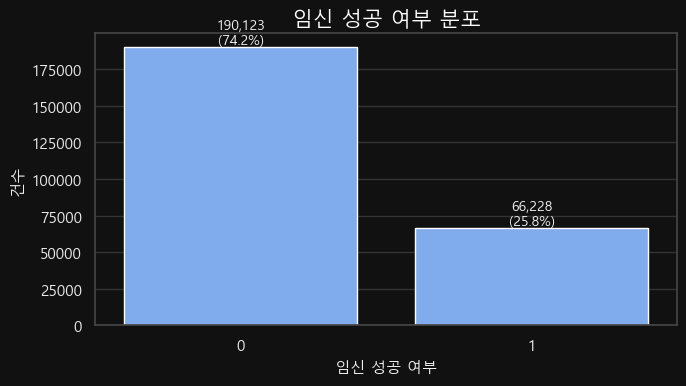

In [8]:
# 타깃 분포 확인

target_count = train[TARGET].value_counts().sort_index()
target_ratio = train[TARGET].value_counts(normalize=True).sort_index()

target_summary = pd.DataFrame({
    "count": target_count,
    "ratio": target_ratio,
    "ratio_percent": target_ratio * 100,
})

display(target_summary)

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=target_count.index.astype(str), y=target_count.values, color=main_color)
ax.set_title("임신 성공 여부 분포")
ax.set_xlabel("임신 성공 여부")
ax.set_ylabel("건수")

for i, value in enumerate(target_count.values):
    pct = target_ratio.iloc[i] * 100
    ax.text(i, value, f"{value:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


#### 01-2. 결과 해석

- target 분포를 확인한 결과, 임신 실패(0)와 임신 성공(1)의 비율은 약 74:26으로 나타났다.
- 성공 클래스가 상대적으로 적은 불균형 이진 분류 문제이므로, Accuracy만으로 모델 성능을 판단하기 어렵다.
- 본 프로젝트의 핵심 평가지표는 성공/실패 사례의 순위 구분 능력을 평가하는 ROC-AUC로 설정한다.
- LogLoss, Recall, F1-score는 예측 확률의 안정성 및 성공 클래스 포착 능력을 확인하기 위한 보조 지표로 함께 활용한다.
- IVF/보조생식 결과 예측 연구에서도 ROC-AUC는 머신러닝 모델의 구분 성능을 비교하는 주요 지표로 활용된다(Qiu et al., 2019; Amini et al., 2024; Fu et al., 2025).


### 01-3. 결측치 현황 확인

전체 변수의 결측치를 확인한다. 결측률이 높은 변수를 무조건 제거하기보다, 결측이 발생한 이유가 시술 프로세스와 관련되어 있는지 확인한다.

,missing_count,missing_rate,missing_rate_percent
난자 해동 경과일,254915,0.994398,99.439831
PGS 시술 여부,254422,0.992475,99.247516
PGD 시술 여부,254172,0.991500,99.149994
착상 전 유전 검사 사용 여부,253633,0.989397,98.939735
임신 시도 또는 마지막 임신 경과 연수,246981,0.963449,96.344855
배아 해동 경과일,215982,0.842525,84.252451
난자 채취 경과일,57488,0.224255,22.425503
난자 혼합 경과일,53735,0.209615,20.961494
배아 이식 경과일,43566,0.169947,16.994667
미세주입 후 저장된 배아 수,6291,0.024541,2.454057


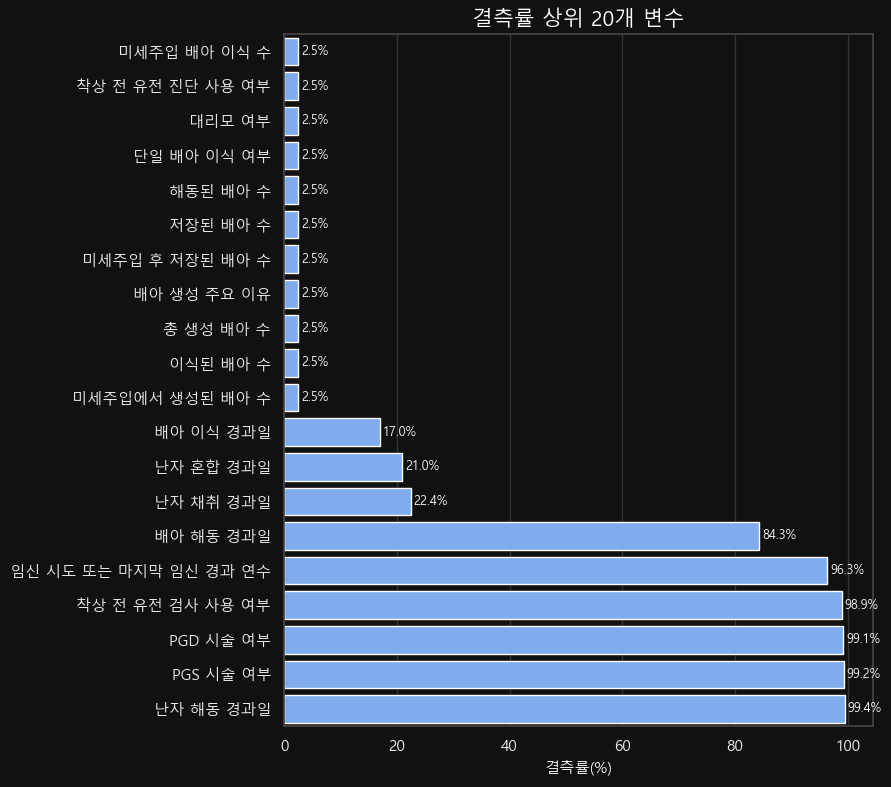

In [9]:
# 결측치 현황 확인

missing = (
    train.isna().sum()
    .to_frame("missing_count")
    .assign(
        missing_rate=lambda x: x["missing_count"] / len(train),
        missing_rate_percent=lambda x: x["missing_rate"] * 100,
    )
    .sort_values("missing_count", ascending=False)
)

display(missing.head(30))

plt.figure(figsize=(9, 8))
plot_df = missing.head(20).sort_values("missing_rate_percent")
ax = sns.barplot(data=plot_df, x="missing_rate_percent", y=plot_df.index, color=main_color)
ax.set_title("결측률 상위 20개 변수") # 전체를 보여주면 너무 많아서 상위 20개만 시각화(EDA)
ax.set_xlabel("결측률(%)")
ax.set_ylabel("")

for i, value in enumerate(plot_df["missing_rate_percent"]):
    ax.text(value + 0.5, i, f"{value:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()


#### 01-3. 결과 해석

- 전체 결측치 현황을 확인한 결과, 일부 변수에서 90% 이상의 높은 결측률이 나타났다.
- `난자 해동 경과일`, `PGS 시술 여부`, `PGD 시술 여부`, `착상 전 유전 검사 사용 여부`, `임신 시도 또는 마지막 임신 경과 연수`는 결측률이 약 96~99% 이상이었다.
- `배아 해동 경과일`도 결측률이 약 84.3%로 높아, 모든 환자에게 동결 배아 해동 과정이 존재하지는 않음을 시사한다.
- 배아·난자 관련 여러 변수에서 동일하게 6,291건의 결측이 반복되어, 특정 시술군에서 해당 과정 자체가 수행되지 않았을 가능성이 확인된다.
- 결측률이 높다는 이유만으로 변수를 삭제하면 시술 과정의 차이를 반영하는 정보를 잃을 수 있다.
- 따라서 이후 전처리에서는 결측 여부를 별도 missing flag로 생성하고, 트리 기반 모델에서는 원본 NaN과 결측 flag를 함께 활용한다.
- FET/IVF 예측 연구에서도 배아 품질, 이식 방식, 내막 두께, 나이 등 시술 과정 변수의 중요성이 반복적으로 보고되어 결측 패턴의 임상적 해석이 필요하다(Liu et al., 2021; Fu et al., 2025; Zhao et al., 2022).


### 01-4. 시술 유형별 구조적 결측 확인

DI와 IVF는 시술 프로세스가 다르기 때문에 결측 패턴도 다를 수 있다. 특히 배아 관련 변수의 결측은 단순 누락이 아니라 해당 시술에서 해당 과정이 존재하지 않는다는 의미일 수 있다.


In [10]:
# 시술 유형별 결측 패턴 확인

treatment_col = "시술 유형"

if treatment_col in train.columns:
    treatment_counts = train[treatment_col].value_counts(dropna=False)
    display(treatment_counts.to_frame("count"))

    missing_by_treatment = (
        train.groupby(treatment_col, dropna=False)
        .apply(lambda x: x.isna().mean())
        .T
    )

    missing_by_treatment["max_missing_rate"] = missing_by_treatment.max(axis=1)
    missing_by_treatment = missing_by_treatment.sort_values("max_missing_rate", ascending=False)

    display(missing_by_treatment.head(30))
else:
    print(f"{treatment_col} 컬럼이 없습니다.")


,count
시술 유형,
IVF,250060
DI,6291


시술 유형,DI,IVF,max_missing_rate
배아 생성 주요 이유,1.000000,0.000000,1.000000
착상 전 유전 진단 사용 여부,1.000000,0.000000,1.000000
착상 전 유전 검사 사용 여부,1.000000,0.989131,1.000000
단일 배아 이식 여부,1.000000,0.000000,1.000000
대리모 여부,1.000000,0.000000,1.000000
기증 배아 사용 여부,1.000000,0.000000,1.000000
기증자 정자와 혼합된 난자 수,1.000000,0.000000,1.000000
파트너 정자와 혼합된 난자 수,1.000000,0.000000,1.000000
수집된 신선 난자 수,1.000000,0.000000,1.000000
해동 난자 수,1.000000,0.000000,1.000000


#### 01-4. 결과 해석

- 시술 유형별 결측 패턴을 비교한 결과, DI와 IVF 사이에 뚜렷한 구조적 차이가 확인되었다.
- DI 시술에서는 `배아 생성 주요 이유`, `단일 배아 이식 여부`, `총 생성 배아 수`, `이식된 배아 수`, `미세주입된 난자 수`, `해동된 배아 수`, `신선/동결 배아 사용 여부` 등이 100% 결측이었다.
- 반면 IVF 시술에서는 동일 변수들의 결측률이 대부분 0%에 가까웠다.
- 이는 DI에서 해당 값이 우연히 누락된 것이 아니라, 시술 프로세스상 배아 생성·이식·난자 채취 과정이 존재하지 않아 발생한 구조적 결측으로 해석된다.
- 따라서 DI 관련 결측값은 0이나 평균으로 일괄 대체하기보다, 원본 NaN을 유지하고 결측 여부를 feature로 추가하는 방식이 적절하다.
- 이후 모델링에서는 `시술 유형`, DI 구조적 결측 flag, 배아·난자 관련 원본 변수의 조합을 함께 사용한다.


### 01-5. 주요 변수별 임신 성공률 확인

앞서 확인한 결측 패턴을 바탕으로, 주요 범주형 변수별 임신 성공률을 확인한다.

이 단계에서는 단순히 성공률이 높은 변수를 찾는 것이 아니라, 이후 파생변수 생성과 모델링에 활용할 수 있는 후보 변수를 선별하는 것을 목표로 한다.

In [11]:
# 주요 범주형 변수별 성공률 확인 함수
def success_rate_by_col(df, col, min_count=0):
    result = (
        df.groupby(col, dropna=False)[TARGET]
        .agg(["count", "mean"])
        .rename(columns={"mean": "success_rate"})
        .assign(success_rate_percent=lambda x: x["success_rate"] * 100)
        .sort_values("success_rate_percent", ascending=False)
    )

    if min_count > 0:
        result = result[result["count"] >= min_count]

    return result


key_cat_cols = [
    "시술 유형",
    "시술 당시 나이",
    "특정 시술 유형",
    "배란 자극 여부",
    "배란 유도 유형",
    "배아 생성 주요 이유",
    "난자 출처",
    "정자 출처",
    "동결 배아 사용 여부",
    "신선 배아 사용 여부",
]

for col in key_cat_cols:
    if col in train.columns:
        print("\n" + "=" * 80)
        print(col)
        display(success_rate_by_col(train, col).head(20))


시술 유형


,count,success_rate,success_rate_percent
시술 유형,,,
IVF,250060,0.261605,26.160521
DI,6291,0.128914,12.891432



시술 당시 나이


,count,success_rate,success_rate_percent
시술 당시 나이,,,
만18-34세,102476,0.322622,32.262188
만35-37세,57780,0.278401,27.840083
만38-39세,39247,0.217138,21.713762
만45-50세,6918,0.167679,16.767852
만40-42세,37348,0.159393,15.939274
만43-44세,12253,0.118012,11.801192
알 수 없음,329,0.000000,0.000000



특정 시술 유형


...

,count,success_rate,success_rate_percent
정자 출처,,,
배우자 제공,229199,0.260167,26.016693
기증 제공,27016,0.243744,24.374445
미할당,122,0.106557,10.655738
배우자 및 기증 제공,14,0.000000,0.000000



동결 배아 사용 여부


,count,success_rate,success_rate_percent
동결 배아 사용 여부,,,
0.0,209934,0.267760,26.776034
1.0,40126,0.229402,22.940238
NaN,6291,0.128914,12.891432



신선 배아 사용 여부


,count,success_rate,success_rate_percent
신선 배아 사용 여부,,,
1.0,210136,0.267689,26.768854
0.0,39924,0.229586,22.958621
NaN,6291,0.128914,12.891432


#### 01-5. 결과 해석

- 주요 범주형 변수별 임신 성공률을 확인한 결과, 시술 유형·나이·특정 시술 유형·난자 출처·배아 사용 여부에서 target과 관련된 차이가 관찰되었다.
- `시술 유형`에서는 IVF의 성공률이 약 26.2%, DI의 성공률이 약 12.9%로 나타나 두 시술군의 프로세스 및 결과 차이가 분명했다.
- `시술 당시 나이`는 나이가 증가할수록 성공률이 낮아지는 경향을 보였다. 특히 만18-34세 약 32.3%, 만38-39세 약 21.7%, 만40-42세 약 15.9%, 만43-44세 약 11.8%로 감소하였다. 이는 나이가 IVF/ART 결과에 독립적인 영향을 미친다는 선행연구와 일치한다(Malizia et al., 2009; Sacchi et al., 2023; Reig et al., 2025).
- `특정 시술 유형`에서는 BLASTOCYST가 포함된 유형의 성공률이 상대적으로 높았다. 포배기 이식의 임상적 이점은 무작위 연구를 포함한 체계적 문헌고찰에서도 보고되었다(Glujovsky et al., 2022; Hamzaoğlu et al., 2025).
- `난자 출처`에서는 기증 난자 사용군의 성공률이 본인 난자 사용군보다 높게 나타났으며, 이는 공여 난자 사용 시 수령자 나이보다 난자 조건의 영향이 커질 수 있다는 레지스트리 연구와 연결된다(HFEA, 2022; Cardozo et al., 2022).
- `신선/동결 배아 사용 여부`는 단독 해석보다 시술 과정, 배아 이식 여부, 배아 생성 목적과 함께 해석하는 것이 적절하다(Roque et al., 2019; Zaat et al., 2022).
- 이후 Feature Engineering에서는 `시술 유형`, `나이`, `BLASTOCYST 포함 여부`, `ICSI 포함 여부`, `난자 출처`, `나이 × 난자 출처`, `시술 유형 × 특정 시술 유형`을 우선 후보로 반영한다.


### 01-6. 나이·난자·배아 관련 구간화 기준 탐색

나이, 난자 수, 배아 수는 임신 성공 여부와 직접적인 관련이 있을 가능성이 높은 변수이다.

이 단계에서는 값이 증가할수록 성공률이 단순히 선형적으로 변하는지, 또는 특정 구간에서 급격한 변화나 정체 구간이 나타나는지 확인한다.

이를 바탕으로 이후 전처리 단계에서 임상적 의미를 반영한 구간화 변수를 생성한다.

,시술 당시 나이,count,success_rate,success_rate_percent
0,만18-34세,102476,0.322622,32.262188
1,만35-37세,57780,0.278401,27.840083
2,만38-39세,39247,0.217138,21.713762
4,만40-42세,37348,0.159393,15.939274
5,만43-44세,12253,0.118012,11.801192
3,만45-50세,6918,0.167679,16.767852
6,알 수 없음,329,0.000000,0.000000


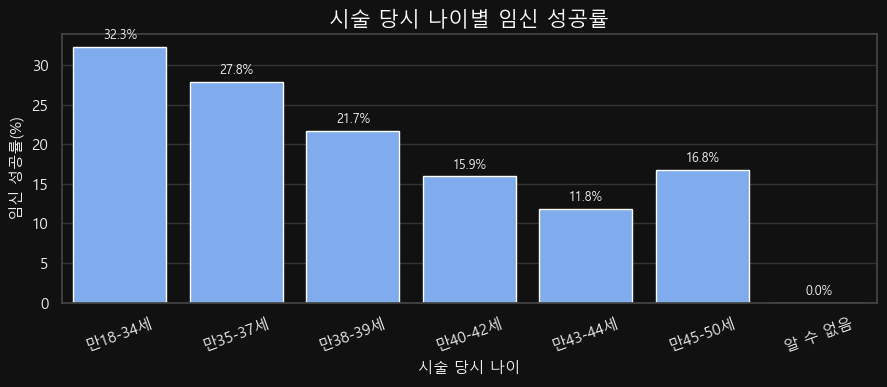

In [12]:
# 나이 구간별 성공률 확인: 이거 범주형인데 정렬해서 보면 다를듯
age_order = [
    "만18-34세",
    "만35-37세",
    "만38-39세",
    "만40-42세",
    "만43-44세",
    "만45-50세",
    "알 수 없음"
]

age_success = success_rate_by_col(train, "시술 당시 나이").reset_index()
age_success["시술 당시 나이"] = pd.Categorical(
    age_success["시술 당시 나이"],
    categories=age_order,
    ordered=True
)
age_success = age_success.sort_values("시술 당시 나이")

display(age_success)

plt.figure(figsize=(9, 4))
ax = sns.barplot(
    data=age_success,
    x="시술 당시 나이",
    y="success_rate_percent",
    color=main_color
)

ax.set_title("시술 당시 나이별 임신 성공률")
ax.set_xlabel("시술 당시 나이")
ax.set_ylabel("임신 성공률(%)")
plt.xticks(rotation=20)

for i, row in age_success.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["success_rate_percent"] + 0.6,
        f'{row["success_rate_percent"]:.1f}%',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


수집된 신선 난자 수


,수집된 신선 난자 수_구간,count,success_rate,success_rate_percent
0,0개,53845,0.240487,24.048658
1,1-5개,40960,0.148730,14.873047
2,6-10개,64733,0.267777,26.777687
3,11개 이상,90522,0.320828,32.082809
4,NaN,6291,0.128914,12.891432


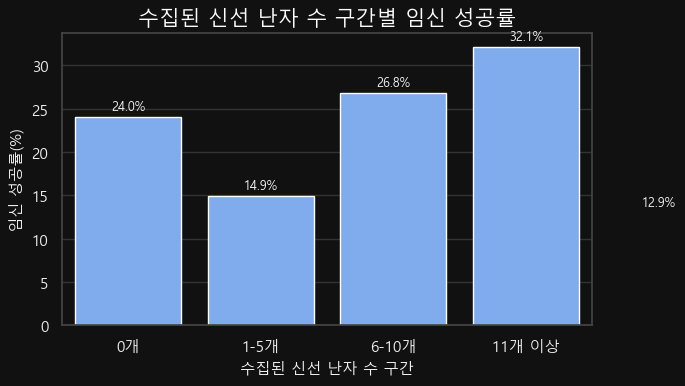


혼합된 난자 수


,혼합된 난자 수_구간,count,success_rate,success_rate_percent
0,0개,46650,0.196227,19.622722
1,1-5개,55563,0.176682,17.668232
2,6-10개,74683,0.296118,29.611826
3,11개 이상,73164,0.332554,33.255426
4,NaN,6291,0.128914,12.891432


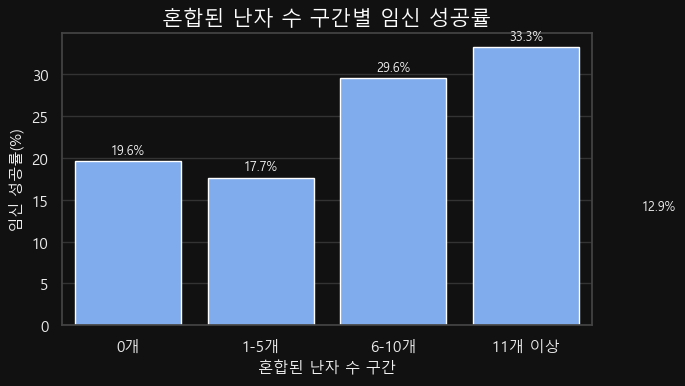


해동 난자 수


,해동 난자 수_구간,count,success_rate,success_rate_percent
0,0개,248615,0.261835,26.183456
1,1-5개,393,0.109415,10.941476
2,6-10개,729,0.252401,25.240055
3,11개 이상,323,0.291022,29.102167
4,NaN,6291,0.128914,12.891432


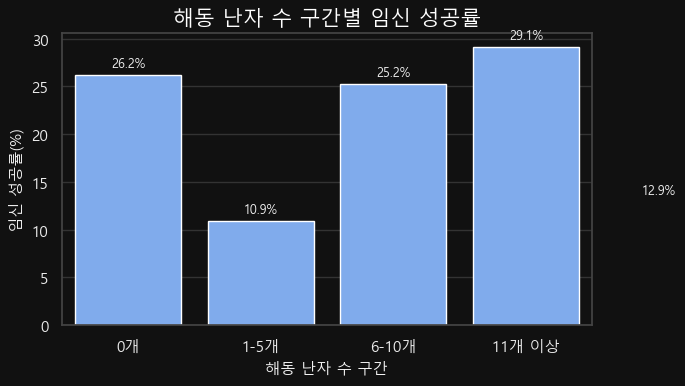

In [13]:
# 난자 수 구간별 성공률 확인
def make_count_bin(s):
    return pd.cut(
        s,
        bins=[-1, 0, 5, 10, np.inf],
        labels=["0개", "1-5개", "6-10개", "11개 이상"]
    )

oocyte_cols = [
    "수집된 신선 난자 수",
    "혼합된 난자 수",
    "해동 난자 수"
]

for col in oocyte_cols:
    if col in train.columns:
        temp = train[[col, TARGET]].copy()
        temp[f"{col}_구간"] = make_count_bin(temp[col])

        result = (
            temp.groupby(f"{col}_구간", dropna=False)[TARGET]
            .agg(["count", "mean"])
            .rename(columns={"mean": "success_rate"})
            .assign(success_rate_percent=lambda x: x["success_rate"] * 100)
            .reset_index()
        )

        print("\n" + "=" * 80)
        print(col)
        display(result)

        plt.figure(figsize=(7, 4))
        ax = sns.barplot(
            data=result,
            x=f"{col}_구간",
            y="success_rate_percent",
            color=main_color
        )

        ax.set_title(f"{col} 구간별 임신 성공률")
        ax.set_xlabel(f"{col} 구간")
        ax.set_ylabel("임신 성공률(%)")

        for i, row in result.iterrows():
            ax.text(
                i,
                row["success_rate_percent"] + 0.5,
                f'{row["success_rate_percent"]:.1f}%',
                ha="center",
                va="bottom",
                fontsize=9
            )

        plt.tight_layout()
        plt.show()


총 생성 배아 수


,총 생성 배아 수_구간,count,success_rate,success_rate_percent
0,0개,53349,0.171868,17.186826
1,1-2개,34413,0.142388,14.238805
2,3-5개,62974,0.274637,27.463715
3,6개 이상,99324,0.342848,34.284765
4,NaN,6291,0.128914,12.891432


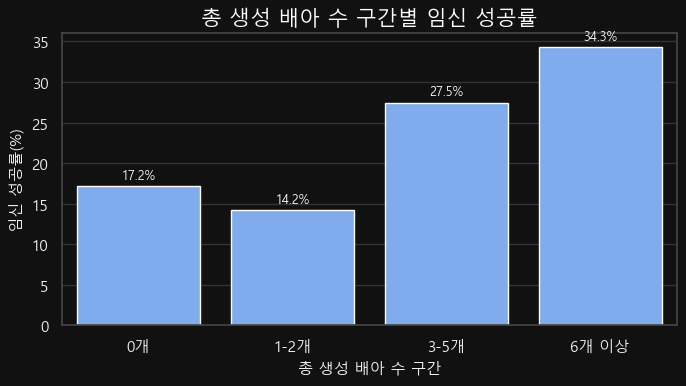


이식된 배아 수


,이식된 배아 수_구간,count,success_rate,success_rate_percent
0,0개,36544,0.000821,0.082093
1,1-2개,204636,0.312218,31.221779
2,3-5개,8880,0.168468,16.846847
3,6개 이상,0,NaN,NaN
4,NaN,6291,0.128914,12.891432


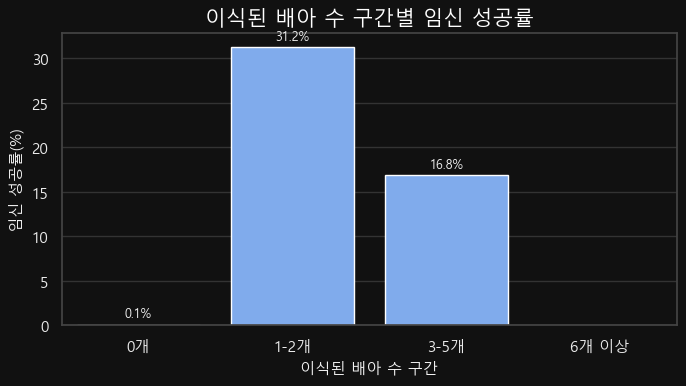


저장된 배아 수


,저장된 배아 수_구간,count,success_rate,success_rate_percent
0,0개,166866,0.222130,22.213033
1,1-2개,40245,0.357759,35.775873
2,3-5개,28731,0.362431,36.243082
3,6개 이상,14218,0.248980,24.898017
4,NaN,6291,0.128914,12.891432


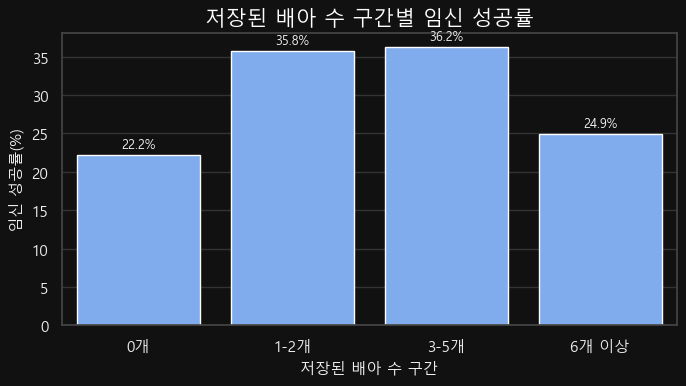

In [14]:
# 배아 수 구간별 성공률 확인
def make_embryo_bin(s):
    return pd.cut(
        s,
        bins=[-0.1, 0, 2, 5, np.inf],
        labels=["0개", "1-2개", "3-5개", "6개 이상"],
        include_lowest=True
    )

embryo_cols = [
    "총 생성 배아 수",
    "이식된 배아 수",
    "저장된 배아 수"
]

for col in embryo_cols:
    if col in train.columns:
        temp = train[[col, TARGET]].copy()

        temp[f"{col}_구간"] = make_embryo_bin(temp[col])

        result = (
            temp.groupby(f"{col}_구간", dropna=False, observed=False)[TARGET]
            .agg(["count", "mean"])
            .rename(columns={"mean": "success_rate"})
            .assign(success_rate_percent=lambda x: x["success_rate"] * 100)
            .reset_index()
        )

        # 표에는 결측 그룹도 확인
        display_result = result.copy()

        # 그래프에는 원값이 결측이 아닌 행만 사용
        plot_temp = temp[temp[col].notna()].copy()

        plot_result = (
            plot_temp.groupby(f"{col}_구간", observed=False)[TARGET]
            .agg(["count", "mean"])
            .rename(columns={"mean": "success_rate"})
            .assign(success_rate_percent=lambda x: x["success_rate"] * 100)
            .reset_index()
        )

        print("\n" + "=" * 80)
        print(col)
        display(display_result)

        plt.figure(figsize=(7, 4))
        ax = sns.barplot(
            data=plot_result,
            x=f"{col}_구간",
            y="success_rate_percent",
            color=main_color
        )

        ax.set_title(f"{col} 구간별 임신 성공률")
        ax.set_xlabel(f"{col} 구간")
        ax.set_ylabel("임신 성공률(%)")

        for i, row in plot_result.reset_index(drop=True).iterrows():
            ax.text(
                i,
                row["success_rate_percent"] + 0.5,
                f'{row["success_rate_percent"]:.1f}%',
                ha="center",
                va="bottom",
                fontsize=9
            )

        plt.tight_layout()
        plt.show() # NaN 값이 자꾸 6이상에 달라붙는데 해결 필요

### 01-6. 결과 해석

- 나이, 난자 수, 배아 수 관련 변수의 구간별 성공률을 확인한 결과, 단순 선형 관계가 아니라 특정 구간에서 성공률이 달라지는 패턴이 확인되었다.
- `시술 당시 나이`는 나이가 증가할수록 성공률이 전반적으로 감소하였다. 만18-34세 약 32.3%, 만35-37세 약 27.8%, 만38-39세 약 21.7%로 낮아졌으며, 38세 전후를 주요 기준점으로 볼 수 있다.
- 40세 이상 및 43세 이상 구간에서도 추가적인 성공률 하락이 관찰되어, 나이 구간 flag를 별도로 생성할 필요가 있다. 이는 고령 모체 나이와 ART 결과 저하를 보고한 연구들과 방향이 일치한다(Malizia et al., 2009; Sacchi et al., 2023; Reig et al., 2025).
- 난자 수 관련 변수는 6-10개 구간부터 성공률이 상승하고, 11개 이상 구간에서 더 높은 성공률을 보였다. 난소 예비력 및 난모세포 수율이 IVF/ICSI 결과와 관련된다는 문헌과 부합한다(Murugappan et al., 2023; Mohamed Salih et al., 2026).
- `총 생성 배아 수`는 3-5개 이상부터 성공률이 상승했고, 6개 이상 구간에서 가장 높은 수준을 보였다.
- `이식된 배아 수`는 0개 구간의 성공률이 거의 0%에 가까웠으며, 1-2개 이식 구간에서 상대적으로 높은 성공률을 보였다. 배아 발달 단계와 이식 전략의 중요성은 포배 이식 관련 문헌에서도 확인된다(Glujovsky et al., 2022; Hamzaoğlu et al., 2025).
- `저장된 배아 수`는 1-5개 구간에서 성공률이 높고, 6개 이상에서는 추가 상승이 제한되어 상단 평탄화 가능성이 있다.
- 이후 전처리에서는 다음 구간화 변수를 생성한다.
  - 나이: 38세 이상, 40세 이상, 43세 이상
  - 난자 수: 0개, 1-5개, 6-10개, 11개 이상
  - 총 생성 배아 수: 0개, 1-2개, 3-5개, 6개 이상
  - 이식된 배아 수: 0개, 1-2개, 3개 이상
  - 저장된 배아 수: 0개, 1-2개, 3-5개, 6개 이상
- NaN 그룹은 DI 시술과 연결된 구조적 결측일 가능성이 높으므로, 구간화와 별도로 missing flag로 보존한다.


#### 제언: 임상 기반 결측 유추 파생변수 검토

- 앞선 EDA에서 일부 결측값은 단순 누락이 아니라 시술 프로세스의 차이와 연결될 가능성이 확인되었다.
- `해동된 배아 수 >= 1`인 경우, 동결·해동 배아 이식(FET/FER) 과정이 있었을 가능성을 나타내는 간접 신호로 볼 수 있다(Fu et al., 2025; Zhao et al., 2022).
- `미세주입된 난자 수 >= 1`인 경우, ICSI 관련 과정이 수행되었을 가능성을 나타내는 간접 신호로 해석할 수 있다(Chen et al., 2022; Mohamed Salih et al., 2026).
- `배란 자극 여부 == 0` 및 `배란 유도 유형 Unknown` 조합은 자연주기 또는 비자극 방식 가능성을 검토할 수 있는 후보 조건이다(Maman et al., 2024; Sapir et al., 2026).
- 해당 규칙은 원본 값을 확정적으로 대체하기보다, 별도 flag로 생성한 뒤 validation 또는 OOF ROC-AUC 개선 여부를 기준으로 채택한다.


In [15]:
# 결측치 유추 파생변수 확인
def rule_summary(df, mask, rule_name):
    subset = df.loc[mask]

    return {
        "rule": rule_name,
        "count": len(subset),
        "success_rate": subset[TARGET].mean(),
        "success_rate_percent": subset[TARGET].mean() * 100
    }


proc = train["특정 시술 유형"].astype("string")
ovulation_type = train["배란 유도 유형"].astype("string")

unknown_proc = proc.isna() | proc.isin(["Unknown", "알 수 없음"])
unknown_ovulation_type = ovulation_type.isna() | ovulation_type.isin(["Unknown", "알 수 없음"])

thawed_embryo_ge1 = pd.to_numeric(train["해동된 배아 수"], errors="coerce").fillna(0) >= 1
micro_oocyte_ge1 = pd.to_numeric(train["미세주입된 난자 수"], errors="coerce").fillna(0) >= 1
ovulation_stim_zero = pd.to_numeric(train["배란 자극 여부"], errors="coerce").fillna(-1) == 0

candidate_rules = [
    rule_summary(
        train,
        thawed_embryo_ge1,
        "해동된 배아 수 1개 이상: FER 가능성"
    ),
    rule_summary(
        train,
        thawed_embryo_ge1 & unknown_proc,
        "특정 시술 유형 Unknown + 해동된 배아 수 1개 이상: FER 유추 후보"
    ),
    rule_summary(
        train,
        micro_oocyte_ge1,
        "미세주입된 난자 수 1개 이상: ICSI 가능성"
    ),
    rule_summary(
        train,
        micro_oocyte_ge1 & unknown_proc,
        "특정 시술 유형 Unknown + 미세주입된 난자 수 1개 이상: ICSI 유추 후보"
    ),
    rule_summary(
        train,
        ovulation_stim_zero & unknown_ovulation_type,
        "배란 자극 여부 0 + 배란 유도 유형 Unknown: 자연주기 유추 후보"
    ),
]

candidate_rule_df = pd.DataFrame(candidate_rules)
display(candidate_rule_df)

,rule,count,success_rate,success_rate_percent
0,해동된 배아 수 1개 이상: FER 가능성,40385,0.228501,22.850068
1,특정 시술 유형 Unknown + 해동된 배아 수 1개 이상: FER 유추 후보,26924,0.237186,23.718615
2,미세주입된 난자 수 1개 이상: ICSI 가능성,122391,0.272937,27.293674
3,특정 시술 유형 Unknown + 미세주입된 난자 수 1개 이상: ICSI 유추 후보,74,0.175676,17.567568
4,배란 자극 여부 0 + 배란 유도 유형 Unknown: 자연주기 유추 후보,58631,0.231652,23.165220


In [16]:
# 유추 후보 조건별 기존 시술 유형 분포 확인
print("해동된 배아 수 1개 이상인 경우의 특정 시술 유형 분포")
display(
    train.loc[thawed_embryo_ge1, "특정 시술 유형"]
    .value_counts(dropna=False)
    .head(20)
    .to_frame("count")
)

print("미세주입된 난자 수 1개 이상인 경우의 특정 시술 유형 분포")
display(
    train.loc[micro_oocyte_ge1, "특정 시술 유형"]
    .value_counts(dropna=False)
    .head(20)
    .to_frame("count")
)

print("배란 자극 여부 0인 경우의 배란 유도 유형 분포")
display(
    train.loc[ovulation_stim_zero, "배란 유도 유형"]
    .value_counts(dropna=False)
    .head(20)
    .to_frame("count")
)

해동된 배아 수 1개 이상인 경우의 특정 시술 유형 분포


,count
특정 시술 유형,
Unknown,26924
ICSI,6572
IVF,5763
IVF / BLASTOCYST,334
ICSI / BLASTOCYST,306
ICSI:Unknown,202
IVF:Unknown,96
ICSI:ICSI,74
ICSI / AH,58


미세주입된 난자 수 1개 이상인 경우의 특정 시술 유형 분포


,count
특정 시술 유형,
ICSI,115585
ICSI:ICSI,2091
ICSI / BLASTOCYST,1304
IVF,1262
ICSI:IVF,822
ICSI / AH,712
IVF:ICSI,317
ICSI:Unknown,197
Unknown,74


배란 자극 여부 0인 경우의 배란 유도 유형 분포


,count
배란 유도 유형,
알 수 없음,58631


#### 제언에 대한 재탐색 결과

- 임상 지식 기반 결측 유추 후보를 재탐색한 결과, 일부 조건은 충분한 표본 수와 해석 가능성을 가진 것으로 확인되었다.
- `해동된 배아 수 >= 1` 조건은 40,385건에서 확인되었고, 해당 그룹의 성공률은 약 22.9%였다.
- `특정 시술 유형`이 Unknown이면서 `해동된 배아 수 >= 1`인 경우는 26,924건으로 비교적 많아, Unknown 시술 유형 중 FER/FET 관련 과정이 포함되었을 가능성을 시사한다(Fu et al., 2025; Zhao et al., 2022).
- `미세주입된 난자 수 >= 1` 조건은 122,391건에서 확인되었고, 성공률은 약 27.3%였다. 이는 ICSI 관련 시술 가능성을 나타내는 flag로 활용할 수 있다(Chen et al., 2022; Mohamed Salih et al., 2026).
- 다만 `특정 시술 유형`이 Unknown이면서 `미세주입된 난자 수 >= 1`인 경우는 74건으로 매우 적어, Unknown 값을 ICSI로 직접 대체하기에는 근거가 부족하다.
- `배란 자극 여부 == 0`이면서 `배란 유도 유형`이 Unknown인 경우는 58,631건으로 많고, 성공률은 약 23.2%였다. 이는 자연주기 또는 비자극 방식 가능성을 나타내는 보조 신호로 검토할 수 있다(Maman et al., 2024; Sapir et al., 2026).
- 최종적으로 다음 파생변수를 우선 검토한다.
  - `fer_inferred_flag`: `해동된 배아 수 >= 1`
  - `unknown_proc_with_fer_flag`: `특정 시술 유형 Unknown` + `해동된 배아 수 >= 1`
  - `icsi_inferred_flag`: `미세주입된 난자 수 >= 1`
  - `natural_cycle_inferred_flag`: `배란 자극 여부 == 0` + `배란 유도 유형 Unknown`
- 모든 규칙은 target 값을 사용하지 않고 각 행에 이미 기록된 시술 정보를 기준으로 적용하므로, leakage 위험을 낮춘 feature engineering 방식이다.


### 01-7. 이상치 후보 확인

수치형 변수에서 일반적인 범위를 벗어나는 값이 있는지 확인한다.

의료 및 시술 데이터에서는 극단값이 실제 기록일 수 있으므로, 이상치를 바로 제거하지 않고 먼저 분포와 발생 비율을 확인한다.  
이후 전처리 단계에서 clipping, 구간화, flag 생성 여부를 판단한다.

In [17]:
# 수치형 변수의 기초 통계 확인
numeric_cols_raw = train.select_dtypes(include=[np.number]).columns.drop(TARGET, errors="ignore")

num_summary = train[numeric_cols_raw].describe().T
num_summary["missing_count"] = train[numeric_cols_raw].isna().sum()
num_summary["missing_rate"] = train[numeric_cols_raw].isna().mean()

display(num_summary.sort_values("missing_rate", ascending=False).head(30))

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_rate
난자 해동 경과일,1436.0,0.001393,0.037307,0.0,0.0,0.0,0.0,1.0,254915,0.994398
PGS 시술 여부,1929.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0,254422,0.992475
PGD 시술 여부,2179.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0,254172,0.991500
착상 전 유전 검사 사용 여부,2718.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0,253633,0.989397
임신 시도 또는 마지막 임신 경과 연수,9370.0,9.270651,3.550313,0.0,7.0,9.0,11.0,20.0,246981,0.963449
배아 해동 경과일,40369.0,0.045629,0.418672,0.0,0.0,0.0,0.0,7.0,215982,0.842525
난자 채취 경과일,198863.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,57488,0.224255
난자 혼합 경과일,202616.0,0.005385,0.111504,0.0,0.0,0.0,0.0,7.0,53735,0.209615
배아 이식 경과일,212785.0,3.254741,1.715697,0.0,2.0,3.0,5.0,7.0,43566,0.169947
총 생성 배아 수,250060.0,5.061145,4.664337,0.0,1.0,4.0,8.0,51.0,6291,0.024541


,column,outlier_count,outlier_rate,outlier_rate_percent,lower_bound,upper_bound,min,max
8,저장된 배아 수,14218,0.055463,5.546302,-3.0,5.0,0.0,51.0
5,미세주입에서 생성된 배아 수,8524,0.033251,3.325128,-7.5,12.5,0.0,43.0
4,미세주입된 난자 수,7511,0.029300,2.929967,-10.5,17.5,0.0,51.0
10,혼합된 난자 수,5314,0.020729,2.072939,-9.0,23.0,0.0,51.0
3,총 생성 배아 수,3312,0.012920,1.291979,-9.5,18.5,0.0,51.0
9,수집된 신선 난자 수,2733,0.010661,1.066116,-14.5,29.5,0.0,51.0
11,파트너 정자와 혼합된 난자 수,2035,0.007938,0.793833,-16.5,27.5,0.0,51.0
0,임신 시도 또는 마지막 임신 경과 연수,287,0.001120,0.111956,1.0,17.0,0.0,20.0
2,불임 원인 - 남성 요인,0,0.000000,0.000000,-1.5,2.5,0.0,1.0
1,불명확 불임 원인,0,0.000000,0.000000,-1.5,2.5,0.0,1.0


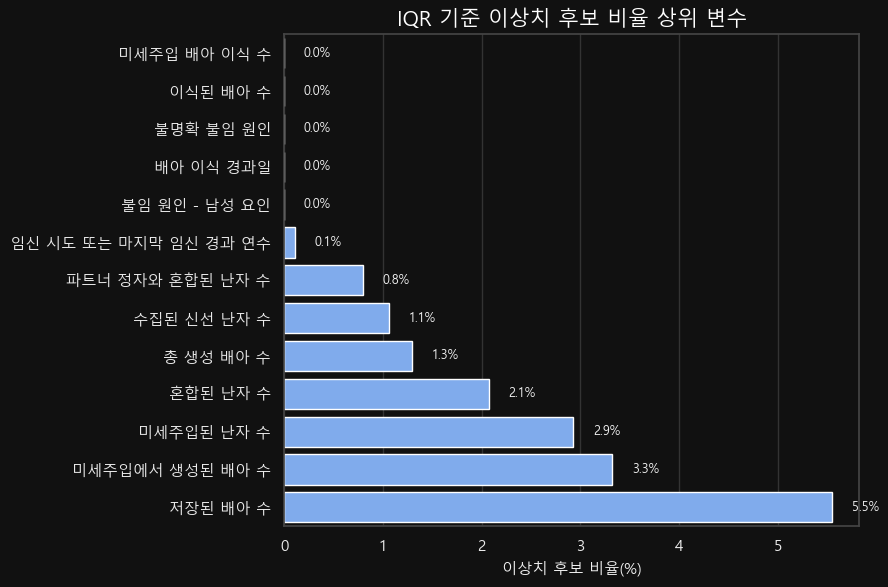

In [18]:
# IQR 기준 이상치 후보 계산 및 시각화
numeric_cols_raw = train.select_dtypes(include=[np.number]).columns.drop(TARGET, errors="ignore")

outlier_rows = []

for col in numeric_cols_raw:
    s = train[col].dropna()

    if len(s) == 0:
        continue

    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1

    if iqr == 0:
        continue

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_mask = (train[col] < lower) | (train[col] > upper)

    outlier_rows.append({
        "column": col,
        "outlier_count": int(outlier_mask.sum()),
        "outlier_rate": outlier_mask.mean(),
        "outlier_rate_percent": outlier_mask.mean() * 100,
        "lower_bound": lower,
        "upper_bound": upper,
        "min": s.min(),
        "max": s.max(),
    })

outlier_df = (
    pd.DataFrame(outlier_rows)
    .sort_values("outlier_rate_percent", ascending=False)
)

display(outlier_df.head(30))

plot_outlier = outlier_df.head(15).sort_values("outlier_rate_percent")

plt.figure(figsize=(9, 6))
ax = sns.barplot(
    data=plot_outlier,
    x="outlier_rate_percent",
    y="column",
    color=main_color
)

ax.set_title("IQR 기준 이상치 후보 비율 상위 변수")
ax.set_xlabel("이상치 후보 비율(%)")
ax.set_ylabel("")

for i, value in enumerate(plot_outlier["outlier_rate_percent"]):
    ax.text(value + 0.2, i, f"{value:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

#### 01-7. 결과 해석

- 수치형 변수의 IQR 기준 이상치 후보는 주로 난자·배아 수량 변수에서 확인되었다.
- `저장된 배아 수`는 약 5.5%의 행이 IQR 기준 상한값을 초과하여 가장 높은 이상치 후보 비율을 보였다.
- `미세주입에서 생성된 배아 수`, `미세주입된 난자 수`, `혼합된 난자 수`, `총 생성 배아 수`, `수집된 신선 난자 수`에서도 일부 극단값이 확인되었다.
- 이 변수들의 최댓값은 최대 51까지 나타났으나, 난임 시술 데이터에서는 많은 난자 또는 배아 수가 실제 임상 기록일 수 있으므로 단순 오류로 간주해 삭제하지 않는다.
- `이식된 배아 수`, `미세주입 배아 이식 수`, `배아 이식 경과일`은 이상치 후보가 거의 없어 비교적 제한된 범위에서 기록되었다.
- 본 프로젝트에서는 원본 수치를 보존하고, 필요 시 clipping 후보 변수와 구간화 변수를 추가하여 모델 성능 기준으로 선택한다.
- 난자 수율과 배아 수가 IVF/ICSI 결과와 관련된다는 선행연구를 고려할 때, 극단값은 제거보다 보존·검증 전략이 더 적절하다(Murugappan et al., 2023; Chen et al., 2022).


### 01-8. 수치형 변수 간 상관관계 확인

수치형 변수들이 `임신 성공 여부`와 어떤 방향의 관계를 가지는지 확인한다.  
또한 변수들끼리 상관관계가 지나치게 높은 경우, 이후 모델링 단계에서 중복 정보 또는 noise pruning 후보로 검토할 수 있다.

In [19]:
# 수치형 변수와 target 간 상관관계 확인
TARGET = "임신 성공 여부"

numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != TARGET]

corr_with_target = (
    train[numeric_cols + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .dropna()
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .reset_index()
)

corr_with_target.columns = ["feature", "corr_with_target"]
corr_with_target["abs_corr"] = corr_with_target["corr_with_target"].abs()

display(corr_with_target.head(30))

,feature,corr_with_target,abs_corr
0,이식된 배아 수,0.157487,0.157487
1,배아 이식 경과일,0.148590,0.148590
2,총 생성 배아 수,0.146116,0.146116
3,단일 배아 이식 여부,0.132635,0.132635
4,혼합된 난자 수,0.116136,0.116136
5,파트너 정자와 혼합된 난자 수,0.104902,0.104902
6,미세주입에서 생성된 배아 수,0.090275,0.090275
7,수집된 신선 난자 수,0.083023,0.083023
8,미세주입 배아 이식 수,0.074351,0.074351
9,미세주입된 난자 수,0.070117,0.070117


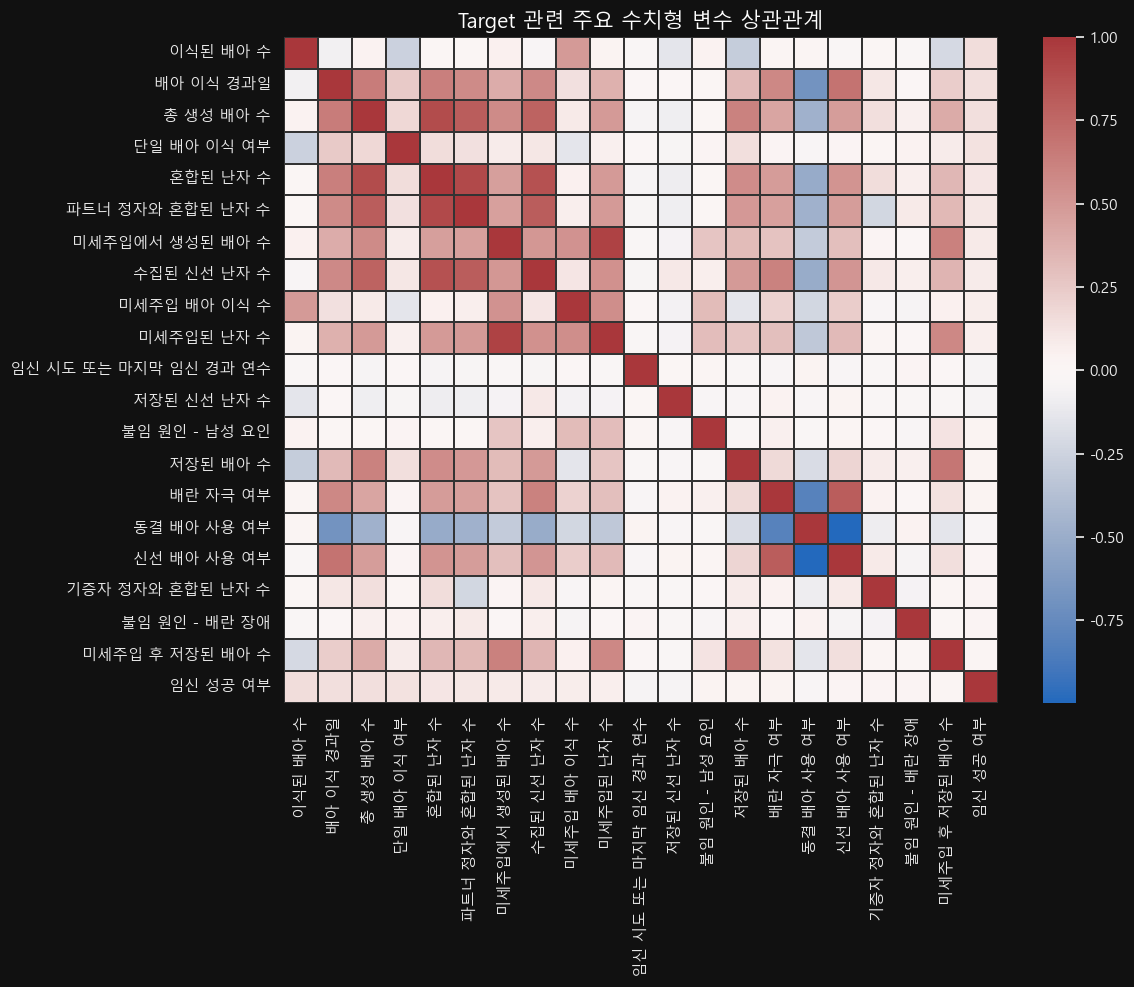

In [20]:
# target과 상관관계가 높은 변수 중심 heatmap
top_corr_features = corr_with_target.head(20)["feature"].tolist()
corr_matrix = train[top_corr_features + [TARGET]].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap="vlag",
    center=0,
    linewidths=0.3,
    linecolor="#333333"
)

plt.title("Target 관련 주요 수치형 변수 상관관계")
plt.tight_layout()
plt.show()

In [21]:
# 변수 간 상관관계가 높은 조합 확인
feature_corr = train[top_corr_features].corr(numeric_only=True).abs()

high_corr_pairs = []

for i, col1 in enumerate(feature_corr.columns):
    for col2 in feature_corr.columns[i + 1:]:
        corr_value = feature_corr.loc[col1, col2]
        if corr_value >= 0.8:
            high_corr_pairs.append({
                "feature_1": col1,
                "feature_2": col2,
                "abs_corr": corr_value
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

if len(high_corr_df) > 0:
    high_corr_df = high_corr_df.sort_values("abs_corr", ascending=False)

display(high_corr_df.head(30))

,feature_1,feature_2,abs_corr
8,동결 배아 사용 여부,신선 배아 사용 여부,0.996911
5,미세주입에서 생성된 배아 수,미세주입된 난자 수,0.939846
2,혼합된 난자 수,파트너 정자와 혼합된 난자 수,0.913231
0,총 생성 배아 수,혼합된 난자 수,0.891841
3,혼합된 난자 수,수집된 신선 난자 수,0.872449
7,배란 자극 여부,신선 배아 사용 여부,0.811952
6,배란 자극 여부,동결 배아 사용 여부,0.810742
1,총 생성 배아 수,파트너 정자와 혼합된 난자 수,0.810535
4,파트너 정자와 혼합된 난자 수,수집된 신선 난자 수,0.809544


#### 01-8. 결과 해석

- `임신 성공 여부`와 상대적으로 높은 상관관계를 보인 수치형 변수는 `이식된 배아 수`, `배아 이식 경과일`, `총 생성 배아 수`, `단일 배아 이식 여부`, `혼합된 난자 수`였다.
- 상위 변수 대부분이 난자·배아 생성 및 이식 과정과 관련되어 있어, 임신 성공 여부는 단순 인구통계 변수뿐 아니라 실제 시술 진행 결과와 밀접하게 연결되어 있음을 확인하였다.
- 가장 높은 상관계수도 약 0.16 수준이므로, 단일 변수만으로 target을 강하게 설명하기는 어렵다.
- 따라서 모델링 단계에서는 구간화, 비율 변수, 조합 변수, 결측 flag를 함께 사용하여 비선형·상호작용 신호를 보완한다.
- `동결 배아 사용 여부`와 `신선 배아 사용 여부`는 상관계수가 약 0.997로 매우 높아 중복 가능성이 크다.
- `미세주입된 난자 수`와 `미세주입에서 생성된 배아 수`, `혼합된 난자 수`와 `파트너 정자와 혼합된 난자 수`도 높은 상관관계를 보여 비율 변수 또는 pruning 후보로 검토한다.
- 초기 모델에서는 변수 제거를 서두르지 않고, Feature Importance 및 OOF 성능 변화를 기준으로 noise pruning 여부를 판단한다.


### 01-9. EDA 종합 정리 및 전처리 방향 제시

- **데이터 구조**
  - train 데이터에는 target인 `임신 성공 여부`가 포함되어 있고, test 데이터에는 target이 없다.
  - train과 test의 컬럼 차이는 target 컬럼 하나뿐이며, 제출 목표는 test 데이터의 임신 성공 확률 예측이다.

- **타깃 분포**
  - 임신 실패(0)는 약 74.2%, 임신 성공(1)은 약 25.8%로 확인되었다.
  - 성공 클래스가 적은 불균형 이진 분류 문제이므로, ROC-AUC를 핵심 평가지표로 사용하고 LogLoss, Recall, F1-score를 보조 지표로 확인한다.

- **결측 패턴**
  - 일부 변수는 결측률이 90% 이상으로 높고, DI 시술에서는 배아·난자·이식 관련 변수의 결측률이 100%에 가깝다.
  - 해당 결측은 단순 누락이 아니라 시술 프로세스 차이에 따른 구조적 결측으로 해석되므로, 결측 여부 자체를 feature로 활용한다.

- **임상적으로 중요한 변수군**
  - 나이는 성공률과 뚜렷한 관련을 보이며, 특히 38세·40세·43세 전후 기준이 의미 있는 구간으로 확인된다(Malizia et al., 2009; Sacchi et al., 2023; Reig et al., 2025).
  - BLASTOCYST 포함 시술의 성공률이 높게 나타났으며, 포배기 이식의 임상적 유효성은 선행 문헌에서도 보고되었다(Glujovsky et al., 2022; Hamzaoğlu et al., 2025).
  - 난자 출처는 성공률 차이를 보였고, 공여 난자 관련 대규모 레지스트리 연구도 난자 출처의 중요성을 뒷받침한다(HFEA, 2022; Cardozo et al., 2022).
  - 신선/동결 배아 사용 여부는 단독 변수보다 시술 조건과 함께 해석해야 한다(Roque et al., 2019; Zaat et al., 2022).

- **Feature Engineering 방향**
  - 나이는 순서형 변수와 38세 이상·40세 이상·43세 이상 flag로 변환한다.
  - 난자 수, 총 생성 배아 수, 이식 배아 수, 저장 배아 수는 구간화 변수를 추가한다.
  - `fer_inferred_flag`, `icsi_inferred_flag`, `natural_cycle_inferred_flag`를 생성하여 시술 과정의 간접 신호를 반영한다(Fu et al., 2025; Mohamed Salih et al., 2026; Maman et al., 2024).
  - `나이 × 난자 출처`, `시술 유형 × 특정 시술 유형`, `배아 생성 주요 이유 × 특정 시술 유형` 등 조합 변수를 생성한다.
  - 극단값은 일괄 삭제하지 않고 원본값, clipping 후보, 구간화 변수를 함께 두어 모델 성능 기준으로 판단한다.

- **모델링 방향**
  - 범주형 변수가 많고 결측 자체가 의미를 가질 수 있으므로 CatBoost를 주요 후보 모델로 사용한다.
  - LightGBM, XGBoost도 비교하여 tabular 데이터 기반 boosting 모델의 성능 차이를 확인한다.
  - K-Fold OOF 검증을 통해 단일 split의 우연성을 줄이고, 최종 단계에서는 단일 모델과 ensemble 후보를 함께 비교한다(Qiu et al., 2019; Amini et al., 2024; Karayiannis et al., 2025).


## 02. 데이터 전처리 및 Feature Engineering

EDA 결과를 바탕으로 모델 학습에 사용할 feature를 구성한다.  
결측치와 이상치는 단순 삭제하지 않고, 시술 과정의 차이와 변수별 의미를 고려하여 처리한다.

또한 나이, 난자 수, 배아 수처럼 성공률 차이가 뚜렷했던 변수는 구간화하고, 시술 과정과 관련된 조합 변수 및 비율 변수를 생성한다.

진행 순서는 다음과 같다.

1. 학습용 데이터 구성
2. 결측치 처리: 구조적 결측 및 일반 결측 flag 생성
3. 이상치 처리: clipping 후보 생성
4. 임상 지식 기반 파생변수 생성
5. 나이·난자·배아 구간화 변수 생성
6. 조합 변수 및 비율 변수 생성
7. 범주형/수치형 변수 구분
8. 인코딩 전략 정리
9. 스케일링 전략 정리
10. 학습/검증 데이터 분리

### 02-1. 학습용 데이터 구성

모델 학습에 사용할 feature와 target을 분리한다.  
target인 `임신 성공 여부`는 예측해야 할 값이므로 `y`로 따로 저장하고, 나머지 변수들을 학습용 feature로 사용한다.


In [22]:
# 학습용 feature와 target 분리
train_raw = train.copy()
test_raw = test.copy()

y = train_raw[TARGET].copy()

X = train_raw.drop(columns=[TARGET]).copy()
X_test = test_raw.copy()

train_id = X[ID_COL].copy()
test_id = X_test[ID_COL].copy()

print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)

assert TARGET not in X.columns
assert TARGET not in X_test.columns
assert list(X.columns) == list(X_test.columns)

X: (256351, 68)
y: (256351,)
X_test: (90067, 68)


#### 02-1. 처리 방식 설명

- train 데이터에서 target인 `임신 성공 여부`를 분리하여 `y`로 저장하였다.
- target을 제외한 변수들은 학습용 feature인 `X`로 저장하였다.
- ID는 모델 학습에는 사용하지 않고, 제출 파일 생성 시 활용하기 위해 별도로 보존하였다.
- 제출용 데이터는 이후 동일한 feature 생성 규칙을 적용하기 위해 `X_test`로 보존하였다.

### 02-2. 결측치 처리: 구조적 결측 및 일반 결측 flag 생성

EDA에서 DI 시술의 배아·난자·이식 관련 변수들이 구조적으로 결측되는 패턴을 확인하였다.  
또한 IVF에서도 유전검사, 경과일, 임신 경과 연수 등 일부 변수에 일반 결측이 존재한다.

따라서 결측값을 행 삭제 방식으로 처리하지 않고, 결측 여부를 나타내는 flag를 생성한다.

In [23]:
# 구조적 결측 가능성이 높은 배아·난자·이식 관련 변수
process_missing_cols = [
    "배아 생성 주요 이유",
    "단일 배아 이식 여부",
    "착상 전 유전 진단 사용 여부",
    "총 생성 배아 수",
    "미세주입된 난자 수",
    "미세주입에서 생성된 배아 수",
    "이식된 배아 수",
    "미세주입 배아 이식 수",
    "저장된 배아 수",
    "미세주입 후 저장된 배아 수",
    "해동된 배아 수",
    "해동 난자 수",
    "수집된 신선 난자 수",
    "저장된 신선 난자 수",
    "혼합된 난자 수",
    "파트너 정자와 혼합된 난자 수",
    "기증자 정자와 혼합된 난자 수",
    "동결 배아 사용 여부",
    "신선 배아 사용 여부",
]

process_missing_cols = [col for col in process_missing_cols if col in X.columns]

for df in [X, X_test]:
    for col in process_missing_cols:
        flag_col = col + "_missing_flag"
        df[flag_col] = df[col].isna().astype(int)

    process_flag_cols = [col + "_missing_flag" for col in process_missing_cols]
    df["process_missing_count"] = df[process_flag_cols].sum(axis=1)
    df["process_missing_rate"] = df["process_missing_count"] / len(process_flag_cols)

print("구조적 결측 대상 변수 수:", len(process_missing_cols))
print("생성된 구조적 missing flag 수:", len(process_missing_cols))

display(X[["process_missing_count", "process_missing_rate"]].describe())


구조적 결측 대상 변수 수: 19
생성된 구조적 missing flag 수: 19


,process_missing_count,process_missing_rate
count,256351.000000,256351.000000
mean,0.466271,0.024541
std,2.939689,0.154720
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,19.000000,1.000000


In [24]:
# train 기준 구조적 결측 패턴과 target 관계 확인
train_missing_check = X[["시술 유형", "process_missing_count"]].copy()
train_missing_check[TARGET] = y.values

process_missing_summary = (
    train_missing_check
    .groupby("process_missing_count")[TARGET]
    .agg(count="count", success_rate="mean")
    .reset_index()
)

process_missing_summary["success_rate_percent"] = process_missing_summary["success_rate"] * 100

display(process_missing_summary)

process_missing_by_treatment = (
    train_missing_check
    .groupby("시술 유형")["process_missing_count"]
    .agg(count="count", mean="mean", median="median", min="min", max="max")
)

display(process_missing_by_treatment)


,process_missing_count,count,success_rate,success_rate_percent
0,0,250060,0.261605,26.160521
1,19,6291,0.128914,12.891432


,count,mean,median,min,max
시술 유형,,,,,
DI,6291,19.0,19.0,19,19
IVF,250060,0.0,0.0,0,0


In [25]:
# 일반 결측 변수에 대한 missing flag 생성
missing_cols = [
    col for col in X.columns
    if col != ID_COL
    and col not in process_missing_cols
    and X[col].isna().sum() > 0
]

general_missing_flag_cols = []

for col in missing_cols:
    flag_col = col + "_is_missing"
    X[flag_col] = X[col].isna().astype(int)
    X_test[flag_col] = X_test[col].isna().astype(int)
    general_missing_flag_cols.append(flag_col)

missing_flag_summary = pd.DataFrame({
    "column": missing_cols,
    "train_missing_count": [X[col].isna().sum() for col in missing_cols],
    "train_missing_rate": [X[col].isna().mean() for col in missing_cols],
})

missing_flag_summary["train_missing_rate_percent"] = missing_flag_summary["train_missing_rate"] * 100
missing_flag_summary = missing_flag_summary.sort_values("train_missing_count", ascending=False)

print("일반 결측 변수 수:", len(missing_cols))
print("생성된 일반 missing flag 수:", len(general_missing_flag_cols))

display(missing_flag_summary.head(30))

일반 결측 변수 수: 12
생성된 일반 missing flag 수: 12


,column,train_missing_count,train_missing_rate,train_missing_rate_percent
8,난자 해동 경과일,254915,0.994398,99.439831
6,PGS 시술 여부,254422,0.992475,99.247516
5,PGD 시술 여부,254172,0.991500,99.149994
2,착상 전 유전 검사 사용 여부,253633,0.989397,98.939735
0,임신 시도 또는 마지막 임신 경과 연수,246981,0.963449,96.344855
11,배아 해동 경과일,215982,0.842525,84.252451
7,난자 채취 경과일,57488,0.224255,22.425503
9,난자 혼합 경과일,53735,0.209615,20.961494
10,배아 이식 경과일,43566,0.169947,16.994667
3,기증 배아 사용 여부,6291,0.024541,2.454057


#### 02-2. 결과 해석

- 배아·난자·이식 관련 19개 변수를 구조적 결측 후보로 지정하고, 각 변수의 결측 여부를 missing flag로 생성하였다.
- `process_missing_count`는 0 또는 19로만 나타났으며, 이는 결측 패턴이 임의적이지 않고 시술 유형과 강하게 연결되어 있음을 의미한다.
- `process_missing_count = 0`인 행은 250,060건이며 성공률은 약 26.16%였다.
- `process_missing_count = 19`인 행은 6,291건이며 성공률은 약 12.89%였다.
- 시술 유형별 확인 결과, IVF는 구조적 결측 개수가 모두 0개였고 DI는 모두 19개였다.
- 따라서 이 19개 변수의 동시 결측은 DI 시술에서 배아 생성·이식 과정이 존재하지 않아 발생한 구조적 결측으로 판단된다.
- DI 관련 결측값을 0이나 평균으로 대체하면 “해당 과정이 존재하지 않음”이라는 의미가 사라질 수 있으므로, 원본 NaN을 유지하고 missing flag를 함께 사용한다.
- 일반 결측 변수 12개도 행 삭제 대신 변수별 missing flag를 생성하여, 특정 조건에서만 기록되는 정보의 존재 여부를 모델이 학습할 수 있도록 한다.


### 02-3. 이상치 처리

EDA에서 난자 수, 배아 수, 혼합 난자 수 등 일부 수량형 변수에서 IQR 기준 이상치 후보가 확인되었다.  
그러나 의료 시술 데이터에서는 큰 값이 실제 기록일 수 있으므로, 이상치 후보를 일괄 삭제하지 않는다.

대신 원본 변수는 유지하고, train 데이터에서 계산한 IQR 기준으로 clipping 후보 변수를 별도로 생성한다.


In [26]:
# train 기준 IQR로 clipping 후보 변수 생성
outlier_candidate_cols = [
    "저장된 배아 수",
    "미세주입에서 생성된 배아 수",
    "미세주입된 난자 수",
    "혼합된 난자 수",
    "총 생성 배아 수",
    "수집된 신선 난자 수",
    "파트너 정자와 혼합된 난자 수",
    "임신 시도 또는 마지막 임신 경과 연수",
]

outlier_candidate_cols = [col for col in outlier_candidate_cols if col in X.columns]
clipping_summary = []
clip_bounds = {}

for col in outlier_candidate_cols:
    train_values = pd.to_numeric(X[col], errors="coerce")

    q1 = train_values.quantile(0.25)
    q3 = train_values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    clip_bounds[col] = (lower_bound, upper_bound)

    clipped_col = col + "_clipped"
    X[clipped_col] = pd.to_numeric(X[col], errors="coerce").clip(lower_bound, upper_bound)
    X_test[clipped_col] = pd.to_numeric(X_test[col], errors="coerce").clip(lower_bound, upper_bound)

    clipping_summary.append({
        "column": col,
        "clipped_column": clipped_col,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "train_original_min": train_values.min(),
        "train_original_max": train_values.max(),
        "train_clipped_min": X[clipped_col].min(),
        "train_clipped_max": X[clipped_col].max(),
    })

clipping_summary = pd.DataFrame(clipping_summary)
clipped_cols = [col + "_clipped" for col in outlier_candidate_cols]

display(clipping_summary)
print("생성된 clipping 후보 변수 수:", len(clipped_cols))

,column,clipped_column,lower_bound,upper_bound,train_original_min,train_original_max,train_clipped_min,train_clipped_max
0,저장된 배아 수,저장된 배아 수_clipped,-3.0,5.0,0.0,51.0,0.0,5.0
1,미세주입에서 생성된 배아 수,미세주입에서 생성된 배아 수_clipped,-7.5,12.5,0.0,43.0,0.0,12.5
2,미세주입된 난자 수,미세주입된 난자 수_clipped,-10.5,17.5,0.0,51.0,0.0,17.5
3,혼합된 난자 수,혼합된 난자 수_clipped,-9.0,23.0,0.0,51.0,0.0,23.0
4,총 생성 배아 수,총 생성 배아 수_clipped,-9.5,18.5,0.0,51.0,0.0,18.5
5,수집된 신선 난자 수,수집된 신선 난자 수_clipped,-14.5,29.5,0.0,51.0,0.0,29.5
6,파트너 정자와 혼합된 난자 수,파트너 정자와 혼합된 난자 수_clipped,-16.5,27.5,0.0,51.0,0.0,27.5
7,임신 시도 또는 마지막 임신 경과 연수,임신 시도 또는 마지막 임신 경과 연수_clipped,1.0,17.0,0.0,20.0,1.0,17.0


생성된 clipping 후보 변수 수: 8


#### 02-3. 결과 해석

- EDA에서 이상치 후보로 확인된 8개 수량형 변수에 대해 clipping 후보 변수를 생성하였다.
- `저장된 배아 수`, `미세주입된 난자 수`, `혼합된 난자 수`, `총 생성 배아 수`, `수집된 신선 난자 수` 등은 원본 최대값이 51까지 나타났다.
- IQR 기준을 적용하면 각 변수의 상한값은 `저장된 배아 수` 5.0, `미세주입에서 생성된 배아 수` 12.5, `미세주입된 난자 수` 17.5, `혼합된 난자 수` 23.0, `총 생성 배아 수` 18.5 등으로 조정된다.
- `임신 시도 또는 마지막 임신 경과 연수`는 원본 범위가 0~20년이며, clipping 후보 변수에서는 1~17년 범위로 조정되었다.
- 원본 변수는 삭제하지 않고 유지하였고, clipping 변수는 모델 성능 비교를 위한 후보 feature로 추가하였다.
- 난자·배아 수량은 IVF/ICSI 결과와 관련될 수 있으므로, 큰 값을 즉시 오류로 처리하지 않고 원본값·구간화·clipping 후보를 함께 검증한다(Murugappan et al., 2023; Chen et al., 2022).


### 02-4. 임상 지식 기반 파생변수 생성

EDA에서 확인한 시술 프로세스 단서를 바탕으로 FER, ICSI, 자연주기 가능성을 나타내는 flag를 생성한다.


In [27]:
# 임상 지식 기반 flag 생성 함수
def to_numeric_safe_series(df, col):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce")
    return pd.Series(np.nan, index=df.index)


def add_clinical_inference_flags(df):
    specific_proc = df["특정 시술 유형"].astype("string").fillna("Unknown")

    df["fer_inferred_flag"] = (
        to_numeric_safe_series(df, "해동된 배아 수").fillna(0) >= 1
    ).astype(int)

    df["icsi_inferred_flag"] = (
        to_numeric_safe_series(df, "미세주입된 난자 수").fillna(0) >= 1
    ).astype(int)

    df["natural_cycle_inferred_flag"] = (
        to_numeric_safe_series(df, "배란 자극 여부").fillna(-1) == 0
    ).astype(int)

    df["unknown_proc_with_thawed_embryo_flag"] = (
        specific_proc.isin(["Unknown", "알 수 없음"])
        & (to_numeric_safe_series(df, "해동된 배아 수").fillna(0) >= 1)
    ).astype(int)

    df["unknown_proc_with_icsi_oocyte_flag"] = (
        specific_proc.isin(["Unknown", "알 수 없음"])
        & (to_numeric_safe_series(df, "미세주입된 난자 수").fillna(0) >= 1)
    ).astype(int)

    return df


X = add_clinical_inference_flags(X)
X_test = add_clinical_inference_flags(X_test)

inferred_cols = [
    "fer_inferred_flag",
    "icsi_inferred_flag",
    "natural_cycle_inferred_flag",
    "unknown_proc_with_thawed_embryo_flag",
    "unknown_proc_with_icsi_oocyte_flag",
]

print("임상 지식 기반 flag 생성 완료")
display(X[inferred_cols].sum().to_frame("train_count"))


임상 지식 기반 flag 생성 완료


,train_count
fer_inferred_flag,40385
icsi_inferred_flag,122391
natural_cycle_inferred_flag,58631
unknown_proc_with_thawed_embryo_flag,26924
unknown_proc_with_icsi_oocyte_flag,74


In [28]:
# train-based success rate by clinical inference flag
flag_success_summary = []

for col in inferred_cols:
    temp = pd.DataFrame({
        "feature": col,
        "value": X[col],
        TARGET: y.values,
    })

    summary = (
        temp.groupby(["feature", "value"], dropna=False)[TARGET]
        .agg(count="count", success_rate="mean")
        .reset_index()
    )
    summary["success_rate_percent"] = summary["success_rate"] * 100
    flag_success_summary.append(summary)

flag_success_summary = pd.concat(flag_success_summary, ignore_index=True)
display(flag_success_summary)

,feature,value,count,success_rate,success_rate_percent
0,fer_inferred_flag,0,215966,0.263930,26.393043
1,fer_inferred_flag,1,40385,0.228501,22.850068
2,icsi_inferred_flag,0,133960,0.245021,24.502090
3,icsi_inferred_flag,1,122391,0.272937,27.293674
4,natural_cycle_inferred_flag,0,197720,0.266265,26.626543
5,natural_cycle_inferred_flag,1,58631,0.231652,23.165220
6,unknown_proc_with_thawed_embryo_flag,0,229427,0.260832,26.083242
7,unknown_proc_with_thawed_embryo_flag,1,26924,0.237186,23.718615
8,unknown_proc_with_icsi_oocyte_flag,0,256277,0.258373,25.837278
9,unknown_proc_with_icsi_oocyte_flag,1,74,0.175676,17.567568


#### 02-4. 결과 해석

- 임상 지식 기반으로 FER, ICSI, 자연주기 가능성을 나타내는 flag 변수를 생성하였다.
- `fer_inferred_flag`는 40,385건에서 1로 나타났고, 해당 그룹의 성공률은 약 22.85%였다. 해동 배아 수는 FET/FER 과정의 간접 신호로 해석할 수 있다(Fu et al., 2025; Zhao et al., 2022).
- `icsi_inferred_flag`는 122,391건에서 1로 나타났고, 해당 그룹의 성공률은 약 27.29%였다. 미세주입 난자 수는 ICSI 수행 가능성을 반영하는 직접적인 과정 변수이다(Chen et al., 2022; Mohamed Salih et al., 2026).
- `natural_cycle_inferred_flag`는 58,631건에서 1로 나타났고, 해당 그룹의 성공률은 약 23.17%였다. 자연주기 FET에서는 배란 예측 및 주기 정보가 임상 결과와 연결될 수 있다(Maman et al., 2024; Sapir et al., 2026).
- `특정 시술 유형`이 Unknown이면서 해동된 배아 수가 1개 이상인 경우는 26,924건으로, FER 관련 Unknown 보완 후보로 볼 수 있다.
- 반면 Unknown이면서 미세주입된 난자 수가 1개 이상인 경우는 74건으로 매우 적어, ICSI로 직접 대체하기보다는 보조 flag로만 활용한다.
- 이 파생변수들은 target 값을 사용하지 않고 각 행에 이미 기록된 시술 정보를 고정 규칙으로 변환한 것이므로, leakage가 아니라 임상 기반 feature engineering으로 판단한다.


### 02-5. 나이·난자·배아 구간화 변수 생성

EDA에서 나이, 난자 수, 배아 수는 단순 선형 관계보다 구간별 성공률 차이가 뚜렷하게 나타났다.  
따라서 원본값은 유지하면서 구간화 변수를 추가한다.


In [29]:
# 나이 및 수량형 변수 구간화 함수 정의
age_ord_map = {
    "만18-34세": 0,
    "만35-37세": 1,
    "만38-39세": 2,
    "만40-42세": 3,
    "만43-44세": 4,
    "만45-50세": 5,
}


def make_oocyte_bin(series):
    x = pd.to_numeric(series, errors="coerce")
    result = pd.Series("missing", index=series.index, dtype="object")
    result[x == 0] = "0개"
    result[(x >= 1) & (x <= 5)] = "1-5개"
    result[(x >= 6) & (x <= 10)] = "6-10개"
    result[x >= 11] = "11개 이상"
    return result


def make_embryo_bin(series):
    x = pd.to_numeric(series, errors="coerce")
    result = pd.Series("missing", index=series.index, dtype="object")
    result[x == 0] = "0개"
    result[(x >= 1) & (x <= 2)] = "1-2개"
    result[(x >= 3) & (x <= 5)] = "3-5개"
    result[x >= 6] = "6개 이상"
    return result


def make_transfer_embryo_bin(series):
    x = pd.to_numeric(series, errors="coerce")
    result = pd.Series("missing", index=series.index, dtype="object")
    result[x == 0] = "0개"
    result[(x >= 1) & (x <= 2)] = "1-2개"
    result[x >= 3] = "3개 이상"
    return result


def add_binning_features(df):
    df["age_ord"] = df["시술 당시 나이"].map(age_ord_map)
    df["age_38plus_flag"] = (df["age_ord"] >= 2).fillna(False).astype(int)
    df["age_40plus_flag"] = (df["age_ord"] >= 3).fillna(False).astype(int)
    df["age_43plus_flag"] = (df["age_ord"] >= 4).fillna(False).astype(int)
    df["age_unknown_flag"] = df["age_ord"].isna().astype(int)

    oocyte_cols = ["수집된 신선 난자 수", "혼합된 난자 수", "해동 난자 수"]
    for col in oocyte_cols:
        if col in df.columns:
            df[col + "_bin"] = make_oocyte_bin(df[col])

    embryo_cols = ["총 생성 배아 수", "저장된 배아 수"]
    for col in embryo_cols:
        if col in df.columns:
            df[col + "_bin"] = make_embryo_bin(df[col])

    if "이식된 배아 수" in df.columns:
        df["이식된 배아 수_bin"] = make_transfer_embryo_bin(df["이식된 배아 수"])

    return df


X = add_binning_features(X)
X_test = add_binning_features(X_test)

bin_feature_cols = [col for col in X.columns if col.endswith("_bin")]
age_feature_cols = ["age_ord", "age_38plus_flag", "age_40plus_flag", "age_43plus_flag", "age_unknown_flag"]

print("생성된 구간화 변수 수:", len(bin_feature_cols))
print("나이 파생 변수:", age_feature_cols)
print("구간화 변수:", bin_feature_cols)

display(X[age_feature_cols + bin_feature_cols].head())

생성된 구간화 변수 수: 6
나이 파생 변수: ['age_ord', 'age_38plus_flag', 'age_40plus_flag', 'age_43plus_flag', 'age_unknown_flag']
구간화 변수: ['수집된 신선 난자 수_bin', '혼합된 난자 수_bin', '해동 난자 수_bin', '총 생성 배아 수_bin', '저장된 배아 수_bin', '이식된 배아 수_bin']


,age_ord,age_38plus_flag,age_40plus_flag,age_43plus_flag,age_unknown_flag,수집된 신선 난자 수_bin,혼합된 난자 수_bin,해동 난자 수_bin,총 생성 배아 수_bin,저장된 배아 수_bin,이식된 배아 수_bin
0,0.0,0,0,0,0,6-10개,1-5개,0개,3-5개,1-2개,1-2개
1,5.0,1,1,1,0,1-5개,1-5개,0개,0개,0개,0개
2,0.0,0,0,0,0,6-10개,6-10개,0개,3-5개,0개,1-2개
3,1.0,0,0,0,0,1-5개,1-5개,0개,0개,0개,0개
4,0.0,0,0,0,0,6-10개,6-10개,0개,6개 이상,0개,1-2개


#### 02-5. 결과 해석

- `시술 당시 나이`를 순서형 변수인 `age_ord`로 변환하였다.
- 나이대가 높아질수록 큰 값을 갖도록 설정하여, 모델이 나이 증가에 따른 위험도 변화를 순서형 신호로 학습할 수 있게 하였다.
- EDA에서 성공률 하락이 뚜렷했던 기준을 반영하여 `age_38plus_flag`, `age_40plus_flag`, `age_43plus_flag`를 생성하였다. 해당 기준은 고령 모체 나이와 ART 결과 저하를 보고한 문헌과도 일관된다(Malizia et al., 2009; Sacchi et al., 2023; Reig et al., 2025).
- 나이 정보가 `알 수 없음`인 경우를 구분하기 위해 `age_unknown_flag`도 추가하였다.
- 난자 수 관련 변수는 `0개`, `1-5개`, `6-10개`, `11개 이상`으로 구간화하였다.
- 배아 수 관련 변수는 `0개`, `1-2개`, `3-5개`, `6개 이상`으로 구간화하였다.
- 이식된 배아 수는 `0개`, `1-2개`, `3개 이상`으로 구간화하였다.
- 원본 수치형 변수는 삭제하지 않고 유지하며, 구간화 변수는 비선형 성공률 패턴을 보완하는 feature로 사용한다.


### 02-6. 조합 변수 및 비율 변수 생성

범주형 변수는 단독으로도 의미가 있지만, 의료 데이터에서는 변수 간 조합이 더 중요한 신호가 될 수 있다.  
또한 난자·배아 관련 수량형 변수는 단순 개수뿐 아니라 비율 정보도 함께 활용한다.


In [30]:
# 조합 변수 및 비율 변수 생성
def safe_ratio(numerator, denominator):
    num = pd.to_numeric(numerator, errors="coerce")
    den = pd.to_numeric(denominator, errors="coerce")
    result = num / den.replace(0, np.nan)
    return result.replace([np.inf, -np.inf], np.nan)


def add_combo_ratio_features(df):
    df["age_x_egg_source"] = (
        df["시술 당시 나이"].astype("string").fillna("missing")
        + "__"
        + df["난자 출처"].astype("string").fillna("missing")
    )

    df["treatment_x_specific_proc"] = (
        df["시술 유형"].astype("string").fillna("missing")
        + "__"
        + df["특정 시술 유형"].astype("string").fillna("missing")
    )

    df["age_x_specific_proc"] = (
        df["시술 당시 나이"].astype("string").fillna("missing")
        + "__"
        + df["특정 시술 유형"].astype("string").fillna("missing")
    )

    df["reason_x_specific_proc"] = (
        df["배아 생성 주요 이유"].astype("string").fillna("missing")
        + "__"
        + df["특정 시술 유형"].astype("string").fillna("missing")
    )

    df["transfer_per_created_embryo"] = safe_ratio(df["이식된 배아 수"], df["총 생성 배아 수"])
    df["stored_per_created_embryo"] = safe_ratio(df["저장된 배아 수"], df["총 생성 배아 수"])
    df["thawed_per_stored_embryo"] = safe_ratio(df["해동된 배아 수"], df["저장된 배아 수"])
    df["mixed_per_fresh_oocyte"] = safe_ratio(df["혼합된 난자 수"], df["수집된 신선 난자 수"])
    df["icsi_oocyte_rate"] = safe_ratio(df["미세주입된 난자 수"], df["혼합된 난자 수"])

    return df


X = add_combo_ratio_features(X)
X_test = add_combo_ratio_features(X_test)

combo_cols = [
    "age_x_egg_source",
    "treatment_x_specific_proc",
    "age_x_specific_proc",
    "reason_x_specific_proc",
]

ratio_cols = [
    "transfer_per_created_embryo",
    "stored_per_created_embryo",
    "thawed_per_stored_embryo",
    "mixed_per_fresh_oocyte",
    "icsi_oocyte_rate",
]

print("조합 변수 수:", len(combo_cols))
print("비율 변수 수:", len(ratio_cols))

display(X[combo_cols].head())
display(X[ratio_cols].describe())

조합 변수 수: 4
비율 변수 수: 5


,age_x_egg_source,treatment_x_specific_proc,age_x_specific_proc,reason_x_specific_proc
0,만18-34세__본인 제공,IVF__ICSI,만18-34세__ICSI,현재 시술용__ICSI
1,만45-50세__본인 제공,IVF__ICSI,만45-50세__ICSI,현재 시술용__ICSI
2,만18-34세__본인 제공,IVF__IVF,만18-34세__IVF,현재 시술용__IVF
3,만35-37세__본인 제공,IVF__ICSI,만35-37세__ICSI,현재 시술용__ICSI
4,만18-34세__본인 제공,IVF__ICSI,만18-34세__ICSI,현재 시술용__ICSI


,transfer_per_created_embryo,stored_per_created_embryo,thawed_per_stored_embryo,mixed_per_fresh_oocyte,icsi_oocyte_rate
count,196711.000000,196711.000000,83194.000000,196215.000000,203410.000000
mean,0.367406,0.180110,0.069029,0.862509,0.590667
std,0.319077,0.271280,0.662188,0.213245,0.486635
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125000,0.000000,0.000000,0.785714,0.000000
50%,0.250000,0.000000,0.000000,1.000000,1.000000
75%,0.500000,0.333333,0.000000,1.000000,1.000000
max,3.000000,7.000000,26.000000,9.000000,1.000000


#### 02-6. 결과 해석

- 주요 범주형 변수 간 조합 변수 4개와 배아·난자 관련 비율 변수 5개를 생성하였다.
- `age_x_egg_source`는 나이와 난자 출처의 조합을 나타내며, 공여 난자 사용 시 수령자 나이 효과가 달라질 수 있다는 근거를 반영한다(HFEA, 2022; Cardozo et al., 2022; Reig et al., 2025).
- `treatment_x_specific_proc`는 시술 유형과 특정 시술 유형의 조합을 나타내며, IVF/DI/ICSI/BLASTOCYST 등 프로세스 차이를 함께 반영한다(Glujovsky et al., 2022; Sfontouris et al., 2021).
- `age_x_specific_proc`는 나이와 특정 시술 유형의 조합을 나타내며, 나이에 따른 ART 결과 차이를 시술 방식과 함께 학습할 수 있게 한다(Sacchi et al., 2023; Reig et al., 2025).
- `reason_x_specific_proc`는 배아 생성 주요 이유와 특정 시술 유형의 조합을 나타낸다.
- 비율 변수로 `transfer_per_created_embryo`, `stored_per_created_embryo`, `thawed_per_stored_embryo`, `mixed_per_fresh_oocyte`, `icsi_oocyte_rate`를 생성하였다.
- 일부 비율 변수의 최대값이 1을 초과하므로, 단순 생물학적 비율로 확정 해석하기보다 기록 구조와 모델 성능을 함께 고려한다.
- 최종 채택 여부는 Feature Importance와 OOF ROC-AUC 변화를 기준으로 판단한다.


### 02-7. 범주형/수치형 변수 정리

모델 입력에 사용할 feature에서 ID 컬럼을 제거하고, 범주형 변수와 수치형 변수를 구분한다.  

In [31]:
# 모델 입력 feature 정리
X_model = X.drop(columns=[ID_COL], errors="ignore").copy()
X_test_model = X_test.drop(columns=[ID_COL], errors="ignore").copy()

assert TARGET not in X_model.columns
assert TARGET not in X_test_model.columns
assert list(X_model.columns) == list(X_test_model.columns)

cat_cols = X_model.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = [col for col in X_model.columns if col not in cat_cols]

print("X_model:", X_model.shape)
print("X_test_model:", X_test_model.shape)
print("전체 feature 수:", X_model.shape[1])
print("범주형 변수 수:", len(cat_cols))
print("수치형 변수 수:", len(num_cols))

print("\n범주형 변수 예시:")
print(cat_cols[:20])

print("\n수치형 변수 예시:")
print(num_cols[:20])


X_model: (256351, 133)
X_test_model: (90067, 133)
전체 feature 수: 133
범주형 변수 수: 30
수치형 변수 수: 103

범주형 변수 예시:
['시술 시기 코드', '시술 당시 나이', '시술 유형', '특정 시술 유형', '배란 유도 유형', '배아 생성 주요 이유', '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수', '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수', '난자 출처', '정자 출처', '난자 기증자 나이', '정자 기증자 나이']

수치형 변수 예시:
['임신 시도 또는 마지막 임신 경과 연수', '배란 자극 여부', '단일 배아 이식 여부', '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부', '남성 주 불임 원인', '남성 부 불임 원인', '여성 주 불임 원인', '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인', '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인']


#### 02-7. 결과 해석

- ID 컬럼을 제외한 모델 입력 feature set을 구성하였다.
- 최종 feature 수는 133개이며, 범주형 변수 30개와 수치형 변수 103개로 정리되었다.
- 범주형 변수에는 `시술 시기 코드`, `시술 당시 나이`, `시술 유형`, `특정 시술 유형`, `배란 유도 유형`, `배아 생성 주요 이유`, 시술 횟수 관련 변수, 난자/정자 출처 등이 포함된다.
- 수치형 변수에는 불임 원인 관련 이진 변수, 난자·배아 수량 변수, 경과일 변수, missing flag, clipping 후보 변수, 임상 지식 기반 flag, 비율 변수가 포함된다.
- train과 제출용 데이터의 feature 수 및 컬럼 순서가 동일함을 확인하였다.
- 이후 모델별 특성에 따라 CatBoost에는 범주형 원본 형태를 유지하고, LightGBM/XGBoost 등에는 ordinal encoding 데이터를 사용한다.


### 02-8. 인코딩 전략

범주형 변수는 모델별로 처리 방식이 다르다.  
CatBoost는 범주형 변수를 직접 처리할 수 있으므로 문자열 형태를 유지하고, LightGBM/XGBoost/Decision Tree/Random Forest 등은 숫자형 입력이 필요하므로 별도 인코딩을 적용한다.

In [32]:
# CatBoost용 데이터: 범주형 변수 문자열 처리
X_cat = X_model.copy()
X_test_cat = X_test_model.copy()

for col in cat_cols:
    X_cat[col] = X_cat[col].astype("string").fillna("missing").astype(str)
    X_test_cat[col] = X_test_cat[col].astype("string").fillna("missing").astype(str)

cat_features = cat_cols.copy()

print("CatBoost용 X_cat:", X_cat.shape)
print("CatBoost용 X_test_cat:", X_test_cat.shape)
print("CatBoost cat_features 수:", len(cat_features))

CatBoost용 X_cat: (256351, 133)
CatBoost용 X_test_cat: (90067, 133)
CatBoost cat_features 수: 30


In [33]:
# LightGBM/XGBoost 및 트리 모델용 데이터: train 기준 Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder

X_ordinal = X_model.copy()
X_test_ordinal = X_test_model.copy()

ordinal_encoder = None

if len(cat_cols) > 0:
    ordinal_encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    X_cat_values = X_ordinal[cat_cols].astype("string").fillna("missing")
    X_test_cat_values = X_test_ordinal[cat_cols].astype("string").fillna("missing")

    X_ordinal[cat_cols] = ordinal_encoder.fit_transform(X_cat_values)
    X_test_ordinal[cat_cols] = ordinal_encoder.transform(X_test_cat_values)

print("Ordinal Encoding 적용 완료")
print("X_ordinal:", X_ordinal.shape)
print("X_test_ordinal:", X_test_ordinal.shape)

Ordinal Encoding 적용 완료
X_ordinal: (256351, 133)
X_test_ordinal: (90067, 133)


#### 02-8. 결과 해석

- CatBoost용 데이터는 `X_cat`, 제출용 데이터는 `X_test_cat`으로 구성하였다.
- CatBoost는 범주형 변수를 직접 처리할 수 있으므로, 범주형 변수 30개를 문자열 형태로 유지하였다.
- CatBoost에서 사용할 범주형 변수 목록은 `cat_features`로 저장하였다.
- Decision Tree, Random Forest, LightGBM, XGBoost 등 숫자형 입력이 필요한 모델을 위해 `X_ordinal`, `X_test_ordinal`을 별도로 생성하였다.
- 범주형 변수는 train 데이터 기준으로 Ordinal Encoding을 적용하였고, 제출용 데이터에 train에서 보지 못한 새로운 범주가 나타날 경우 `-1`로 처리되도록 설정하였다.
- 여기서 `-1`은 수치형 이상치가 아니라, 학습 데이터에 존재하지 않았던 신규 범주를 의미하는 인코딩 값이다.
- 최종적으로 CatBoost용 데이터와 ordinal encoding 데이터 모두 133개 feature 구조를 유지하였다.


### 02-9. 스케일링 전략

트리 기반 모델은 변수 스케일에 민감하지 않으므로 스케일링이 필수는 아니다.  
반면 Logistic Regression, MLP 등 선형·신경망 계열 모델은 결측 대체와 스케일링이 필요하다.

따라서 스케일링은 별도의 선형/MLP용 데이터셋에만 적용한다.


In [34]:
# 선형/MLP 모델용 결측 대체 및 스케일링
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X_linear_base = X_ordinal.copy()
X_test_linear_base = X_test_ordinal.copy()

num_like_cols = X_linear_base.columns.tolist()

linear_imputer = SimpleImputer(strategy="median")
linear_scaler = StandardScaler()

X_linear_imputed = pd.DataFrame(
    linear_imputer.fit_transform(X_linear_base),
    columns=num_like_cols,
    index=X_linear_base.index,
)

X_test_linear_imputed = pd.DataFrame(
    linear_imputer.transform(X_test_linear_base),
    columns=num_like_cols,
    index=X_test_linear_base.index,
)

X_linear_scaled = pd.DataFrame(
    linear_scaler.fit_transform(X_linear_imputed),
    columns=num_like_cols,
    index=X_linear_imputed.index,
)

X_test_linear_scaled = pd.DataFrame(
    linear_scaler.transform(X_test_linear_imputed),
    columns=num_like_cols,
    index=X_test_linear_imputed.index,
)

print("X_linear_scaled:", X_linear_scaled.shape)
print("X_test_linear_scaled:", X_test_linear_scaled.shape)

X_linear_scaled: (256351, 133)
X_test_linear_scaled: (90067, 133)


#### 02-9. 결과 해석

- Logistic Regression, MLP 등 선형·신경망 계열 모델을 위한 별도 데이터셋을 생성하였다.
- 결측값은 train 데이터의 중앙값 기준으로 대체하고, 이후 StandardScaler를 적용하여 feature 스케일을 표준화하였다.
- `X_linear_scaled`는 256,351행 133개 feature, `X_test_linear_scaled`는 90,067행 133개 feature로 구성되었다.
- CatBoost, Decision Tree, Random Forest, LightGBM, XGBoost와 같은 트리 기반 모델은 변수 스케일에 상대적으로 덜 민감하므로 별도 스케일링 없이 사용한다.
- 선형/MLP용 데이터셋은 baseline 비교를 위한 보조 입력으로 활용하고, 최종 후보는 tabular 데이터에서 강한 성능을 보이는 boosting 계열 모델을 중심으로 검토한다(Qiu et al., 2019; Amini et al., 2024).


### 02-10. 학습/검증 데이터 분리

모델 성능을 검증하기 위해 train 데이터를 학습용 데이터와 검증용 데이터로 분리한다.  
임신 성공 여부는 클래스 불균형이 존재하므로, target 비율이 유지되도록 stratify를 적용한다.

In [35]:
# 학습/검증 데이터 분리 및 모델별 입력 데이터 준비
from sklearn.model_selection import train_test_split, StratifiedKFold

train_idx, valid_idx = train_test_split(
    np.arange(len(X_model)),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train_cb = X_cat.iloc[train_idx].copy()
X_valid_cb = X_cat.iloc[valid_idx].copy()
X_test_cb = X_test_cat.copy()

X_train_gbdt = X_ordinal.iloc[train_idx].copy()
X_valid_gbdt = X_ordinal.iloc[valid_idx].copy()
X_test_gbdt = X_test_ordinal.copy()

X_train_linear = X_linear_scaled.iloc[train_idx].copy()
X_valid_linear = X_linear_scaled.iloc[valid_idx].copy()
X_test_linear = X_test_linear_scaled.copy()

y_train = y.iloc[train_idx].copy()
y_valid = y.iloc[valid_idx].copy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("X_train_cb:", X_train_cb.shape)
print("X_valid_cb:", X_valid_cb.shape)
print("X_test_cb:", X_test_cb.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

print("\nTrain target ratio:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nValid target ratio:")
print(y_valid.value_counts(normalize=True).sort_index())

X_train_cb: (205080, 133)
X_valid_cb: (51271, 133)
X_test_cb: (90067, 133)
y_train: (205080,)
y_valid: (51271,)

Train target ratio:
임신 성공 여부
0    0.741652
1    0.258348
Name: proportion, dtype: float64

Valid target ratio:
임신 성공 여부
0    0.741647
1    0.258353
Name: proportion, dtype: float64


#### 02-10. 결과 해석

- train 데이터를 학습용 데이터와 검증용 데이터로 분리하였다.
- 학습 데이터는 205,080건, 검증 데이터는 51,271건으로 구성되었다.
- CatBoost용 데이터 기준 feature 수는 133개로 유지되었고, 제출용 데이터는 90,067건의 동일한 feature 구조를 가진다.
- 클래스 불균형을 고려하여 `stratify=y`를 적용하였다.
- 분리 결과 학습 데이터의 성공 비율은 약 25.83%, 검증 데이터의 성공 비율은 약 25.84%로 거의 동일하게 유지되었다.
- 따라서 검증 데이터는 전체 train 데이터의 target 분포를 적절히 대표하며, 이후 모델 성능 비교의 기준으로 사용할 수 있다.


## 03. 모델링

전처리된 feature를 활용하여 임신 성공 여부를 예측하는 분류 모델을 학습한다.  
먼저 baseline 모델을 통해 기본 성능을 확인하고, 이후 CatBoost, LightGBM, XGBoost 등 고성능 트리 기반 모델과 비교한다.

### 03-1. Baseline 모델 성능 비교

로지스틱 회귀, 결정트리, 랜덤포레스트를 baseline 모델로 학습한다.  
각 모델의 성능은 ROC-AUC, LogLoss, Accuracy, Precision, Recall, F1-score를 기준으로 비교한다.

In [36]:
# 모델 평가 함수 정의
from sklearn.metrics import (
    roc_auc_score,
    log_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

def evaluate_binary_model(model_name, y_true, pred_proba, threshold=0.5):
    pred_label = (pred_proba >= threshold).astype(int)

    return {
        "model": model_name,
        "ROC-AUC": roc_auc_score(y_true, pred_proba),
        "LogLoss": log_loss(y_true, pred_proba),
        "Accuracy": accuracy_score(y_true, pred_label),
        "Precision": precision_score(y_true, pred_label, zero_division=0),
        "Recall": recall_score(y_true, pred_label, zero_division=0),
        "F1-score": f1_score(y_true, pred_label, zero_division=0),
    }

In [37]:
# Baseline 모델 학습 및 평가
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

baseline_results = []

# Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

logistic_model.fit(X_train_linear, y_train)
logistic_valid_proba = logistic_model.predict_proba(X_valid_linear)[:, 1]

baseline_results.append(
    evaluate_binary_model(
        "Logistic Regression",
        y_valid,
        logistic_valid_proba
    )
)

# Decision Tree
tree_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

tree_model.fit(X_train_gbdt, y_train)
tree_valid_proba = tree_model.predict_proba(X_valid_gbdt)[:, 1]

baseline_results.append(
    evaluate_binary_model(
        "Decision Tree",
        y_valid,
        tree_valid_proba
    )
)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=30,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_model.fit(X_train_gbdt, y_train)
rf_valid_proba = rf_model.predict_proba(X_valid_gbdt)[:, 1]

baseline_results.append(
    evaluate_binary_model(
        "Random Forest",
        y_valid,
        rf_valid_proba
    )
)

baseline_results_df = pd.DataFrame(baseline_results).set_index("model")
baseline_results_df

,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score
model,,,,,,
Logistic Regression,0.728438,0.597578,0.619044,0.382090,0.768911,0.510501
Decision Tree,0.727862,0.599370,0.601139,0.372279,0.792617,0.506611
Random Forest,0.731746,0.589046,0.619161,0.382185,0.768987,0.510602


#### 03-1. 결과 해석

- Baseline 모델 3개를 비교한 결과, ROC-AUC 기준으로 Random Forest가 0.7317로 가장 높았다.
- Logistic Regression의 ROC-AUC는 0.7284, Decision Tree는 0.7279로 나타났다.
- 세 모델 모두 ROC-AUC가 약 0.73 수준으로, 기본 전처리와 파생변수만으로도 일정 수준의 예측력이 확보되었다.
- LogLoss는 Random Forest가 0.5890으로 가장 낮아, baseline 중 예측 확률 품질이 가장 안정적이었다.
- Decision Tree는 Recall이 0.7926으로 가장 높았으나 Precision은 0.3723으로 가장 낮아, 성공 클래스를 넓게 잡는 대신 오탐이 증가하는 경향을 보였다.
- 이후 모델링에서는 Random Forest를 baseline 기준점으로 삼고, CatBoost·LightGBM·XGBoost 등 boosting 계열 모델이 이를 얼마나 개선하는지 확인한다.
- IVF/ART 예측 연구에서도 XGBoost, Random Forest, SVM 등 다양한 머신러닝 모델 비교가 이루어지며, tabular 임상 데이터에서 tree 기반 모델의 활용 가능성이 보고되었다(Qiu et al., 2019; Amini et al., 2024).


### 03-2. CatBoost 모델 학습

CatBoost는 범주형 변수를 직접 처리할 수 있는 Gradient Boosting 계열 모델이다.  
본 데이터는 범주형 변수가 많고 결측값 자체가 시술 프로세스의 의미를 가질 수 있으므로, CatBoost를 주요 후보 모델로 학습한다.

In [38]:
# CatBoost 모델 학습
from catboost import CatBoostClassifier, Pool

cat_train_pool = Pool(
    X_train_cb,
    y_train,
    cat_features=cat_features,
)

cat_valid_pool = Pool(
    X_valid_cb,
    y_valid,
    cat_features=cat_features,
)

cat_model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    auto_class_weights="Balanced",
    early_stopping_rounds=200,
    verbose=200,
)

cat_model.fit(
    cat_train_pool,
    eval_set=cat_valid_pool,
    use_best_model=True,
)

cat_valid_proba = cat_model.predict_proba(cat_valid_pool)[:, 1]

cat_metrics = evaluate_binary_model(
    "CatBoost",
    y_valid,
    cat_valid_proba
)

cat_metrics

0:	test: 0.7167711	best: 0.7167711 (0)	total: 429ms	remaining: 21m 27s
200:	test: 0.7347829	best: 0.7347829 (200)	total: 55.3s	remaining: 12m 49s
400:	test: 0.7360343	best: 0.7360431 (387)	total: 1m 49s	remaining: 11m 49s
600:	test: 0.7368659	best: 0.7368659 (600)	total: 2m 49s	remaining: 11m 17s
800:	test: 0.7371129	best: 0.7371184 (794)	total: 3m 49s	remaining: 10m 29s
1000:	test: 0.7371926	best: 0.7372003 (981)	total: 4m 48s	remaining: 9m 36s
1200:	test: 0.7372451	best: 0.7372560 (1119)	total: 5m 48s	remaining: 8m 41s
1400:	test: 0.7372808	best: 0.7372808 (1400)	total: 6m 41s	remaining: 7m 38s
1600:	test: 0.7373366	best: 0.7373407 (1564)	total: 7m 36s	remaining: 6m 38s
1800:	test: 0.7372986	best: 0.7373500 (1638)	total: 8m 30s	remaining: 5m 40s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.7373499558
bestIteration = 1638

Shrink model to first 1639 iterations.


{'model': 'CatBoost',
 'ROC-AUC': 0.7373499558200891,
 'LogLoss': 0.587256484887771,
 'Accuracy': 0.621676971387334,
 'Precision': 0.38496353095193564,
 'Recall': 0.7769892797825759,
 'F1-score': 0.5148445511618018}

#### CatBoost 학습 로그 해석

- CatBoost는 최대 3,000 iteration까지 학습하도록 설정했으나, early stopping이 적용되어 1,838번째 부근에서 학습이 중단되었다.
- 가장 좋은 검증 ROC-AUC는 1,638번째 iteration에서 0.73735로 확인되었다.
- 이후 200번의 iteration 동안 검증 성능이 더 이상 개선되지 않아 과적합을 방지하는 방향으로 학습이 종료되었다.
- CatBoost는 범주형 변수를 직접 처리할 수 있어, 범주형 변수와 구조적 결측이 많은 본 데이터에 적합한 주요 후보 모델로 판단된다.


In [41]:
cat_valid_proba = cat_model.predict_proba(cat_valid_pool)[:, 1]

cat_metrics = evaluate_binary_model(
    "CatBoost",
    y_valid,
    cat_valid_proba
)

model_results_df = pd.concat([
    baseline_results_df,
    pd.DataFrame([cat_metrics]).set_index("model")
])

model_results_df

,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score
model,,,,,,
Logistic Regression,0.728438,0.597578,0.619044,0.382090,0.768911,0.510501
Decision Tree,0.727862,0.599370,0.601139,0.372279,0.792617,0.506611
Random Forest,0.731746,0.589046,0.619161,0.382185,0.768987,0.510602
CatBoost,0.737350,0.587256,0.621677,0.384964,0.776989,0.514845


#### 03-2. 결과 해석

- CatBoost의 ROC-AUC는 0.7374로, baseline 모델 중 가장 높았던 Random Forest의 0.7317보다 개선되었다.
- LogLoss는 0.5873으로 baseline 대비 낮아져 예측 확률 품질도 개선되었다.
- Accuracy는 0.6217, Precision은 0.3850, Recall은 0.7770, F1-score는 0.5148로 나타났다.
- 특히 Recall과 F1-score가 baseline보다 개선되어, 성공 클래스를 포착하는 능력이 향상되었다.
- CatBoost는 범주형 변수, 결측값, 변수 간 조합을 효과적으로 활용할 수 있어 본 데이터의 주요 기준 모델로 설정한다.
- 이후 LightGBM, XGBoost와의 성능 비교 및 ensemble 가능성을 검토한다.


### 03-3. LightGBM 모델 학습

LightGBM은 Gradient Boosting Decision Tree 계열 모델로, 학습 속도가 빠르고 tabular 데이터에서 강한 성능을 보이는 모델이다.  
범주형 변수는 앞서 Ordinal Encoding한 데이터를 사용하고, 결측값은 LightGBM이 자체적으로 처리하도록 둔다.

In [42]:
# LightGBM 모델 학습
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

lgbm_model = LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

lgbm_model.fit(
    X_train_gbdt,
    y_train,
    eval_set=[(X_valid_gbdt, y_valid)],
    eval_metric="auc",
    callbacks=[
        early_stopping(stopping_rounds=200),
        log_evaluation(period=200),
    ],
)

lgbm_valid_proba = lgbm_model.predict_proba(X_valid_gbdt)[:, 1]

lgbm_metrics = evaluate_binary_model(
    "LightGBM",
    y_valid,
    lgbm_valid_proba
)

lgbm_metrics

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 52982, number of negative: 152098
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021169 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1864
[LightGBM] [Info] Number of data points in the train set: 205080, number of used features: 129
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 200 rounds
[200]	valid_0's auc: 0.736273	valid_0's binary_logloss: 0.588557
[400]	valid_0's auc: 0.736519	valid_0's binary_logloss: 0.587286
Early stopping, best iteration is:
[333]	valid_0's auc: 0.736605	valid_0's binary_loglo

{'model': 'LightGBM',
 'ROC-AUC': 0.7366049468198158,
 'LogLoss': 0.5875813071515084,
 'Accuracy': 0.6202141561506505,
 'Precision': 0.38417175174877216,
 'Recall': 0.7794805979163522,
 'F1-score': 0.514680225312796}

In [43]:
# 기존 결과표에 LightGBM 결과 추가
model_results_df = pd.concat([
    model_results_df,
    pd.DataFrame([lgbm_metrics]).set_index("model")
])

model_results_df

,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score
model,,,,,,
Logistic Regression,0.728438,0.597578,0.619044,0.382090,0.768911,0.510501
Decision Tree,0.727862,0.599370,0.601139,0.372279,0.792617,0.506611
Random Forest,0.731746,0.589046,0.619161,0.382185,0.768987,0.510602
CatBoost,0.737350,0.587256,0.621677,0.384964,0.776989,0.514845
LightGBM,0.736605,0.587581,0.620214,0.384172,0.779481,0.514680


#### 03-3. 결과 해석

- LightGBM의 ROC-AUC는 0.7366으로 나타나 Random Forest baseline의 0.7317보다 높았다.
- LogLoss는 0.5876으로 Random Forest의 0.5890보다 낮아 예측 확률 품질도 개선되었다.
- Recall은 0.7795로 CatBoost보다 약간 높아, 성공 클래스를 더 적극적으로 예측하는 경향을 보였다.
- Precision은 0.3842, F1-score는 0.5147로 CatBoost와 거의 유사한 수준이었다.
- 단일 모델 기준으로는 CatBoost가 ROC-AUC와 LogLoss에서 소폭 우수하나, LightGBM도 유사한 성능을 보여 ensemble 후보로 활용할 가치가 있다.


### 03-4. XGBoost 모델 학습

XGBoost는 Gradient Boosting Decision Tree 계열의 대표적인 모델이다.  
LightGBM, CatBoost와 함께 tabular 데이터에서 자주 사용되며, 모델 간 성능 비교 및 ensemble 후보로 활용할 수 있다.

In [44]:
# XGBoost 모델 학습
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

xgb_model.fit(
    X_train_gbdt,
    y_train,
    eval_set=[(X_valid_gbdt, y_valid)],
    verbose=200,
)

xgb_valid_proba = xgb_model.predict_proba(X_valid_gbdt)[:, 1]

xgb_metrics = evaluate_binary_model(
    "XGBoost",
    y_valid,
    xgb_valid_proba
)

xgb_metrics

[0]	validation_0-auc:0.71935
[200]	validation_0-auc:0.73546
[400]	validation_0-auc:0.73697
[600]	validation_0-auc:0.73685
[800]	validation_0-auc:0.73669
[1000]	validation_0-auc:0.73632
[1200]	validation_0-auc:0.73602
[1400]	validation_0-auc:0.73574
[1600]	validation_0-auc:0.73528
[1800]	validation_0-auc:0.73489
[2000]	validation_0-auc:0.73467
[2200]	validation_0-auc:0.73437
[2400]	validation_0-auc:0.73397
[2600]	validation_0-auc:0.73377
[2800]	validation_0-auc:0.73342
[2999]	validation_0-auc:0.73303


{'model': 'XGBoost',
 'ROC-AUC': 0.7330320532426249,
 'LogLoss': 0.5855302554459149,
 'Accuracy': 0.6268260810204599,
 'Precision': 0.3863118458151481,
 'Recall': 0.7550958780009059,
 'F1-score': 0.5111275774842221}

In [45]:
model_results_df = pd.concat([
    model_results_df,
    pd.DataFrame([xgb_metrics]).set_index("model")
])

model_results_df

,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score
model,,,,,,
Logistic Regression,0.728438,0.597578,0.619044,0.382090,0.768911,0.510501
Decision Tree,0.727862,0.599370,0.601139,0.372279,0.792617,0.506611
Random Forest,0.731746,0.589046,0.619161,0.382185,0.768987,0.510602
CatBoost,0.737350,0.587256,0.621677,0.384964,0.776989,0.514845
LightGBM,0.736605,0.587581,0.620214,0.384172,0.779481,0.514680
XGBoost,0.733032,0.585530,0.626826,0.386312,0.755096,0.511128


#### 03-4. 결과 해석

- XGBoost의 ROC-AUC는 0.7330으로 Random Forest보다는 높았으나, CatBoost와 LightGBM보다는 낮았다.
- XGBoost의 LogLoss는 0.5855로 전체 단일 모델 중 가장 낮아, 예측 확률의 안정성 측면에서 장점이 확인되었다.
- Accuracy와 Precision도 상대적으로 높았지만, Recall은 0.7551로 CatBoost와 LightGBM보다 낮았다.
- 즉, XGBoost는 성공 클래스를 보수적으로 예측하는 경향이 있으며, 순위 구분 능력은 CatBoost/LightGBM보다 낮았다.
- 다만 LogLoss가 우수하므로, 최종 ensemble에서 확률 품질을 보완하는 모델로 활용할 수 있다.


#### 단일 모델 비교 종합

- Baseline 모델 중에서는 Random Forest가 ROC-AUC 0.7317로 가장 우수했다.
- Boosting 계열 모델은 전반적으로 baseline 모델보다 높은 ROC-AUC를 보였다.
- CatBoost는 ROC-AUC 0.7374로 가장 높은 순위 예측력을 보였다.
- LightGBM은 ROC-AUC 0.7366으로 CatBoost와 유사한 성능을 보였다.
- XGBoost는 ROC-AUC는 0.7330으로 낮았지만, LogLoss 0.5855로 가장 낮은 값을 기록하였다.
- 최종적으로 CatBoost를 주요 단일 모델로 보고, CatBoost·LightGBM·XGBoost의 예측값을 조합하는 ensemble을 검토한다.

### 03-5. 모델 성능 비교 시각화

모델별 성능 차이를 직관적으로 확인하기 위해 ROC-AUC와 LogLoss를 시각화한다.  
ROC-AUC는 높을수록 좋고, LogLoss는 낮을수록 좋은 지표이다.

In [46]:
# 모델 성능 비교 시각화용 데이터 정리
model_plot_df = model_results_df.reset_index().copy()

display(model_plot_df)

,model,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.728438,0.597578,0.619044,0.382090,0.768911,0.510501
1,Decision Tree,0.727862,0.599370,0.601139,0.372279,0.792617,0.506611
2,Random Forest,0.731746,0.589046,0.619161,0.382185,0.768987,0.510602
3,CatBoost,0.737350,0.587256,0.621677,0.384964,0.776989,0.514845
4,LightGBM,0.736605,0.587581,0.620214,0.384172,0.779481,0.514680
5,XGBoost,0.733032,0.585530,0.626826,0.386312,0.755096,0.511128


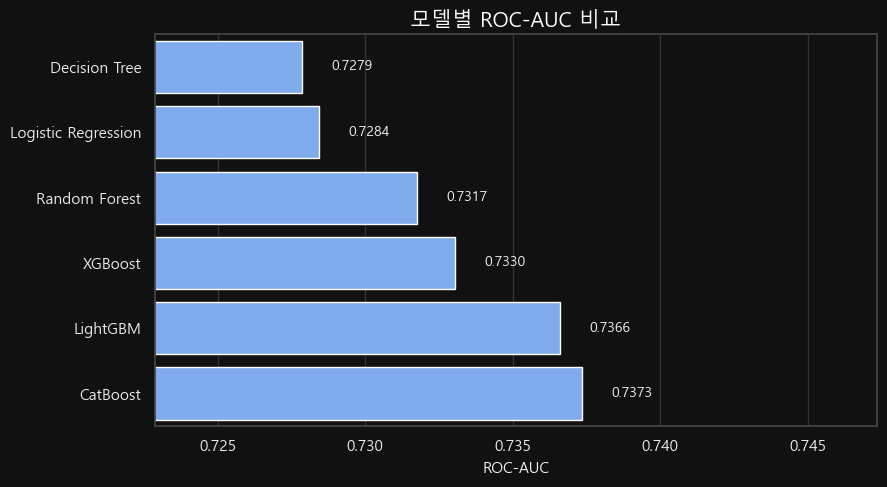

In [47]:
# ROC-AUC 비교 시각화
plot_df = model_plot_df.sort_values("ROC-AUC", ascending=True)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=plot_df,
    x="ROC-AUC",
    y="model",
    color=main_color
)

for i, row in plot_df.iterrows():
    ax.text(
        row["ROC-AUC"] + 0.001,
        list(plot_df.index).index(i),
        f'{row["ROC-AUC"]:.4f}',
        va="center",
        fontsize=10
    )

ax.set_title("모델별 ROC-AUC 비교")
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("")
ax.set_xlim(plot_df["ROC-AUC"].min() - 0.005, plot_df["ROC-AUC"].max() + 0.01)

plt.tight_layout()
plt.show()

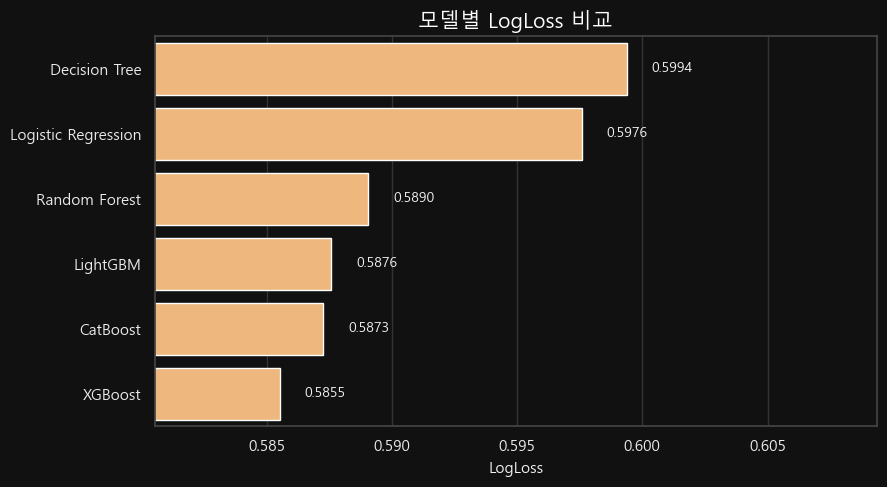

In [48]:
# LogLoss 비교 시각화
plot_df = model_plot_df.sort_values("LogLoss", ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=plot_df,
    x="LogLoss",
    y="model",
    color=accent_color
)

for i, row in plot_df.iterrows():
    ax.text(
        row["LogLoss"] + 0.001,
        list(plot_df.index).index(i),
        f'{row["LogLoss"]:.4f}',
        va="center",
        fontsize=10
    )

ax.set_title("모델별 LogLoss 비교")
ax.set_xlabel("LogLoss")
ax.set_ylabel("")
ax.set_xlim(plot_df["LogLoss"].min() - 0.005, plot_df["LogLoss"].max() + 0.01)

plt.tight_layout()
plt.show()

#### 03-5. 결과 해석

- ROC-AUC 기준으로는 CatBoost가 가장 높은 성능을 보였고, LightGBM은 CatBoost와 매우 유사한 수준을 기록하였다.
- Baseline 모델 중에서는 Random Forest가 가장 우수하였다.
- LogLoss 기준으로는 XGBoost가 가장 낮은 값을 보여, 확률 예측 안정성 측면에서 보완 가능성이 확인되었다.
- 단일 모델 성능만 보면 CatBoost가 1순위 후보이나, CatBoost·LightGBM·XGBoost는 서로 다른 학습 특성을 가지므로 ensemble을 통한 성능 개선 가능성이 있다.
- 최종 모델링에서는 CatBoost를 중심으로 두고, LightGBM과 XGBoost를 보조 모델로 포함하는 조합을 검토한다.


### 03-6. Feature Importance 확인

가장 높은 ROC-AUC를 보인 CatBoost 모델을 기준으로 feature importance를 확인한다.  
이를 통해 모델이 어떤 변수들을 주요 예측 신호로 활용했는지 파악하고, 이후 noise pruning 후보를 검토한다.

In [49]:
# CatBoost Feature Importance 확인
cat_feature_importance = pd.DataFrame({
    "feature": X_train_cb.columns,
    "importance": cat_model.get_feature_importance(cat_valid_pool),
})

cat_feature_importance = cat_feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

display(cat_feature_importance.head(30))

,feature,importance
0,이식된 배아 수,27.515302
1,이식된 배아 수_bin,26.352599
2,age_x_egg_source,10.462035
3,총 생성 배아 수_bin,5.120002
4,배아 이식 경과일,3.441719
5,stored_per_created_embryo,2.380604
6,배아 이식 경과일_is_missing,1.689301
7,시술 당시 나이,1.435227
8,저장된 배아 수_bin,1.350010
9,thawed_per_stored_embryo,0.968528


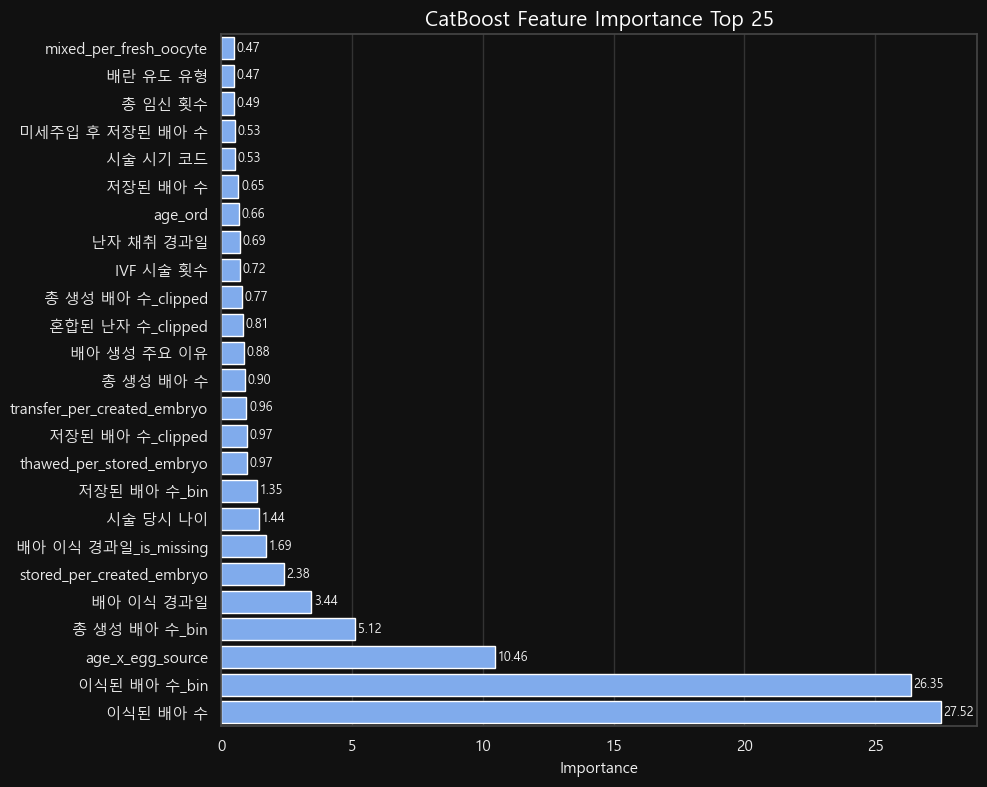

In [50]:
# 상위 Feature Importance 시각화
top_n = 25
plot_fi = cat_feature_importance.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=plot_fi,
    x="importance",
    y="feature",
    color=main_color
)

for i, row in plot_fi.iterrows():
    ax.text(
        row["importance"] + 0.1,
        list(plot_fi.index).index(i),
        f'{row["importance"]:.2f}',
        va="center",
        fontsize=9
    )

ax.set_title("CatBoost Feature Importance Top 25")
ax.set_xlabel("Importance")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [51]:
# 하위 Feature Importance 확인
display(cat_feature_importance.tail(30))

,feature,importance
103,age_unknown_flag,0.001947
104,unknown_proc_with_icsi_oocyte_flag,0.001723
105,fer_inferred_flag,0.001380
106,불임 원인 - 정자 농도,0.001043
107,단일 배아 이식 여부_missing_flag,0.000931
108,신선 배아 사용 여부_missing_flag,0.000867
109,저장된 신선 난자 수_missing_flag,0.000591
110,특정 시술 유형_is_missing,0.000335
111,해동 난자 수_missing_flag,0.000229
112,불임 원인 - 정자 면역학적 요인,0.000000


#### 03-6. Feature Importance 결과 해석

- CatBoost 기준 Feature Importance 상위 변수는 배아 이식, 나이, 난자 출처, 배아 생성·저장 관련 변수에 집중되었다.
- 가장 중요한 변수는 `이식된 배아 수`(importance 27.52), 두 번째 변수는 `이식된 배아 수_bin`(importance 26.35)이었다.
- 이는 배아 이식 여부와 이식 수 구간이 임신 성공 여부 예측에서 핵심적인 신호로 작동함을 의미한다.
- 세 번째로 중요한 변수는 `age_x_egg_source`(importance 10.46)로, 나이와 난자 출처의 조합이 단일 변수보다 강한 예측 신호가 될 수 있음을 보여준다. 공여 난자와 수령자 나이의 관계는 대규모 레지스트리 연구에서도 중요하게 다루어진다(HFEA, 2022; Cardozo et al., 2022; Reig et al., 2025).
- `총 생성 배아 수_bin`, `배아 이식 경과일`, `stored_per_created_embryo`, `배아 이식 경과일_is_missing`도 상위권에 포함되어, 모델이 실제 배아 생성·저장·이식 과정을 주요 신호로 활용하고 있음을 확인하였다.
- `시술 당시 나이`, `age_ord`, `age_38plus_flag`도 상위 변수에 포함되어, EDA에서 확인한 나이 효과가 모델에서도 반영되었다(Malizia et al., 2009; Sacchi et al., 2023).
- clipping 후보 변수 중 `저장된 배아 수_clipped`, `혼합된 난자 수_clipped`, `총 생성 배아 수_clipped`가 일부 상위권에 포함되어, 극단값 보정 후보도 일정한 정보를 제공할 가능성이 있다.
- 하위 중요도에는 구조적 missing flag와 희소 이진 변수가 많이 포함되었다.
- `process_missing_count` 및 여러 구조적 missing flag의 중요도가 0으로 나타난 것은 해당 정보가 이미 `시술 유형`, 원본 NaN, 관련 배아·난자 변수에 의해 설명되었기 때문으로 해석된다.
- `특정 시술 유형_is_missing`, `unknown_proc_with_icsi_oocyte_flag`처럼 발생 건수가 매우 적은 변수는 모델 활용도가 낮았다.
- Feature Importance가 낮다고 해서 즉시 제거하기보다는, 다른 모델 및 ensemble에서의 보조 신호 가능성을 고려하여 OOF 성능 변화를 기준으로 pruning 여부를 판단한다.


### 03-7. Ensemble 후보 비교

CatBoost, LightGBM, XGBoost는 서로 다른 방식으로 데이터를 학습하므로 예측값을 조합하면 성능이 개선될 수 있다.  
검증 데이터에서 각 모델의 예측 확률을 가중 평균하여 ROC-AUC와 LogLoss 변화를 확인한다.

In [52]:
# Ensemble 후보 가중치 비교
ensemble_results = []

weight_grid = [
    (0.6, 0.3, 0.1),
    (0.5, 0.4, 0.1),
    (0.5, 0.3, 0.2),
    (0.4, 0.4, 0.2),
    (0.4, 0.3, 0.3),
    (0.7, 0.2, 0.1),
    (0.8, 0.1, 0.1),
]

for cat_w, lgbm_w, xgb_w in weight_grid:
    ensemble_proba = (
        cat_w * cat_valid_proba
        + lgbm_w * lgbm_valid_proba
        + xgb_w * xgb_valid_proba
    )

    metrics = evaluate_binary_model(
        f"Ensemble C{cat_w}_L{lgbm_w}_X{xgb_w}",
        y_valid,
        ensemble_proba
    )

    metrics["cat_weight"] = cat_w
    metrics["lgbm_weight"] = lgbm_w
    metrics["xgb_weight"] = xgb_w

    ensemble_results.append(metrics)

ensemble_results_df = pd.DataFrame(ensemble_results).set_index("model")
ensemble_results_df = ensemble_results_df.sort_values("ROC-AUC", ascending=False)

display(ensemble_results_df)

,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score,cat_weight,lgbm_weight,xgb_weight
model,,,,,,,,,
Ensemble C0.7_L0.2_X0.1,0.737470,0.586497,0.622516,0.385481,0.776083,0.515107,0.7,0.2,0.1
Ensemble C0.6_L0.3_X0.1,0.737457,0.586482,0.622360,0.385339,0.775857,0.514931,0.6,0.3,0.1
Ensemble C0.8_L0.1_X0.1,0.737453,0.586538,0.622457,0.385446,0.776159,0.515093,0.8,0.1,0.1
Ensemble C0.5_L0.4_X0.1,0.737414,0.586491,0.621931,0.385004,0.775706,0.514599,0.5,0.4,0.1
Ensemble C0.5_L0.3_X0.2,0.737334,0.585977,0.622925,0.385578,0.774271,0.514795,0.5,0.3,0.2
Ensemble C0.4_L0.4_X0.2,0.737278,0.586000,0.622184,0.385011,0.774120,0.514256,0.4,0.4,0.2
Ensemble C0.4_L0.3_X0.3,0.737085,0.585574,0.622691,0.385223,0.772686,0.514128,0.4,0.3,0.3


In [53]:
# 단일 모델과 Ensemble 결과 비교
best_ensemble = ensemble_results_df.head(1)

model_compare_with_ensemble = pd.concat([
    model_results_df,
    best_ensemble.drop(columns=["cat_weight", "lgbm_weight", "xgb_weight"])
])

display(model_compare_with_ensemble.sort_values("ROC-AUC", ascending=False))

,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score
model,,,,,,
Ensemble C0.7_L0.2_X0.1,0.737470,0.586497,0.622516,0.385481,0.776083,0.515107
CatBoost,0.737350,0.587256,0.621677,0.384964,0.776989,0.514845
LightGBM,0.736605,0.587581,0.620214,0.384172,0.779481,0.514680
XGBoost,0.733032,0.585530,0.626826,0.386312,0.755096,0.511128
Random Forest,0.731746,0.589046,0.619161,0.382185,0.768987,0.510602
Logistic Regression,0.728438,0.597578,0.619044,0.382090,0.768911,0.510501
Decision Tree,0.727862,0.599370,0.601139,0.372279,0.792617,0.506611


#### 03-7. 결과 해석

- CatBoost, LightGBM, XGBoost의 예측 확률을 가중 평균하여 ensemble 후보를 비교하였다.
- 검증셋 기준 가장 높은 ROC-AUC는 `CatBoost 0.7 + LightGBM 0.2 + XGBoost 0.1` 조합에서 나타났다.
- 해당 ensemble의 ROC-AUC는 0.7375로, 단일 CatBoost의 0.7374보다 소폭 개선되었다.
- LogLoss는 0.5865로 CatBoost의 0.5873보다 낮아져, 예측 확률의 품질도 일부 개선되었다.
- Accuracy와 F1-score 역시 단일 CatBoost보다 약간 높게 나타났다.
- 개선 폭이 매우 작으므로, 단일 검증셋 기준의 가중치 최적화 결과만으로 최종 성능 향상을 확정하기는 어렵다.
- XGBoost 비중이 커질수록 LogLoss는 낮아지는 경향이 있으나, ROC-AUC는 소폭 하락하였다.
- 따라서 최종 제출 후보는 단일 split 결과가 아니라 K-Fold OOF 기반으로 다시 검증한다.


### 03-8. K-Fold OOF 검증: CatBoost

단일 train/valid split은 데이터 분할에 따라 성능이 달라질 수 있다.  
따라서 Stratified K-Fold를 사용하여 전체 train 데이터를 여러 fold로 나누고, 각 fold의 validation 예측을 모아 OOF 성능을 계산한다.

OOF 예측값은 각 행이 학습에 사용되지 않았던 fold에서 얻은 예측값이므로, 단일 검증셋보다 더 안정적인 내부 검증 지표로 활용할 수 있다.

In [55]:
# CatBoost 5-Fold OOF 검증
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, log_loss

N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

cat_oof_pred = np.zeros(len(X_cat))
cat_test_pred = np.zeros(len(X_test_cat))
cat_fold_results = []
cat_models = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_cat, y), 1):
    print(f"\n========== Fold {fold} ==========")

    X_tr = X_cat.iloc[tr_idx].copy()
    X_val = X_cat.iloc[val_idx].copy()
    y_tr = y.iloc[tr_idx].copy()
    y_val = y.iloc[val_idx].copy()

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    valid_pool = Pool(X_val, y_val, cat_features=cat_features)
    test_pool = Pool(X_test_cat, cat_features=cat_features)

    model = CatBoostClassifier(
        iterations=3000,
        learning_rate=0.03,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE + fold,
        auto_class_weights="Balanced",
        early_stopping_rounds=200,
        verbose=200,
    )

    model.fit(
        train_pool,
        eval_set=valid_pool,
        use_best_model=True,
    )

    val_pred = model.predict_proba(valid_pool)[:, 1]
    test_pred = model.predict_proba(test_pool)[:, 1]

    cat_oof_pred[val_idx] = val_pred
    cat_test_pred += test_pred / N_SPLITS
    cat_models.append(model)

    fold_auc = roc_auc_score(y_val, val_pred)
    fold_logloss = log_loss(y_val, val_pred)

    cat_fold_results.append({
        "fold": fold,
        "ROC-AUC": fold_auc,
        "LogLoss": fold_logloss,
        "best_iteration": model.get_best_iteration(),
    })

    print(f"Fold {fold} ROC-AUC: {fold_auc:.6f}")
    print(f"Fold {fold} LogLoss: {fold_logloss:.6f}")

cat_fold_results_df = pd.DataFrame(cat_fold_results)

cat_oof_metrics = evaluate_binary_model(
    "CatBoost 5-Fold OOF",
    y,
    cat_oof_pred
)

display(cat_fold_results_df)
display(pd.DataFrame([cat_oof_metrics]).set_index("model"))


========== Fold 1 ==========
0:	test: 0.7135041	best: 0.7135041 (0)	total: 331ms	remaining: 16m 33s
200:	test: 0.7365966	best: 0.7365966 (200)	total: 1m	remaining: 14m 7s
400:	test: 0.7378801	best: 0.7378818 (395)	total: 1m 55s	remaining: 12m 27s
600:	test: 0.7383335	best: 0.7383353 (593)	total: 2m 58s	remaining: 11m 54s
800:	test: 0.7384375	best: 0.7384516 (788)	total: 4m	remaining: 11m
1000:	test: 0.7385670	best: 0.7385893 (911)	total: 5m 6s	remaining: 10m 12s
1200:	test: 0.7386049	best: 0.7386124 (1125)	total: 6m 12s	remaining: 9m 17s
1400:	test: 0.7386316	best: 0.7386533 (1381)	total: 7m 14s	remaining: 8m 16s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.7386533233
bestIteration = 1381

Shrink model to first 1382 iterations.
Fold 1 ROC-AUC: 0.738653
Fold 1 LogLoss: 0.586572

========== Fold 2 ==========
0:	test: 0.7169927	best: 0.7169927 (0)	total: 312ms	remaining: 15m 34s
200:	test: 0.7398108	best: 0.7398108 (200)	total: 1m 3s	remaining: 14m 42s
400:	test: 

,fold,ROC-AUC,LogLoss,best_iteration
0,1,0.738653,0.586572,1381
1,2,0.742708,0.585014,1283
2,3,0.740734,0.585445,2026
3,4,0.738410,0.586788,870
4,5,0.740825,0.585914,1277


,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score
model,,,,,,
CatBoost 5-Fold OOF,0.740262,0.585947,0.622545,0.386402,0.784094,0.517688


#### 03-8. CatBoost 5-Fold OOF 결과 해석

- CatBoost 5-Fold의 fold별 ROC-AUC는 0.738410~0.742708 범위로 나타났다.
- 평균 ROC-AUC는 약 0.74026이며, 전체 OOF ROC-AUC도 0.740262로 거의 일치하였다.
- 단일 검증 분할 CatBoost ROC-AUC 0.737350보다 높아, K-Fold OOF 검증에서 더 안정적인 성능이 확인되었다.
- Fold 2가 가장 높고 Fold 4가 가장 낮았으나, fold 간 차이가 과도하게 크지는 않았다.
- 따라서 CatBoost는 단일 split보다 K-Fold 기반 검증에서 더 안정적인 기준 모델로 판단된다.


### 03-9. LightGBM 5-Fold OOF

CatBoost 5-Fold 단일 모델의 제출 점수를 기준선으로 두고, LightGBM을 동일한 K-Fold 구조로 학습한다.  
이후 CatBoost와 LightGBM의 OOF 예측값을 조합하여 앙상블 성능 개선 가능성을 확인한다.

In [57]:
# LightGBM 5-Fold OOF 학습
import lightgbm as lgb

lgb_oof_pred = np.zeros(len(X_ordinal))
lgb_test_pred = np.zeros(len(X_test_ordinal))
lgb_fold_results = []
lgb_models = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_ordinal, y), start=1):
    print(f"\n========== Fold {fold} ==========")

    X_tr = X_ordinal.iloc[train_idx]
    X_val = X_ordinal.iloc[valid_idx]
    y_tr = y.iloc[train_idx]
    y_val = y.iloc[valid_idx]

    lgb_model = lgb.LGBMClassifier(
        n_estimators=5000,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=RANDOM_STATE + fold,
        n_jobs=-1,
        objective="binary"
    )

    lgb_model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        callbacks=[
            lgb.early_stopping(stopping_rounds=200),
            lgb.log_evaluation(period=200)
        ]
    )

    val_pred = lgb_model.predict_proba(X_val)[:, 1]
    test_pred = lgb_model.predict_proba(X_test_ordinal)[:, 1]

    lgb_oof_pred[valid_idx] = val_pred
    lgb_test_pred += test_pred / skf.n_splits

    fold_auc = roc_auc_score(y_val, val_pred)
    fold_logloss = log_loss(y_val, val_pred)

    lgb_fold_results.append({
        "fold": fold,
        "ROC-AUC": fold_auc,
        "LogLoss": fold_logloss,
        "best_iteration": lgb_model.best_iteration_
    })

    lgb_models.append(lgb_model)

    print(f"Fold {fold} ROC-AUC: {fold_auc:.6f}")
    print(f"Fold {fold} LogLoss: {fold_logloss:.6f}")

lgb_fold_results_df = pd.DataFrame(lgb_fold_results)
display(lgb_fold_results_df)

lgb_oof_metrics = evaluate_binary_model("LightGBM 5-Fold OOF", y, lgb_oof_pred)
display(pd.DataFrame([lgb_oof_metrics]).set_index("model"))


========== Fold 1 ==========
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 52982, number of negative: 152098
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022632 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1868
[LightGBM] [Info] Number of data points in the train set: 205080, number of used features: 129
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 200 rounds
[200]	valid_0's auc: 0.737054	valid_0's binary_logloss: 0.588418
[400]	valid_0's auc: 0.737282	valid_0's binary_logloss: 0.587021
[600]	valid_0's auc: 0.737129	valid_0's binary_logloss: 0

,fold,ROC-AUC,LogLoss,best_iteration
0,1,0.737326,0.586827,430
1,2,0.742176,0.584400,466
2,3,0.739867,0.587038,222
3,4,0.738166,0.586776,233
4,5,0.740545,0.585302,338


,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score
model,,,,,,
LightGBM 5-Fold OOF,0.739595,0.586069,0.620158,0.385109,0.788156,0.517404


#### 03-9. LightGBM 5-Fold OOF 결과 해석

- LightGBM 5-Fold OOF의 최종 ROC-AUC는 0.739595로 나타났다.
- CatBoost 5-Fold OOF ROC-AUC 0.740262보다는 소폭 낮지만, 전반적으로 유사한 수준의 성능을 보였다.
- Fold별 ROC-AUC는 0.737326~0.742176 범위이며, Fold 2가 가장 높고 Fold 1이 가장 낮았다.
- LogLoss는 0.586069로 CatBoost의 0.585947과 거의 비슷하였다.
- Recall은 0.788156으로 CatBoost보다 약간 높아, 성공 클래스를 더 적극적으로 예측하는 경향이 있었다.
- ROC-AUC 기준 단독 1순위는 CatBoost이나, LightGBM은 예측 패턴 차이를 통해 OOF ensemble에서 보조 모델로 활용할 가치가 있다.

### 03-10. CatBoost + LightGBM OOF 앙상블 가중치 탐색


In [58]:
# CatBoost + LightGBM OOF 앙상블 가중치 탐색
ensemble_results = []

for cat_weight in np.arange(0.0, 1.01, 0.05):
    lgb_weight = 1 - cat_weight

    ensemble_oof_pred = (
        cat_weight * cat_oof_pred +
        lgb_weight * lgb_oof_pred
    )

    metrics = evaluate_binary_model(
        f"Ensemble C{cat_weight:.2f}_L{lgb_weight:.2f}",
        y,
        ensemble_oof_pred
    )

    metrics["cat_weight"] = cat_weight
    metrics["lgb_weight"] = lgb_weight

    ensemble_results.append(metrics)

ensemble_results_df = (
    pd.DataFrame(ensemble_results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(ensemble_results_df)

,model,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score,cat_weight,lgb_weight
0,Ensemble C0.70_L0.30,0.740422,0.585715,0.622088,0.386256,0.785785,0.517924,0.70,0.30
1,Ensemble C0.65_L0.35,0.740420,0.585698,0.621940,0.386172,0.786012,0.517898,0.65,0.35
2,Ensemble C0.75_L0.25,0.740415,0.585737,0.622186,0.386283,0.785393,0.517864,0.75,0.25
3,Ensemble C0.60_L0.40,0.740410,0.585688,0.621808,0.386088,0.786133,0.517849,0.60,0.40
4,Ensemble C0.80_L0.20,0.740400,0.585766,0.622323,0.386350,0.785091,0.517858,0.80,0.20
5,Ensemble C0.55_L0.45,0.740391,0.585685,0.621839,0.386106,0.786087,0.517855,0.55,0.45
6,Ensemble C0.85_L0.15,0.740377,0.585802,0.622377,0.386358,0.784804,0.517803,0.85,0.15
7,Ensemble C0.50_L0.50,0.740363,0.585687,0.621679,0.386002,0.786208,0.517788,0.50,0.50
8,Ensemble C0.90_L0.10,0.740346,0.585843,0.622471,0.386414,0.784683,0.517826,0.90,0.10
9,Ensemble C0.45_L0.55,0.740327,0.585696,0.621581,0.385973,0.786586,0.517843,0.45,0.55


#### 03-10. 결과 해석

- CatBoost와 LightGBM OOF 예측값을 조합한 결과, 최고 조합은 `CatBoost 0.70 + LightGBM 0.30`이었다.
- ROC-AUC는 0.740422로, CatBoost 단독 0.740262보다 약 +0.000160 상승하였다.
- 상승폭은 작지만, 서로 다른 boosting 모델을 조합했을 때 OOF 기준의 앙상블 효과가 확인되었다.
- LogLoss도 0.585715로 CatBoost 단독 0.585947보다 개선되었다.
- 본 프로젝트의 핵심 평가지표가 ROC-AUC이므로, `C0.70_L0.30` 조합은 2-model ensemble의 주요 제출 후보로 볼 수 있다.


In [59]:
# 03-11. 세밀 가중치 탐색
fine_ensemble_results = []

for cat_weight in np.arange(0.60, 0.801, 0.01):
    lgb_weight = 1 - cat_weight

    ensemble_oof_pred = (
        cat_weight * cat_oof_pred +
        lgb_weight * lgb_oof_pred
    )

    metrics = evaluate_binary_model(
        f"Fine Ensemble C{cat_weight:.2f}_L{lgb_weight:.2f}",
        y,
        ensemble_oof_pred
    )

    metrics["cat_weight"] = cat_weight
    metrics["lgb_weight"] = lgb_weight
    fine_ensemble_results.append(metrics)

fine_ensemble_results_df = (
    pd.DataFrame(fine_ensemble_results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(fine_ensemble_results_df.head(10))

,model,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score,cat_weight,lgb_weight
0,Fine Ensemble C0.68_L0.32,0.740422,0.585707,0.621999,0.386205,0.785921,0.517908,0.68,0.32
1,Fine Ensemble C0.69_L0.31,0.740422,0.585711,0.622038,0.386227,0.785861,0.517914,0.69,0.31
2,Fine Ensemble C0.67_L0.33,0.740422,0.585704,0.622038,0.386244,0.786012,0.517962,0.67,0.33
3,Fine Ensemble C0.70_L0.30,0.740422,0.585715,0.622088,0.386256,0.785785,0.517924,0.70,0.30
4,Fine Ensemble C0.66_L0.34,0.740421,0.585701,0.622053,0.386264,0.786087,0.517997,0.66,0.34
5,Fine Ensemble C0.71_L0.29,0.740421,0.585719,0.622127,0.386283,0.785770,0.517945,0.71,0.29
6,Fine Ensemble C0.65_L0.35,0.740420,0.585698,0.621940,0.386172,0.786012,0.517898,0.65,0.35
7,Fine Ensemble C0.72_L0.28,0.740420,0.585723,0.622135,0.386275,0.785650,0.517912,0.72,0.28
8,Fine Ensemble C0.64_L0.36,0.740419,0.585696,0.621960,0.386198,0.786118,0.517944,0.64,0.36
9,Fine Ensemble C0.73_L0.27,0.740418,0.585727,0.622174,0.386307,0.785680,0.517947,0.73,0.27


#### 03-11. 세부 가중치 탐색 메모 정리

- CatBoost 0.70, LightGBM 0.30 인근에서 0.31~0.33 수준의 세부 가중치를 추가로 확인하였다.
- 세부 탐색 결과, ROC-AUC 개선은 기존 조합과 거의 동일한 수준이었다.
- 일부 보조 지표는 오히려 낮아지는 경향이 있어, 복잡한 세부 가중치보다 단순한 `C0.70_L0.30` 조합을 유지하는 것이 적절하다.
- 이후 단계에서는 두 모델 조합에 머무르지 않고, XGBoost를 포함한 3-model OOF ensemble로 확장한다.


In [60]:
# 03-12. Rank Average 앙상블

from scipy.stats import rankdata

cat_oof_rank = rankdata(cat_oof_pred) / len(cat_oof_pred)
lgb_oof_rank = rankdata(lgb_oof_pred) / len(lgb_oof_pred)

rank_ensemble_results = []

for cat_weight in np.arange(0.60, 0.801, 0.01):
    lgb_weight = 1 - cat_weight

    rank_oof_pred = (
        cat_weight * cat_oof_rank +
        lgb_weight * lgb_oof_rank
    )

    metrics = evaluate_binary_model(
        f"Rank Ensemble C{cat_weight:.2f}_L{lgb_weight:.2f}",
        y,
        rank_oof_pred
    )

    metrics["cat_weight"] = cat_weight
    metrics["lgb_weight"] = lgb_weight
    rank_ensemble_results.append(metrics)

rank_ensemble_results_df = (
    pd.DataFrame(rank_ensemble_results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(rank_ensemble_results_df.head(10))

,model,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score,cat_weight,lgb_weight
0,Rank Ensemble C0.69_L0.31,0.740433,0.717326,0.633655,0.392148,0.759966,0.517343,0.69,0.31
1,Rank Ensemble C0.68_L0.32,0.740433,0.717297,0.633733,0.392214,0.760011,0.517411,0.68,0.32
2,Rank Ensemble C0.67_L0.33,0.740433,0.717269,0.633733,0.392217,0.760041,0.517421,0.67,0.33
3,Rank Ensemble C0.70_L0.30,0.740433,0.717358,0.633682,0.392166,0.759935,0.517352,0.70,0.30
4,Rank Ensemble C0.71_L0.29,0.740432,0.717392,0.633620,0.392115,0.759920,0.517304,0.71,0.29
5,Rank Ensemble C0.66_L0.34,0.740432,0.717244,0.633717,0.392205,0.760041,0.517410,0.66,0.34
6,Rank Ensemble C0.72_L0.28,0.740431,0.717429,0.633635,0.392114,0.759799,0.517275,0.72,0.28
7,Rank Ensemble C0.65_L0.35,0.740431,0.717221,0.633709,0.392201,0.760056,0.517410,0.65,0.35
8,Rank Ensemble C0.73_L0.27,0.740430,0.717468,0.633678,0.392149,0.759815,0.517309,0.73,0.27
9,Rank Ensemble C0.64_L0.36,0.740429,0.717201,0.633674,0.392163,0.759966,0.517356,0.64,0.36


### 03-13. AUC 개선을 위한 추가 모델링 전략

- v5에서는 기존 CatBoost·LightGBM 5-Fold OOF 구조를 유지하면서, XGBoost를 동일한 K-Fold OOF 구조로 추가한다.
- CatBoost, LightGBM, XGBoost 세 모델의 OOF 예측값을 기준으로 3-model weighted ensemble을 탐색한다.
- ROC-AUC가 순위 기반 지표라는 점을 고려하여 3-model Rank Average ensemble도 함께 검토한다.
- 확률 기반 weighted ensemble과 순위 기반 rank ensemble을 다시 조합하는 hybrid ensemble을 추가로 확인한다.
- 모든 가중치 선택은 test 점수가 아니라 train 내부 OOF ROC-AUC 기준으로 수행한다.
- 이러한 접근은 IVF/ART 예측 연구에서 XGBoost 등 ML 모델의 유효성이 보고된 점과도 방향이 일치한다(Qiu et al., 2019; Amini et al., 2024; Karayiannis et al., 2025).


In [61]:
# 03-13. 개선안 실행 전 현재 사용 가능한 OOF 예측값 확인

required_oof_objects = {
    "cat_oof_pred": "CatBoost 5-Fold OOF 예측값",
    "cat_test_pred": "CatBoost 5-Fold 제출용 예측값",
    "lgb_oof_pred": "LightGBM 5-Fold OOF 예측값",
    "lgb_test_pred": "LightGBM 5-Fold 제출용 예측값",
}

for obj_name, description in required_oof_objects.items():
    if obj_name not in globals():
        raise NameError(f"{obj_name}이 없습니다. 먼저 해당 모델의 5-Fold 셀을 실행하세요. ({description})")

print("기존 OOF 예측값 확인 완료")
print("cat_oof_pred:", cat_oof_pred.shape)
print("lgb_oof_pred:", lgb_oof_pred.shape)
print("cat_test_pred:", cat_test_pred.shape)
print("lgb_test_pred:", lgb_test_pred.shape)


기존 OOF 예측값 확인 완료
cat_oof_pred: (256351,)
lgb_oof_pred: (256351,)
cat_test_pred: (90067,)
lgb_test_pred: (90067,)


### 03-14. XGBoost 5-Fold OOF 추가

기존 v3에서는 XGBoost를 단일 train/valid split에서만 확인했다.  
CatBoost, LightGBM과 같은 조건으로 비교하려면 XGBoost도 5-Fold OOF 예측값을 만들어야 한다.

XGBoost 단독 점수가 CatBoost보다 낮더라도, 다른 모델과 오류 패턴이 다르면 ensemble에서 AUC 개선에 기여할 수 있다.


In [62]:
# XGBoost 5-Fold OOF 학습
from xgboost import XGBClassifier

xgb_oof_pred = np.zeros(len(X_ordinal))
xgb_test_pred = np.zeros(len(X_test_ordinal))
xgb_fold_results = []
xgb_models = []

neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
scale_pos_weight = neg_count / pos_count

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_ordinal, y), start=1):
    print(f"\n========== Fold {fold} ==========")

    X_tr = X_ordinal.iloc[train_idx]
    X_val = X_ordinal.iloc[valid_idx]
    y_tr = y.iloc[train_idx]
    y_val = y.iloc[valid_idx]

    xgb_model = XGBClassifier(
        n_estimators=3000,
        learning_rate=0.025,
        max_depth=4,
        min_child_weight=12,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=8.0,
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE + fold,
        n_jobs=-1,
        early_stopping_rounds=200,
    )

    xgb_model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        verbose=200,
    )

    val_pred = xgb_model.predict_proba(X_val)[:, 1]
    test_pred = xgb_model.predict_proba(X_test_ordinal)[:, 1]

    xgb_oof_pred[valid_idx] = val_pred
    xgb_test_pred += test_pred / skf.n_splits

    fold_auc = roc_auc_score(y_val, val_pred)
    fold_logloss = log_loss(y_val, val_pred)

    xgb_fold_results.append({
        "fold": fold,
        "ROC-AUC": fold_auc,
        "LogLoss": fold_logloss,
        "best_iteration": getattr(xgb_model, "best_iteration", None),
    })

    xgb_models.append(xgb_model)

    print(f"Fold {fold} ROC-AUC: {fold_auc:.6f}")
    print(f"Fold {fold} LogLoss: {fold_logloss:.6f}")

xgb_fold_results_df = pd.DataFrame(xgb_fold_results)
display(xgb_fold_results_df)

xgb_oof_metrics = evaluate_binary_model("XGBoost 5-Fold OOF", y, xgb_oof_pred)
display(pd.DataFrame([xgb_oof_metrics]).set_index("model"))


========== Fold 1 ==========
[0]	validation_0-auc:0.71172
[200]	validation_0-auc:0.73396
[400]	validation_0-auc:0.73705
[600]	validation_0-auc:0.73794
[800]	validation_0-auc:0.73821
[1000]	validation_0-auc:0.73834
[1190]	validation_0-auc:0.73827
Fold 1 ROC-AUC: 0.738347
Fold 1 LogLoss: 0.587264

========== Fold 2 ==========
[0]	validation_0-auc:0.71191
[200]	validation_0-auc:0.73711
[400]	validation_0-auc:0.74133
[600]	validation_0-auc:0.74245
[800]	validation_0-auc:0.74290
[1000]	validation_0-auc:0.74310
[1200]	validation_0-auc:0.74318
[1400]	validation_0-auc:0.74317
[1514]	validation_0-auc:0.74317
Fold 2 ROC-AUC: 0.743208
Fold 2 LogLoss: 0.584671

========== Fold 3 ==========
[0]	validation_0-auc:0.71454
[200]	validation_0-auc:0.73605
[400]	validation_0-auc:0.73908
[600]	validation_0-auc:0.73976
[800]	validation_0-auc:0.73999
[1000]	validation_0-auc:0.74007
[1196]	validation_0-auc:0.73996
Fold 3 ROC-AUC: 0.740074
Fold 3 LogLoss: 0.586433

========== Fold 4 ==========
[0]	validation_

,fold,ROC-AUC,LogLoss,best_iteration
0,1,0.738347,0.587264,990
1,2,0.743208,0.584671,1314
2,3,0.740074,0.586433,996
3,4,0.738300,0.586898,780
4,5,0.741232,0.585520,903


,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score
model,,,,,,
XGBoost 5-Fold OOF,0.740229,0.586157,0.622135,0.386104,0.784125,0.517427


#### 03-14. 결과 해석

- XGBoost 5-Fold OOF ROC-AUC는 0.740229로 나타났다.
- CatBoost 0.740262와 거의 유사하며, LightGBM 0.739595보다는 높았다.
- Fold별 ROC-AUC는 0.738300~0.743208 범위로, CatBoost와 비슷한 수준의 안정성을 보였다.
- Fold 2가 0.743208로 가장 높고 Fold 4가 0.738300으로 가장 낮았다.
- LogLoss는 0.586157로 CatBoost 0.585947보다 약간 높았으나, 차이는 크지 않았다.
- Recall도 0.784125로 CatBoost 0.784094와 거의 동일하였다.
- 따라서 XGBoost는 단일 split에서는 약했지만, K-Fold OOF 기준에서는 CatBoost와 비슷한 수준의 경쟁력을 보이며 3-model ensemble에 포함할 가치가 있다.


### 03-15. 3-Model OOF Weighted Ensemble

CatBoost, LightGBM, XGBoost 세 모델의 OOF 예측값을 가중 평균한다.  
가중치 탐색은 OOF ROC-AUC 기준으로 수행하며, test 예측값은 아직 사용하지 않는다.


In [63]:
# CatBoost + LightGBM + XGBoost 3-model 가중치 탐색
three_model_results = []

for cat_weight in np.arange(0.40, 0.91, 0.05):
    for lgb_weight in np.arange(0.00, 0.61, 0.05):
        xgb_weight = 1 - cat_weight - lgb_weight

        if xgb_weight < 0:
            continue

        ensemble_oof_pred = (
            cat_weight * cat_oof_pred
            + lgb_weight * lgb_oof_pred
            + xgb_weight * xgb_oof_pred
        )

        metrics = evaluate_binary_model(
            f"Ensemble C{cat_weight:.2f}_L{lgb_weight:.2f}_X{xgb_weight:.2f}",
            y,
            ensemble_oof_pred
        )

        metrics["cat_weight"] = cat_weight
        metrics["lgb_weight"] = lgb_weight
        metrics["xgb_weight"] = xgb_weight

        three_model_results.append(metrics)

three_model_results_df = (
    pd.DataFrame(three_model_results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(three_model_results_df.head(20))


,model,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score,cat_weight,lgb_weight,xgb_weight
0,Ensemble C0.50_L0.10_X0.40,0.740548,0.585759,0.622346,0.386411,0.785483,0.517998,0.50,0.10,0.40
1,Ensemble C0.45_L0.10_X0.45,0.740548,0.585768,0.622420,0.386467,0.785499,0.518052,0.45,0.10,0.45
2,Ensemble C0.45_L0.15_X0.40,0.740546,0.585743,0.622323,0.386429,0.785801,0.518083,0.45,0.15,0.40
3,Ensemble C0.50_L0.05_X0.45,0.740546,0.585787,0.622365,0.386399,0.785242,0.517934,0.50,0.05,0.45
4,Ensemble C0.50_L0.15_X0.35,0.740546,0.585735,0.622260,0.386385,0.785816,0.518047,0.50,0.15,0.35
5,Ensemble C0.45_L0.05_X0.50,0.740544,0.585798,0.622463,0.386464,0.785181,0.517980,0.45,0.05,0.50
6,Ensemble C0.55_L0.10_X0.35,0.740544,0.585753,0.622358,0.386416,0.785453,0.517996,0.55,0.10,0.35
7,Ensemble C0.55_L0.05_X0.40,0.740542,0.585780,0.622358,0.386386,0.785181,0.517910,0.55,0.05,0.40
8,Ensemble C0.40_L0.10_X0.50,0.740542,0.585783,0.622424,0.386479,0.785574,0.518079,0.40,0.10,0.50
9,Ensemble C0.40_L0.15_X0.45,0.740542,0.585757,0.622408,0.386503,0.785891,0.518169,0.40,0.15,0.45


In [64]:
# 3-model weighted ensemble 제출용 예측값 생성
best_three = three_model_results_df.iloc[0]

best_cat_weight = best_three["cat_weight"]
best_lgb_weight = best_three["lgb_weight"]
best_xgb_weight = best_three["xgb_weight"]

three_model_oof_pred = (
    best_cat_weight * cat_oof_pred
    + best_lgb_weight * lgb_oof_pred
    + best_xgb_weight * xgb_oof_pred
)

three_model_test_pred = (
    best_cat_weight * cat_test_pred
    + best_lgb_weight * lgb_test_pred
    + best_xgb_weight * xgb_test_pred
)

print("Best 3-model weighted ensemble")
print(best_three[["model", "ROC-AUC", "LogLoss", "cat_weight", "lgb_weight", "xgb_weight"]])
print("OOF ROC-AUC:", roc_auc_score(y, three_model_oof_pred))

Best 3-model weighted ensemble
model         Ensemble C0.50_L0.10_X0.40
ROC-AUC                         0.740548
LogLoss                         0.585759
cat_weight                           0.5
lgb_weight                           0.1
xgb_weight                           0.4
Name: 0, dtype: object
OOF ROC-AUC: 0.7405484521751373


### 03-16. 3-Model Rank Average Ensemble

ROC-AUC는 예측 확률의 절대값보다 순위를 중요하게 보는 지표이다.  
따라서 각 모델의 예측값을 순위로 변환한 뒤 평균내는 Rank Average를 추가로 확인한다.

Rank Average는 LogLoss에는 불리할 수 있지만, ROC-AUC 기준에서는 제출 점수를 미세하게 올리는 후보가 될 수 있다.


In [65]:
# 3-model Rank Average 가중치 탐색
from scipy.stats import rankdata

cat_oof_rank = rankdata(cat_oof_pred) / len(cat_oof_pred)
lgb_oof_rank = rankdata(lgb_oof_pred) / len(lgb_oof_pred)
xgb_oof_rank = rankdata(xgb_oof_pred) / len(xgb_oof_pred)

cat_test_rank = rankdata(cat_test_pred) / len(cat_test_pred)
lgb_test_rank = rankdata(lgb_test_pred) / len(lgb_test_pred)
xgb_test_rank = rankdata(xgb_test_pred) / len(xgb_test_pred)

rank_three_results = []

for cat_weight in np.arange(0.40, 0.91, 0.05):
    for lgb_weight in np.arange(0.00, 0.61, 0.05):
        xgb_weight = 1 - cat_weight - lgb_weight

        if xgb_weight < 0:
            continue

        rank_oof_pred = (
            cat_weight * cat_oof_rank
            + lgb_weight * lgb_oof_rank
            + xgb_weight * xgb_oof_rank
        )

        metrics = evaluate_binary_model(
            f"Rank Ensemble C{cat_weight:.2f}_L{lgb_weight:.2f}_X{xgb_weight:.2f}",
            y,
            rank_oof_pred
        )

        metrics["cat_weight"] = cat_weight
        metrics["lgb_weight"] = lgb_weight
        metrics["xgb_weight"] = xgb_weight

        rank_three_results.append(metrics)

rank_three_results_df = (
    pd.DataFrame(rank_three_results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(rank_three_results_df.head(20))


,model,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score,cat_weight,lgb_weight,xgb_weight
0,Rank Ensemble C0.50_L0.10_X0.40,0.740559,0.717259,0.633514,0.391994,0.759573,0.517118,0.50,0.10,0.40
1,Rank Ensemble C0.45_L0.10_X0.45,0.740558,0.717264,0.633401,0.391884,0.759377,0.516977,0.45,0.10,0.45
2,Rank Ensemble C0.45_L0.15_X0.40,0.740556,0.717077,0.633448,0.391944,0.759588,0.517078,0.45,0.15,0.40
3,Rank Ensemble C0.50_L0.15_X0.35,0.740556,0.717082,0.633569,0.392042,0.759618,0.517170,0.50,0.15,0.35
4,Rank Ensemble C0.50_L0.05_X0.45,0.740556,0.717489,0.633612,0.392072,0.759588,0.517190,0.50,0.05,0.45
5,Rank Ensemble C0.55_L0.10_X0.35,0.740554,0.717288,0.633620,0.392098,0.759769,0.517254,0.55,0.10,0.35
6,Rank Ensemble C0.45_L0.05_X0.50,0.740553,0.717505,0.633456,0.391921,0.759331,0.516999,0.45,0.05,0.50
7,Rank Ensemble C0.55_L0.05_X0.40,0.740552,0.717509,0.633674,0.392138,0.759739,0.517282,0.55,0.05,0.40
8,Rank Ensemble C0.40_L0.15_X0.45,0.740551,0.717107,0.633323,0.391833,0.759467,0.516953,0.40,0.15,0.45
9,Rank Ensemble C0.40_L0.10_X0.50,0.740551,0.717304,0.633362,0.391843,0.759286,0.516920,0.40,0.10,0.50


#### 03-15. Rank Average 사전 검토

- Rank Average는 weighted ensemble보다 OOF 기준 ROC-AUC가 약 +0.000011 높게 나타났다.
- 개선 폭은 매우 작으므로, “확실한 우위”라기보다 추가 제출 후보가 생긴 정도로 해석한다.
- Rank 방식은 ROC-AUC처럼 순위 기반 평가지표에는 유리할 수 있으나, 예측 확률의 절대값을 보정하지 않기 때문에 LogLoss가 0.717259로 크게 악화되었다.
- 대회 핵심 평가지표가 ROC-AUC라면 Rank 후보를 검토할 수 있지만, public test에서 흔들릴 가능성이 있어 단독 제출은 신중하게 판단한다.


In [67]:
# 3-model Rank Average 제출용 예측값 생성
best_rank_three = rank_three_results_df.iloc[0]

rank_cat_weight = best_rank_three["cat_weight"]
rank_lgb_weight = best_rank_three["lgb_weight"]
rank_xgb_weight = best_rank_three["xgb_weight"]

rank_three_oof_pred = (
    rank_cat_weight * cat_oof_rank
    + rank_lgb_weight * lgb_oof_rank
    + rank_xgb_weight * xgb_oof_rank
)

rank_three_test_pred = (
    rank_cat_weight * cat_test_rank
    + rank_lgb_weight * lgb_test_rank
    + rank_xgb_weight * xgb_test_rank
)

print("Best 3-model rank ensemble")
print(best_rank_three[["model", "ROC-AUC", "LogLoss", "cat_weight", "lgb_weight", "xgb_weight"]])
print("OOF ROC-AUC:", roc_auc_score(y, rank_three_oof_pred))

Best 3-model rank ensemble
model         Rank Ensemble C0.50_L0.10_X0.40
ROC-AUC                              0.740559
LogLoss                              0.717259
cat_weight                                0.5
lgb_weight                                0.1
xgb_weight                                0.4
Name: 0, dtype: object
OOF ROC-AUC: 0.7405586150107876


#### 03-16. 결과 해석

- 3-model Rank Average에서 가장 높은 OOF ROC-AUC는 0.740559로 나타났다.
- 최고 조합은 `CatBoost 0.50 + LightGBM 0.10 + XGBoost 0.40`이었다.
- 이는 3-model weighted ensemble의 0.740548보다 약 +0.000011 높은 수준이다.
- Rank Average는 예측 확률값을 직접 평균하지 않고 각 모델의 예측 순위를 평균하는 방식이다.
- 따라서 ROC-AUC처럼 순위 기반 평가지표에는 유리할 수 있으나, 확률 보정 품질을 평가하는 LogLoss에는 불리하다.
- 실제로 LogLoss는 0.717259로 weighted ensemble보다 크게 높았다.
- 최종 판단에서는 OOF ROC-AUC만 보지 않고, weighted ensemble과 hybrid ensemble의 안정성도 함께 비교한다.


### 03-17. Raw + Rank Hybrid Ensemble

확률 기반 weighted ensemble은 확률 품질이 좋고, Rank Average는 ROC-AUC의 순위 특성에 잘 맞는다.  
두 예측값을 다시 섞어 OOF 기준 최적 비율을 찾는다.


In [68]:
# Raw weighted ensemble과 Rank Average ensemble을 다시 조합
hybrid_results = []

for raw_weight in np.arange(0.0, 1.01, 0.05):
    rank_weight = 1 - raw_weight

    hybrid_oof_pred = (
        raw_weight * three_model_oof_pred
        + rank_weight * rank_three_oof_pred
    )

    metrics = evaluate_binary_model(
        f"Hybrid Raw{raw_weight:.2f}_Rank{rank_weight:.2f}",
        y,
        hybrid_oof_pred
    )

    metrics["raw_weight"] = raw_weight
    metrics["rank_weight"] = rank_weight

    hybrid_results.append(metrics)

hybrid_results_df = (
    pd.DataFrame(hybrid_results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(hybrid_results_df)

,model,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score,raw_weight,rank_weight
0,Hybrid Raw0.00_Rank1.00,0.740559,0.717259,0.633514,0.391994,0.759573,0.517118,0.00,1.00
1,Hybrid Raw0.05_Rank0.95,0.740558,0.699692,0.633202,0.391844,0.760419,0.517183,0.05,0.95
2,Hybrid Raw0.10_Rank0.90,0.740558,0.686940,0.632894,0.391701,0.761294,0.517261,0.10,0.90
3,Hybrid Raw0.15_Rank0.85,0.740558,0.676242,0.632555,0.391541,0.762230,0.517337,0.15,0.85
4,Hybrid Raw0.20_Rank0.80,0.740557,0.666881,0.632176,0.391329,0.762970,0.517323,0.20,0.80
5,Hybrid Raw0.25_Rank0.75,0.740557,0.658503,0.631810,0.391124,0.763680,0.517306,0.25,0.75
6,Hybrid Raw0.30_Rank0.70,0.740556,0.650899,0.631388,0.390902,0.764616,0.517326,0.30,0.70
7,Hybrid Raw0.35_Rank0.65,0.740556,0.643929,0.630893,0.390639,0.765688,0.517341,0.35,0.65
8,Hybrid Raw0.40_Rank0.60,0.740556,0.637493,0.630460,0.390433,0.766836,0.517422,0.40,0.60
9,Hybrid Raw0.45_Rank0.55,0.740555,0.631518,0.629996,0.390181,0.767772,0.517413,0.45,0.55


In [69]:
# Hybrid ensemble 제출용 예측값 생성
best_hybrid = hybrid_results_df.iloc[0]

best_raw_weight = best_hybrid["raw_weight"]
best_rank_weight = best_hybrid["rank_weight"]

hybrid_oof_pred = (
    best_raw_weight * three_model_oof_pred
    + best_rank_weight * rank_three_oof_pred
)

hybrid_test_pred = (
    best_raw_weight * three_model_test_pred
    + best_rank_weight * rank_three_test_pred
)

print("Best hybrid ensemble")
print(best_hybrid[["model", "ROC-AUC", "LogLoss", "raw_weight", "rank_weight"]])
print("OOF ROC-AUC:", roc_auc_score(y, hybrid_oof_pred))

Best hybrid ensemble
model          Hybrid Raw0.00_Rank1.00
ROC-AUC                       0.740559
LogLoss                       0.717259
raw_weight                         0.0
rank_weight                        1.0
Name: 0, dtype: object
OOF ROC-AUC: 0.7405586150107876


#### 03-17. 결과 해석

- Raw weighted ensemble과 Rank Average ensemble을 다시 조합한 결과, 가장 높은 OOF ROC-AUC는 0.740559로 나타났다.
- 최고 조합은 `Raw 0.00 + Rank 1.00`으로, hybrid 방식에서는 Rank Average 단독이 OOF 기준 최적이었다.
- 다만 Rank Average는 순위 기반 변환을 사용하므로 LogLoss가 0.717259로 높게 나타났다.
- 본 프로젝트의 핵심 평가지표가 ROC-AUC인 점을 고려하면 Rank Average는 공격적 제출 후보로 볼 수 있다.
- 그러나 제출 안정성과 확률 품질까지 고려하면, weighted ensemble도 함께 유지하는 것이 안전하다.
- 최종 후보는 다음과 같이 구분한다.
  - 공격적 후보: `3-model Rank Average C0.50_L0.10_X0.40`
  - 안정적 후보: `3-model Weighted Ensemble C0.50_L0.10_X0.40`


### 03-18. 3-Model Weighted Fine Search

기존 3-model weighted ensemble의 최고 조합은 `CatBoost 0.50 + LightGBM 0.10 + XGBoost 0.40`이었다.  
해당 탐색은 0.05 단위로 수행되었으므로, 최고 조합 주변을 0.01 단위로 세밀하게 다시 탐색한다.

이 단계에서는 모델을 다시 학습하지 않고, 이미 생성된 OOF 예측값을 조합한다.

In [71]:
# 3-model weighted fine search

fine_three_results = []

for cat_weight in np.arange(0.42, 0.59, 0.01):
    for lgb_weight in np.arange(0.00, 0.21, 0.01):
        xgb_weight = 1 - cat_weight - lgb_weight

        if xgb_weight < 0.25 or xgb_weight > 0.55:
            continue

        fine_oof = (
            cat_weight * cat_oof_pred
            + lgb_weight * lgb_oof_pred
            + xgb_weight * xgb_oof_pred
        )

        metrics = evaluate_binary_model(
            f"Fine3 C{cat_weight:.2f}_L{lgb_weight:.2f}_X{xgb_weight:.2f}",
            y,
            fine_oof
        )

        metrics["cat_weight"] = cat_weight
        metrics["lgb_weight"] = lgb_weight
        metrics["xgb_weight"] = xgb_weight

        fine_three_results.append(metrics)

fine_three_results_df = (
    pd.DataFrame(fine_three_results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(fine_three_results_df.head(20))

,model,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score,cat_weight,lgb_weight,xgb_weight
0,Fine3 C0.47_L0.11_X0.42,0.740549,0.585759,0.622420,0.386484,0.785650,0.518100,0.47,0.11,0.42
1,Fine3 C0.48_L0.11_X0.41,0.740549,0.585757,0.622412,0.386474,0.785604,0.518080,0.48,0.11,0.41
2,Fine3 C0.47_L0.12_X0.41,0.740549,0.585754,0.622428,0.386502,0.785755,0.518139,0.47,0.12,0.41
3,Fine3 C0.48_L0.10_X0.42,0.740549,0.585762,0.622412,0.386465,0.785529,0.518056,0.48,0.10,0.42
4,Fine3 C0.47_L0.10_X0.43,0.740549,0.585764,0.622424,0.386475,0.785544,0.518069,0.47,0.10,0.43
5,Fine3 C0.46_L0.11_X0.43,0.740549,0.585761,0.622358,0.386422,0.785499,0.518011,0.46,0.11,0.43
6,Fine3 C0.46_L0.12_X0.42,0.740549,0.585756,0.622385,0.386469,0.785740,0.518106,0.46,0.12,0.42
7,Fine3 C0.49_L0.10_X0.41,0.740549,0.585760,0.622299,0.386372,0.785438,0.517953,0.49,0.10,0.41
8,Fine3 C0.49_L0.11_X0.40,0.740549,0.585755,0.622373,0.386436,0.785529,0.518031,0.49,0.11,0.40
9,Fine3 C0.48_L0.09_X0.43,0.740549,0.585767,0.622420,0.386456,0.785393,0.518018,0.48,0.09,0.43


#### 03-18. 결과 해석

- 3-model weighted ensemble의 최고 조합 주변을 0.01 단위로 세밀하게 탐색하였다.
- Fine search 결과, 가장 높은 OOF ROC-AUC는 약 0.740549였다.
- 기존 조합 `CatBoost 0.50 + LightGBM 0.10 + XGBoost 0.40`의 OOF ROC-AUC 0.740548과 거의 동일하였다.
- 최고 조합은 `CatBoost 0.47 + LightGBM 0.11 + XGBoost 0.42`였으나, 기존 조합 대비 개선폭은 약 +0.000001로 매우 작았다.
- 따라서 최적 구간은 `CatBoost 0.46~0.50`, `LightGBM 0.09~0.13`, `XGBoost 0.39~0.44` 부근으로 판단된다.
- 제출 안정성과 재현성을 고려하면, 지나치게 세밀한 가중치보다 단순한 `CatBoost 0.50 + LightGBM 0.10 + XGBoost 0.40` 조합을 유지하는 것이 적절하다.


### 03-19. v4 방식 Multi-Seed 후보 모델 추가

v4의 핵심 아이디어 중 하나는 단일 seed 모델에 의존하지 않고, 서로 다른 random seed로 여러 모델을 학습한 뒤 OOF 기준으로 앙상블하는 것이다.

동일한 모델 구조라도 seed가 달라지면 K-Fold 분할, 내부 샘플링, tree 생성 과정에서 미세하게 다른 예측 패턴이 만들어질 수 있다.  
이러한 예측 다양성은 ensemble에서 성능 안정화와 AUC 개선에 기여할 수 있다.

본 단계에서는 v5의 기존 feature set을 유지하면서, 먼저 CatBoost를 추가 seed로 학습하여 multi-seed 후보를 확장한다.

In [72]:
# 기존 seed42 OOF/test 예측값을 multi-seed 앙상블 후보로 등록

oof_preds_v5 = {
    "cat_seed42": cat_oof_pred,
    "lgb_seed42": lgb_oof_pred,
    "xgb_seed42": xgb_oof_pred,
}

test_preds_v5 = {
    "cat_seed42": cat_test_pred,
    "lgb_seed42": lgb_test_pred,
    "xgb_seed42": xgb_test_pred,
}

score_rows_v5 = []

for name, pred in oof_preds_v5.items():
    score_rows_v5.append({
        "run_name": name,
        "model_type": name.split("_")[0],
        "seed": 42,
        "OOF ROC-AUC": roc_auc_score(y, pred),
    })

score_df_v5 = (
    pd.DataFrame(score_rows_v5)
    .sort_values("OOF ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(score_df_v5)

,run_name,model_type,seed,OOF ROC-AUC
0,cat_seed42,cat,42,0.740262
1,xgb_seed42,xgb,42,0.740229
2,lgb_seed42,lgb,42,0.739595


In [73]:
# CatBoost 추가 seed 5-Fold OOF 학습

extra_cat_seeds = [2026, 777]

cat_extra_fold_rows = []

for seed in extra_cat_seeds:
    print(f"\n==============================")
    print(f"CatBoost extra seed: {seed}")
    print(f"==============================")

    cat_extra_oof = np.zeros(len(X_cat))
    cat_extra_test = np.zeros(len(X_test_cat))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_cat, y), 1):
        print(f"\n========== Fold {fold} ==========")

        X_tr = X_cat.iloc[tr_idx].copy()
        X_val = X_cat.iloc[val_idx].copy()
        y_tr = y.iloc[tr_idx].copy()
        y_val = y.iloc[val_idx].copy()

        train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
        valid_pool = Pool(X_val, y_val, cat_features=cat_features)
        test_pool = Pool(X_test_cat, cat_features=cat_features)

        model = CatBoostClassifier(
            iterations=3000,
            learning_rate=0.03,
            depth=6,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=seed + fold,
            auto_class_weights="Balanced",
            early_stopping_rounds=200,
            verbose=200,
        )

        model.fit(
            train_pool,
            eval_set=valid_pool,
            use_best_model=True,
        )

        val_pred = model.predict_proba(valid_pool)[:, 1]
        test_pred = model.predict_proba(test_pool)[:, 1]

        cat_extra_oof[val_idx] = val_pred
        cat_extra_test += test_pred / skf.n_splits

        fold_auc = roc_auc_score(y_val, val_pred)
        fold_logloss = log_loss(y_val, val_pred)

        cat_extra_fold_rows.append({
            "run_name": f"cat_seed{seed}",
            "seed": seed,
            "fold": fold,
            "ROC-AUC": fold_auc,
            "LogLoss": fold_logloss,
            "best_iteration": model.get_best_iteration(),
        })

        print(f"Fold {fold} ROC-AUC: {fold_auc:.6f}")
        print(f"Fold {fold} LogLoss: {fold_logloss:.6f}")

    run_name = f"cat_seed{seed}"

    oof_preds_v5[run_name] = cat_extra_oof
    test_preds_v5[run_name] = cat_extra_test

    seed_auc = roc_auc_score(y, cat_extra_oof)

    score_rows_v5.append({
        "run_name": run_name,
        "model_type": "cat",
        "seed": seed,
        "OOF ROC-AUC": seed_auc,
    })

    print(f"\n{run_name} OOF ROC-AUC: {seed_auc:.6f}")


CatBoost extra seed: 2026

========== Fold 1 ==========
0:	test: 0.7209044	best: 0.7209044 (0)	total: 360ms	remaining: 17m 59s
200:	test: 0.7364464	best: 0.7364532 (199)	total: 1m 6s	remaining: 15m 21s
400:	test: 0.7376998	best: 0.7377012 (396)	total: 2m 16s	remaining: 14m 45s
600:	test: 0.7382764	best: 0.7382806 (594)	total: 3m 28s	remaining: 13m 53s
800:	test: 0.7383885	best: 0.7384037 (764)	total: 4m 38s	remaining: 12m 44s
1000:	test: 0.7385707	best: 0.7385854 (984)	total: 5m 48s	remaining: 11m 35s
1200:	test: 0.7386381	best: 0.7386409 (1199)	total: 6m 56s	remaining: 10m 24s
1400:	test: 0.7385807	best: 0.7386427 (1206)	total: 8m 5s	remaining: 9m 14s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.7386427342
bestIteration = 1206

Shrink model to first 1207 iterations.
Fold 1 ROC-AUC: 0.738643
Fold 1 LogLoss: 0.587043

========== Fold 2 ==========
0:	test: 0.7202816	best: 0.7202816 (0)	total: 337ms	remaining: 16m 50s
200:	test: 0.7398295	best: 0.7398295 (200)	tot

In [76]:
# Multi-seed 후보 모델 성능 정리

score_df_v5 = (
    pd.DataFrame(score_rows_v5)
    .drop_duplicates(subset=["run_name"], keep="last")
    .sort_values("OOF ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

cat_extra_fold_results_df = pd.DataFrame(cat_extra_fold_rows)

display(score_df_v5)
display(cat_extra_fold_results_df)

,run_name,model_type,seed,OOF ROC-AUC
0,cat_seed777,cat,777,0.740291
1,cat_seed2026,cat,2026,0.740274
2,cat_seed42,cat,42,0.740262
3,xgb_seed42,xgb,42,0.740229
4,lgb_seed42,lgb,42,0.739595


,run_name,seed,fold,ROC-AUC,LogLoss,best_iteration
0,cat_seed2026,2026,1,0.738643,0.587043,1206
1,cat_seed2026,2026,2,0.742932,0.584533,1426
2,cat_seed2026,2026,3,0.740558,0.585820,2112
3,cat_seed2026,2026,4,0.738620,0.586404,1118
4,cat_seed2026,2026,5,0.740643,0.585825,1219
5,cat_seed777,777,1,0.738540,0.586939,1011
6,cat_seed777,777,2,0.742872,0.585617,1215
7,cat_seed777,777,3,0.740382,0.586189,1466
8,cat_seed777,777,4,0.738549,0.587167,1370
9,cat_seed777,777,5,0.741181,0.584610,1302


In [77]:
display(score_df_v5)
display(cat_extra_fold_results_df)

,run_name,model_type,seed,OOF ROC-AUC
0,cat_seed777,cat,777,0.740291
1,cat_seed2026,cat,2026,0.740274
2,cat_seed42,cat,42,0.740262
3,xgb_seed42,xgb,42,0.740229
4,lgb_seed42,lgb,42,0.739595


,run_name,seed,fold,ROC-AUC,LogLoss,best_iteration
0,cat_seed2026,2026,1,0.738643,0.587043,1206
1,cat_seed2026,2026,2,0.742932,0.584533,1426
2,cat_seed2026,2026,3,0.740558,0.585820,2112
3,cat_seed2026,2026,4,0.738620,0.586404,1118
4,cat_seed2026,2026,5,0.740643,0.585825,1219
5,cat_seed777,777,1,0.738540,0.586939,1011
6,cat_seed777,777,2,0.742872,0.585617,1215
7,cat_seed777,777,3,0.740382,0.586189,1466
8,cat_seed777,777,4,0.738549,0.587167,1370
9,cat_seed777,777,5,0.741181,0.584610,1302


#### 03-19. 결과 해석

- v4 방식의 multi-seed 전략을 v5 feature set에 적용하기 위해 CatBoost 모델을 서로 다른 seed로 추가 학습하였다.
- 기존 `cat_seed42`의 OOF ROC-AUC는 0.740262였고, 추가 학습한 모델은 `cat_seed777` 0.740291, `cat_seed2026` 0.740274로 나타났다.
- 세 CatBoost 모델 간 성능 차이는 매우 작지만, 모든 추가 seed 모델이 기존 seed42와 유사하거나 소폭 높은 OOF ROC-AUC를 보였다.
- Fold별로는 `cat_seed2026`과 `cat_seed777` 모두 Fold 2에서 가장 높고 Fold 1 또는 Fold 4에서 상대적으로 낮아, seed 차이뿐 아니라 fold 데이터 분포의 영향도 존재한다.
- 추가 seed 모델을 사용하는 목적은 단일 모델의 큰 성능 향상보다 예측 다양성과 안정성 확보에 있다.
- 전체 후보 단일 모델의 OOF ROC-AUC는 다음과 같다.
  - `cat_seed777`: 0.740291
  - `cat_seed2026`: 0.740274
  - `cat_seed42`: 0.740262
  - `xgb_seed42`: 0.740229
  - `lgb_seed42`: 0.739595
- CatBoost 계열이 단일 모델 기준으로 가장 안정적이며, XGBoost는 CatBoost와 유사한 수준, LightGBM은 단독 성능은 낮지만 ensemble 다양성 측면에서 활용 가치가 있다.
- 다음 단계에서는 `cat_seed42`, `cat_seed2026`, `cat_seed777`, `xgb_seed42`, `lgb_seed42`를 함께 사용하여 multi-seed OOF ensemble을 탐색한다.


### 03-20. Multi-Seed OOF 앙상블 탐색

- 03-19에서 생성한 multi-seed CatBoost 후보와 기존 LightGBM, XGBoost 후보를 함께 사용하여 ensemble을 탐색한다.
- 비교 방식은 다음 두 가지이다.
  - Weighted ensemble: 각 모델의 예측 확률을 가중 평균한다.
  - Rank average ensemble: 각 모델의 예측값을 순위로 변환한 뒤 가중 평균한다.
- 탐색 기준은 test 점수가 아니라 train 내부 OOF ROC-AUC이다.
- IVF/ART 예측 연구에서 여러 ML 모델의 비교 및 조합 가능성이 보고된 점을 고려하면, 단일 모델보다 다양한 tree boosting 계열 모델을 조합하는 전략은 타당하다(Qiu et al., 2019; Amini et al., 2024; Karayiannis et al., 2025).


In [78]:
# Multi-seed weighted ensemble 탐색

score_df_v5 = (
    pd.DataFrame(score_rows_v5)
    .drop_duplicates(subset=["run_name"], keep="last")
    .sort_values("OOF ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(score_df_v5)

model_names = score_df_v5["run_name"].tolist()

multi_seed_results = []

rng = np.random.default_rng(42)

for selected_count in range(2, min(6, len(model_names)) + 1):
    selected_models = model_names[:selected_count]

    # 기본 equal weight도 포함
    equal_weights = np.ones(selected_count) / selected_count

    candidate_weights = [equal_weights]

    # random dirichlet weights
    random_weights = rng.dirichlet(
        np.ones(selected_count),
        size=500
    )

    candidate_weights.extend(random_weights)

    for weights in candidate_weights:
        oof_matrix = np.column_stack([
            oof_preds_v5[name] for name in selected_models
        ])

        blend_oof = oof_matrix @ weights

        multi_seed_results.append({
            "ensemble_type": "weighted",
            "members": "|".join(selected_models),
            "weights": "|".join(f"{w:.6f}" for w in weights),
            "ROC-AUC": roc_auc_score(y, blend_oof),
        })

multi_seed_results_df = (
    pd.DataFrame(multi_seed_results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(multi_seed_results_df.head(20))

,run_name,model_type,seed,OOF ROC-AUC
0,cat_seed777,cat,777,0.740291
1,cat_seed2026,cat,2026,0.740274
2,cat_seed42,cat,42,0.740262
3,xgb_seed42,xgb,42,0.740229
4,lgb_seed42,lgb,42,0.739595


,ensemble_type,members,weights,ROC-AUC
0,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.137620|0.197702|0.189698|0.401745|0.073235,0.740595
1,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.312618|0.110883|0.126458|0.362410|0.087630,0.740594
2,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.260997|0.112501|0.204436|0.355547|0.066518,0.740593
3,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.302000|0.087739|0.124086|0.422480|0.063695,0.740593
4,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.234937|0.120080|0.199118|0.316650|0.129215,0.740592
5,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.126922|0.266187|0.119146|0.339596|0.148149,0.740592
6,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.219373|0.253439|0.133712|0.280980|0.112497,0.740592
7,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.333310|0.066277|0.145430|0.363520|0.091462,0.740591
8,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.273246|0.113070|0.087330|0.428884|0.097470,0.740591
9,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.338090|0.138558|0.023512|0.379273|0.120567,0.740590


In [79]:
# Multi-seed rank average ensemble 탐색

multi_seed_rank_results = []

rng = np.random.default_rng(2026)

for selected_count in range(2, min(6, len(model_names)) + 1):
    selected_models = model_names[:selected_count]

    rank_matrix = np.column_stack([
        rankdata(oof_preds_v5[name]) / len(y)
        for name in selected_models
    ])

    equal_weights = np.ones(selected_count) / selected_count
    candidate_weights = [equal_weights]

    random_weights = rng.dirichlet(
        np.ones(selected_count),
        size=500
    )

    candidate_weights.extend(random_weights)

    for weights in candidate_weights:
        blend_rank_oof = rank_matrix @ weights

        multi_seed_rank_results.append({
            "ensemble_type": "rank",
            "members": "|".join(selected_models),
            "weights": "|".join(f"{w:.6f}" for w in weights),
            "ROC-AUC": roc_auc_score(y, blend_rank_oof),
        })

multi_seed_rank_results_df = (
    pd.DataFrame(multi_seed_rank_results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(multi_seed_rank_results_df.head(20))

,ensemble_type,members,weights,ROC-AUC
0,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.224227|0.207664|0.174826|0.349931|0.043353,0.740600
1,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.259592|0.073822|0.223774|0.401341|0.041470,0.740598
2,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.127849|0.293186|0.183593|0.284102|0.111270,0.740597
3,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.284778|0.088448|0.229085|0.314545|0.083144,0.740597
4,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.356054|0.194115|0.048255|0.320642|0.080934,0.740597
5,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.223509|0.333636|0.000893|0.386435|0.055527,0.740597
6,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.307777|0.043695|0.221123|0.382833|0.044571,0.740595
7,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42,0.236383|0.215295|0.128834|0.419488,0.740595
8,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.203691|0.161804|0.237527|0.252915|0.144063,0.740595
9,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42,0.242042|0.192233|0.158181|0.407545,0.740595


In [80]:
display(multi_seed_results_df.head(20))
display(multi_seed_rank_results_df.head(20))

,ensemble_type,members,weights,ROC-AUC
0,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.137620|0.197702|0.189698|0.401745|0.073235,0.740595
1,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.312618|0.110883|0.126458|0.362410|0.087630,0.740594
2,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.260997|0.112501|0.204436|0.355547|0.066518,0.740593
3,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.302000|0.087739|0.124086|0.422480|0.063695,0.740593
4,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.234937|0.120080|0.199118|0.316650|0.129215,0.740592
5,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.126922|0.266187|0.119146|0.339596|0.148149,0.740592
6,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.219373|0.253439|0.133712|0.280980|0.112497,0.740592
7,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.333310|0.066277|0.145430|0.363520|0.091462,0.740591
8,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.273246|0.113070|0.087330|0.428884|0.097470,0.740591
9,weighted,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.338090|0.138558|0.023512|0.379273|0.120567,0.740590


,ensemble_type,members,weights,ROC-AUC
0,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.224227|0.207664|0.174826|0.349931|0.043353,0.740600
1,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.259592|0.073822|0.223774|0.401341|0.041470,0.740598
2,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.127849|0.293186|0.183593|0.284102|0.111270,0.740597
3,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.284778|0.088448|0.229085|0.314545|0.083144,0.740597
4,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.356054|0.194115|0.048255|0.320642|0.080934,0.740597
5,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.223509|0.333636|0.000893|0.386435|0.055527,0.740597
6,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.307777|0.043695|0.221123|0.382833|0.044571,0.740595
7,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42,0.236383|0.215295|0.128834|0.419488,0.740595
8,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42...,0.203691|0.161804|0.237527|0.252915|0.144063,0.740595
9,rank,cat_seed777|cat_seed2026|cat_seed42|xgb_seed42,0.242042|0.192233|0.158181|0.407545,0.740595


#### 03-20. 결과 해석

- Multi-seed weighted ensemble의 최고 OOF ROC-AUC는 약 0.740595로 나타났다.
- 최고 weighted 조합은 `cat_seed777 | cat_seed2026 | cat_seed42 | xgb_seed42 | lgb_seed42`를 모두 포함하였다.
- 선택 가중치는 `0.137620 | 0.197702 | 0.189698 | 0.401745 | 0.073235`로, XGBoost의 비중이 가장 높고 CatBoost multi-seed 모델들이 함께 보조하는 구조이다.
- Multi-seed rank ensemble의 최고 OOF ROC-AUC는 약 0.740600으로 weighted보다 소폭 높았다.
- 다만 rank 방식은 확률값의 보정 품질을 희생할 수 있으므로, 제출 안정성을 고려하면 weighted ensemble을 우선 제출 후보로 두는 것이 적절하다.
- 최종 제출 파일은 OOF 기준 개선 폭, 확률값 안정성, 재현성을 함께 고려하여 multi-seed weighted ensemble로 생성한다.


## 04. 평가

- 모델별 성능은 ROC-AUC, LogLoss, Accuracy, Precision, Recall, F1-score 기준으로 비교한다.
- 본 프로젝트의 핵심 평가지표는 ROC-AUC이며, 클래스 불균형을 고려하여 Recall과 F1-score도 함께 확인한다.
- 단일 모델 성능뿐 아니라 OOF 기반 ensemble의 개선 폭과 제출 안정성을 함께 고려한다.


### 04-1. 평가 지표 정리

본 프로젝트에서 사용하는 주요 평가 지표의 의미는 다음과 같다.

1. ROC-AUC
- 임신 성공/실패를 얼마나 잘 구분하는지 평가하는 지표이다.
- 예측 확률의 순위가 실제 정답 순서와 잘 맞을수록 값이 높아진다.
- 본 프로젝트의 핵심 평가 지표이다.

2. LogLoss
- 예측 확률이 실제 정답과 얼마나 가까운지 평가하는 지표이다.
- 낮을수록 좋은 성능을 의미한다.
- 확신 있게 틀린 예측에 큰 패널티를 준다.

3. Accuracy
- 전체 데이터 중 맞게 예측한 비율이다.
- 클래스 불균형이 있을 경우 성능을 과대평가할 수 있어 보조 지표로만 활용한다.

4. Precision
- 모델이 임신 성공으로 예측한 사례 중 실제 성공한 비율이다.
- 성공 예측의 정확도를 나타낸다.

5. Recall
- 실제 임신 성공 사례 중 모델이 성공으로 잘 잡아낸 비율이다.
- 성공 클래스를 놓치지 않는 정도를 나타낸다.

6. F1-score
- Precision과 Recall의 조화평균이다.
- 불균형 데이터에서 성공 클래스 예측 성능을 함께 보기 위한 보조 지표이다.

### 04-2. 모델별 최종 성능 비교

03 모델링 단계에서 학습한 모델들의 단독 검증 성능을 비교한다.

In [45]:
# 모델별 성능 비교표 정리
final_model_results = model_compare_with_ensemble.copy()
final_model_results = final_model_results.sort_values("ROC-AUC", ascending=False)

display(final_model_results)

,ROC-AUC,LogLoss,Accuracy,Precision,Recall,F1-score
model,,,,,,
Ensemble C0.7_L0.2_X0.1,0.737470,0.586497,0.622516,0.385481,0.776083,0.515107
CatBoost,0.737350,0.587256,0.621677,0.384964,0.776989,0.514845
LightGBM,0.736605,0.587581,0.620214,0.384172,0.779481,0.514680
XGBoost,0.733032,0.585530,0.626826,0.386312,0.755096,0.511128
Random Forest,0.731746,0.589046,0.619161,0.382185,0.768987,0.510602
Logistic Regression,0.728438,0.597578,0.619044,0.382090,0.768911,0.510501
Decision Tree,0.727862,0.599370,0.601139,0.372279,0.792617,0.506611


## 05. 제출 및 리더보드 확인

최종 모델 또는 앙상블 모델로 test 데이터의 임신 성공 확률을 예측하고, 제출 형식에 맞는 CSV 파일을 생성한다.


In [41]:
# CatBoost 5-Fold 단일 모델 제출 파일을 생성한다. 이후 ensemble 제출 후보와 비교한다.
### 05-1. CatBoost 5-Fold 제출 파일 생성

# 제출 파일 기본 형식 복사
submission_catboost_5fold = submission.copy()

# 예측 확률 컬럼명 자동 확인
pred_col = [col for col in submission_catboost_5fold.columns if col != "ID"][0]

# CatBoost 5-Fold test 예측값 입력
submission_catboost_5fold[pred_col] = cat_test_pred

# 제출 파일 저장
submission_path = OUTPUT_DIR / "submission_catboost_5fold_oof.csv"
submission_catboost_5fold.to_csv(submission_path, index=False)

print("저장 완료:", submission_path)
display(submission_catboost_5fold.head())

저장 완료: c:\Users\jkl83\OneDrive\Desktop\난임 환자 대상 임신 성공 여부 예측 AI 프로젝트\outputs\project_fertility_psp\submission_catboost_5fold_oof.csv


,ID,probability
0,TEST_00000,0.003244
1,TEST_00001,0.005057
2,TEST_00002,0.336808
3,TEST_00003,0.242440
4,TEST_00004,0.734649


In [42]:
### 05-2. 제출 파일 검증

submission_check = pd.read_csv(submission_path)

print("shape:", submission_check.shape)
print("columns:", submission_check.columns.tolist())
print("ID 일치:", (submission_check["ID"] == submission["ID"]).all())
print("결측값 수:", submission_check.isna().sum().sum())
print("확률 범위:", submission_check[pred_col].min(), "~", submission_check[pred_col].max())

display(submission_check[pred_col].describe())
display(submission_check.head())

shape: (90067, 2)
columns: ['ID', 'probability']
ID 일치: True
결측값 수: 0
확률 범위: 0.0003773448395045 ~ 0.8759045504945566


count    90067.000000
mean         0.450881
std          0.238343
min          0.000377
25%          0.320993
50%          0.514469
75%          0.635302
max          0.875905
Name: probability, dtype: float64

,ID,probability
0,TEST_00000,0.003244
1,TEST_00001,0.005057
2,TEST_00002,0.336808
3,TEST_00003,0.242440
4,TEST_00004,0.734649


In [46]:
### 05-3. CatBoost + LightGBM 앙상블 제출 파일 생성

best_cat_weight = 0.70
best_lgb_weight = 0.30

ensemble_test_pred = (
    best_cat_weight * cat_test_pred +
    best_lgb_weight * lgb_test_pred
)

ensemble_test_pred = np.clip(ensemble_test_pred, 0, 1)

submission_cat_lgb = submission.copy()
pred_col = [col for col in submission_cat_lgb.columns if col != "ID"][0]

submission_cat_lgb[pred_col] = ensemble_test_pred

submission_path = OUTPUT_DIR / "submission_cat_lgb_oof_C070_L030.csv"
submission_cat_lgb.to_csv(submission_path, index=False)

print("저장 완료:", submission_path)
display(submission_cat_lgb.head())

저장 완료: c:\Users\jkl83\OneDrive\Desktop\난임 환자 대상 임신 성공 여부 예측 AI 프로젝트\outputs\project_fertility_psp\submission_cat_lgb_oof_C070_L030.csv


,ID,probability
0,TEST_00000,0.002999
1,TEST_00001,0.004194
2,TEST_00002,0.341464
3,TEST_00003,0.243918
4,TEST_00004,0.737758


In [47]:
### 05-4. 앙상블 제출 파일 검증

submission_check = pd.read_csv(submission_path)

print("shape:", submission_check.shape)
print("columns:", submission_check.columns.tolist())
print("ID 일치:", (submission_check["ID"] == submission["ID"]).all())
print("결측값 수:", submission_check.isna().sum().sum())
print("확률 범위:", submission_check[pred_col].min(), "~", submission_check[pred_col].max())

display(submission_check[pred_col].describe())
display(submission_check.head())

shape: (90067, 2)
columns: ['ID', 'probability']
ID 일치: True
결측값 수: 0
확률 범위: 0.0007275061160933 ~ 0.8666077719381391


count    90067.000000
mean         0.450948
std          0.237830
min          0.000728
25%          0.323208
50%          0.515123
75%          0.634885
max          0.866608
Name: probability, dtype: float64

,ID,probability
0,TEST_00000,0.002999
1,TEST_00001,0.004194
2,TEST_00002,0.341464
3,TEST_00003,0.243918
4,TEST_00004,0.737758


In [50]:
### 05-5. Rank Average 앙상블 제출 파일 생성

from scipy.stats import rankdata

best_cat_weight = 0.69
best_lgb_weight = 0.31

cat_test_rank = rankdata(cat_test_pred) / len(cat_test_pred)
lgb_test_rank = rankdata(lgb_test_pred) / len(lgb_test_pred)

rank_ensemble_test_pred = (
    best_cat_weight * cat_test_rank +
    best_lgb_weight * lgb_test_rank
)

submission_rank_cat_lgb = submission.copy()
pred_col = [col for col in submission_rank_cat_lgb.columns if col != "ID"][0]

submission_rank_cat_lgb[pred_col] = rank_ensemble_test_pred

submission_path = OUTPUT_DIR / "submission_rank_cat_lgb_C069_L031.csv"
submission_rank_cat_lgb.to_csv(submission_path, index=False)

print("저장 완료:", submission_path)
display(submission_rank_cat_lgb.head())

저장 완료: c:\Users\jkl83\OneDrive\Desktop\난임 환자 대상 임신 성공 여부 예측 AI 프로젝트\outputs\project_fertility_psp\submission_rank_cat_lgb_C069_L031.csv


,ID,probability
0,TEST_00000,0.074943
1,TEST_00001,0.101246
2,TEST_00002,0.267964
3,TEST_00003,0.203949
4,TEST_00004,0.944210


In [51]:
### 05-6. Rank Average 제출 파일 검증

submission_check = pd.read_csv(submission_path)

print("shape:", submission_check.shape)
print("columns:", submission_check.columns.tolist())
print("ID 일치:", (submission_check["ID"] == submission["ID"]).all())
print("결측값 수:", submission_check.isna().sum().sum())
print("확률 범위:", submission_check[pred_col].min(), "~", submission_check[pred_col].max())

display(submission_check[pred_col].describe())
display(submission_check.head())

shape: (90067, 2)
columns: ['ID', 'probability']
ID 일치: True
결측값 수: 0
확률 범위: 0.0001324569487159 ~ 0.9999854552721864


count    90067.000000
mean         0.500006
std          0.288238
min          0.000132
25%          0.251040
50%          0.500463
75%          0.749938
max          0.999985
Name: probability, dtype: float64

,ID,probability
0,TEST_00000,0.074943
1,TEST_00001,0.101246
2,TEST_00002,0.267964
3,TEST_00003,0.203949
4,TEST_00004,0.944210


### 05-7. Multi-Seed Weighted Ensemble 제출 파일 생성

- 03-20에서 OOF ROC-AUC 기준 가장 안정적인 후보로 판단한 multi-seed weighted ensemble을 제출 파일로 생성한다.
- 선택 조합은 `cat_seed777`, `cat_seed2026`, `cat_seed42`, `xgb_seed42`, `lgb_seed42`이다.
- 선택 가중치는 `0.137620 | 0.197702 | 0.189698 | 0.401745 | 0.073235`이며, OOF ROC-AUC는 0.7405946383으로 확인되었다.
- 이 조합은 기존 3-model weighted ensemble보다 OOF 기준 소폭 개선되었으며, 단일 seed 의존도를 낮춘 제출 후보로 활용할 수 있다.


In [81]:
# Multi-seed weighted ensemble 제출 파일 생성

selected_multi_seed = multi_seed_results_df.iloc[0]

selected_names = selected_multi_seed["members"].split("|")
selected_weights = np.array([
    float(x) for x in selected_multi_seed["weights"].split("|")
])

selected_weights = selected_weights / selected_weights.sum()

multi_seed_test_matrix = np.column_stack([
    test_preds_v5[name] for name in selected_names
])

multi_seed_weighted_test_pred = multi_seed_test_matrix @ selected_weights
multi_seed_weighted_test_pred = np.clip(multi_seed_weighted_test_pred, 0, 1)

pred_col = [col for col in submission.columns if col != ID_COL][0]

submission_multi_seed_weighted = submission.copy()
submission_multi_seed_weighted[pred_col] = multi_seed_weighted_test_pred

multi_seed_weighted_path = OUTPUT_DIR / "submission_multi_seed_weighted.csv"
submission_multi_seed_weighted.to_csv(multi_seed_weighted_path, index=False)

print("저장 완료:", multi_seed_weighted_path)
print("선택 조합:", selected_multi_seed["members"])
print("선택 가중치:", selected_multi_seed["weights"])
print("OOF ROC-AUC:", selected_multi_seed["ROC-AUC"])

display(submission_multi_seed_weighted.head())

저장 완료: c:\Users\jkl83\OneDrive\Desktop\난임 환자 대상 임신 성공 여부 예측 AI 프로젝트\outputs\project_fertility_psp\submission_multi_seed_weighted.csv
선택 조합: cat_seed777|cat_seed2026|cat_seed42|xgb_seed42|lgb_seed42
선택 가중치: 0.137620|0.197702|0.189698|0.401745|0.073235
OOF ROC-AUC: 0.7405946382981803


,ID,probability
0,TEST_00000,0.002537
1,TEST_00001,0.003602
2,TEST_00002,0.340005
3,TEST_00003,0.253045
4,TEST_00004,0.738239
